PROPÓSITO DEL ANÁLISIS ESPACIOTEMPORAL
Pregunta Principal de Investigación:
¿Cómo se manifestó geográfica y temporalmente el impacto de la inteligencia artificial en el mercado laboral tech global entre 2020-2025?

OBJETIVOS ESPECÍFICOS:
1. TEMPORAL:

cómo evolucionaron los salarios tech globalmente con el impacto de la IA, midiendo la magnitud del cambio Pre-IA vs Post-IA, detectando patrones predecibles mediante ACF y Random Walk, y comparando la evolución entre países. Usamos el dataset balanceado porque con el original USA (58,909 registros) dominaría completamente el análisis y solo veríamos patrones de USA, mientras que con el balanceo todos los países tienen peso similar y podemos observar cambios globales reales y hacer comparaciones justas. La única excepción es el Proportional Symbol Map que usa el dataset original porque su objetivo específico es mostrar la concentración geográfica real de empleos (dónde están físicamente), no comparar cambios temporales.

2. ESPACIAL:

¿Dónde están las oportunidades y cómo se distribuyen globalmente?Propósito:
Identificar mercados emergentes vs saturados
Mapear zonas de alta demanda (choropleth de densidad)
Detectar crecimiento diferenciado (¿qué países crecen más rápido?)
Visualizar flujos de talento (¿hacia dónde migran los profesionales?)
Calcular impacto económico por región

3. ESPACIOTEMPORAL (INTEGRACIÓN):

Detectar si existe un patrón de "difusión geográfica" del impacto IA (¿qué países fueron early adopters?)
Analizar si el crecimiento en una región predice crecimiento en regiones vecinas (lead/lag)
Determinar si hay correlación entre proximidad geográfica y similitud en evolución salarial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'])

def classify_ai_period(year):
    if year <= 2022:
        return 'Pre-IA (2020-2022)'
    else:
        return 'Post-IA (2023-2025)'

df['ai_period'] = df['work_year'].apply(classify_ai_period)

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"\nPeriodos de IA:\n{df['ai_period'].value_counts().sort_index()}")
print(f"\nAnos disponibles: {sorted(df['work_year'].unique())}")

Dataset cargado exitosamente
Dimensiones: (65117, 23)

Periodos de IA:
ai_period
Post-IA (2023-2025)    62840
Pre-IA (2020-2022)      2277
Name: count, dtype: int64

Anos disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [4]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,...,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name,created_at,updated_at,ai_period
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,0,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:09.747369,2025-10-26T02:25:09.747369,Pre-IA (2020-2022)
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,100,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,50,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,100,US,...,Cybersecurity,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,0,US,...,Executive & Leadership,37.09024,-95.71289,Estados Unidos,37.09024,-95.71289,Estados Unidos,2025-10-26T02:25:11.160200,2025-10-26T02:25:11.160200,Pre-IA (2020-2022)


### AGREGAR RUIDO ARTIFICIAL - DIVIDIR POR CUATRIMESTRE

In [5]:
print("="*70)
print("PREPARACION DE DATOS - AGREGANDO GRANULARIDAD TEMPORAL")
print("="*70)

# Asignar cuatrimestre aleatorio a cada registro
np.random.seed(42)
df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))

# Crear fecha artificial: año + cuatrimestre
# Cuatrimestre 1: Enero-Abril (mes 2)
# Cuatrimestre 2: Mayo-Agosto (mes 6)  
# Cuatrimestre 3: Septiembre-Diciembre (mes 10)
cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
df['fecha_artificial'] = pd.to_datetime(
    df['work_year'].astype(str) + '-' + df['mes_artificial'].astype(str) + '-01'
)

print(f"Registros totales: {len(df):,}")
print(f"Rango temporal original: {df['work_year'].min()} - {df['work_year'].max()}")
print(f"Rango temporal con cuatrimestres: {df['fecha_artificial'].min()} - {df['fecha_artificial'].max()}")
print(f"Observaciones temporales: {df['fecha_artificial'].nunique()} (año-cuatrimestre)")

PREPARACION DE DATOS - AGREGANDO GRANULARIDAD TEMPORAL
Registros totales: 65,117
Rango temporal original: 2020 - 2025
Rango temporal con cuatrimestres: 2020-02-01 00:00:00 - 2025-10-01 00:00:00
Observaciones temporales: 18 (año-cuatrimestre)


### BALANCEAR DATOS DE USA vs OTROS PAISES

In [6]:
print("\n" + "="*70)
print("BALANCEO DE DATOS POR PAIS")
print("="*70)

# Contar empleos por pais
country_counts = df['employee_country_name'].value_counts()
print("\nTop 10 paises por volumen:")
print(country_counts.head(10))

# Identificar USA (o el pais con mas datos)
dominant_country = country_counts.index[0]
dominant_count = country_counts.iloc[0]

print(f"\nPais dominante: {dominant_country} con {dominant_count:,} registros")

# Calcular mediana de empleos (excluyendo el pais dominante)
other_countries_median = country_counts[1:].median()
print(f"Mediana de otros paises: {other_countries_median:.0f} registros")

# Submuestrear el pais dominante para balancear
df_dominant = df[df['employee_country_name'] == dominant_country]
df_others = df[df['employee_country_name'] != dominant_country]

# Sample del pais dominante (3x la mediana para mantener representatividad)
target_sample_size = min(int(other_countries_median * 3), len(df_dominant))
df_dominant_sampled = df_dominant.sample(n=target_sample_size, random_state=42)

# Combinar datos balanceados
df_balanced = pd.concat([df_dominant_sampled, df_others], ignore_index=True)

print(f"\nDataset balanceado:")
print(f"  {dominant_country}: {len(df_dominant_sampled):,} registros (reducido de {len(df_dominant):,})")
print(f"  Otros paises: {len(df_others):,} registros")
print(f"  Total: {len(df_balanced):,} registros")

# Usar dataset balanceado para el resto del analisis
df = df_balanced.copy()

print("\n" + "="*70)
print("Dataset cargado y preparado exitosamente")
print("="*70)
print(f"Dimensiones: {df.shape}")
print(f"\nPeriodos de IA:\n{df['ai_period'].value_counts().sort_index()}")


BALANCEO DE DATOS POR PAIS

Top 10 paises por volumen:
employee_country_name
Estados Unidos    58909
Canadá             2132
Reino Unido        1353
Alemania            479
Países Bajos        303
Australia           298
Austria             169
Eslovaquia          147
Francia             121
India                96
Name: count, dtype: int64

Pais dominante: Estados Unidos con 58,909 registros
Mediana de otros paises: 6 registros

Dataset balanceado:
  Estados Unidos: 18 registros (reducido de 58,909)
  Otros paises: 6,208 registros
  Total: 6,226 registros

Dataset cargado y preparado exitosamente
Dimensiones: (6226, 26)

Periodos de IA:
ai_period
Post-IA (2023-2025)    5491
Pre-IA (2020-2022)      735
Name: count, dtype: int64


### CREAR SERIES TEMPORALES APILADAS POR PAIS

In [7]:
# Asegurarse de que exista 'fecha_artificial' en df (si no, recrearla como en la preparación de datos)
if 'fecha_artificial' not in df.columns or df['fecha_artificial'].isnull().all():
    # Crear cuatrimestre si no existe
    if 'cuatrimestre' not in df.columns:
        np.random.seed(42)
        df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))
    cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
    df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
    # Asegurar que work_year es numérico
    df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
    df['fecha_artificial'] = pd.to_datetime(
        df['work_year'].astype(int).astype(str) + '-' + df['mes_artificial'].astype(str) + '-01',
        errors='coerce'
    )

# Seleccionar paises con datos balanceados (minimo 100 registros)
country_counts = df['employee_country_name'].value_counts()
top_countries = country_counts[country_counts >= 100].index.tolist()
df_top = df[df['employee_country_name'].isin(top_countries)].copy()

# Crear series temporales por pais usando fecha artificial (cuatrimestres)
country_quarter_salary = df_top.groupby(['employee_country_name', 'fecha_artificial']).agg({
    'salary_in_usd': ['mean', 'count']
}).reset_index()

country_quarter_salary.columns = ['country', 'date', 'mean_salary', 'count']

# Filtrar paises con datos en al menos la mitad de los cuatrimestres disponibles
quarters_available = df['fecha_artificial'].nunique()
min_quarters = max(6, quarters_available // 2)
country_counts_quarters = country_quarter_salary.groupby('country')['date'].count()
valid_countries = country_counts_quarters[country_counts_quarters >= min_quarters].index.tolist()
country_quarter_salary = country_quarter_salary[country_quarter_salary['country'].isin(valid_countries)]

print(f"\nPaises con 100+ registros: {len(top_countries)}")
print(f"Paises con datos en {min_quarters}+ cuatrimestres: {len(valid_countries)}")
print(f"Total de observaciones pais-cuatrimestre: {len(country_quarter_salary)}")

# Calcular retornos por pais
country_quarter_salary = country_quarter_salary.sort_values(['country', 'date'])
country_quarter_salary['returns'] = country_quarter_salary.groupby('country')['mean_salary'].pct_change() * 100

# Serie apilada para ACF
stacked_returns = country_quarter_salary['returns'].dropna()

print(f"Observaciones para ACF (series apiladas por cuatrimestre): {len(stacked_returns)}")



Paises con 100+ registros: 8
Paises con datos en 9+ cuatrimestres: 7
Total de observaciones pais-cuatrimestre: 118
Observaciones para ACF (series apiladas por cuatrimestre): 111


### SERIES TEMPORALES AGREGADAS GLOBALES

In [8]:
quarterly_metrics = df.groupby('fecha_artificial').agg({
    'salary_in_usd': ['mean', 'median', 'count'],
    'employee_country_name': 'nunique'
}).reset_index()

quarterly_metrics.columns = ['date', 'mean_salary', 'median_salary', 'job_count', 'country_count']

# Calcular proporciones por cuatrimestre
exp_level_quarter = df.groupby(['fecha_artificial', 'experience_level']).size().unstack(fill_value=0)
exp_level_quarter_pct = exp_level_quarter.div(exp_level_quarter.sum(axis=1), axis=0) * 100

category_quarter = df.groupby(['fecha_artificial', 'category']).size().reset_index(name='count')

print("\nMetricas cuatrimestrales globales:")
print(quarterly_metrics.head(10))


Metricas cuatrimestrales globales:
        date    mean_salary  median_salary  job_count  country_count
0 2020-02-01   84160.875000        62726.0         40             20
1 2020-06-01   72871.394737        66432.5         38             22
2 2020-10-01   77712.368421        67287.5         38             21
3 2021-02-01   73753.932039        68342.0        103             37
4 2021-06-01   69137.830189        61043.0        106             33
5 2021-10-01   75515.819277        65000.0         83             27
6 2022-02-01   91807.560345        74440.0        116             29
7 2022-06-01   83374.254902        73880.0        102             26
8 2022-10-01   93955.330275        78800.0        109             29
9 2023-02-01  103981.877778        89327.0         90             24


### VISUALIZACION: LINE GRAPHS (4 metricas clave)

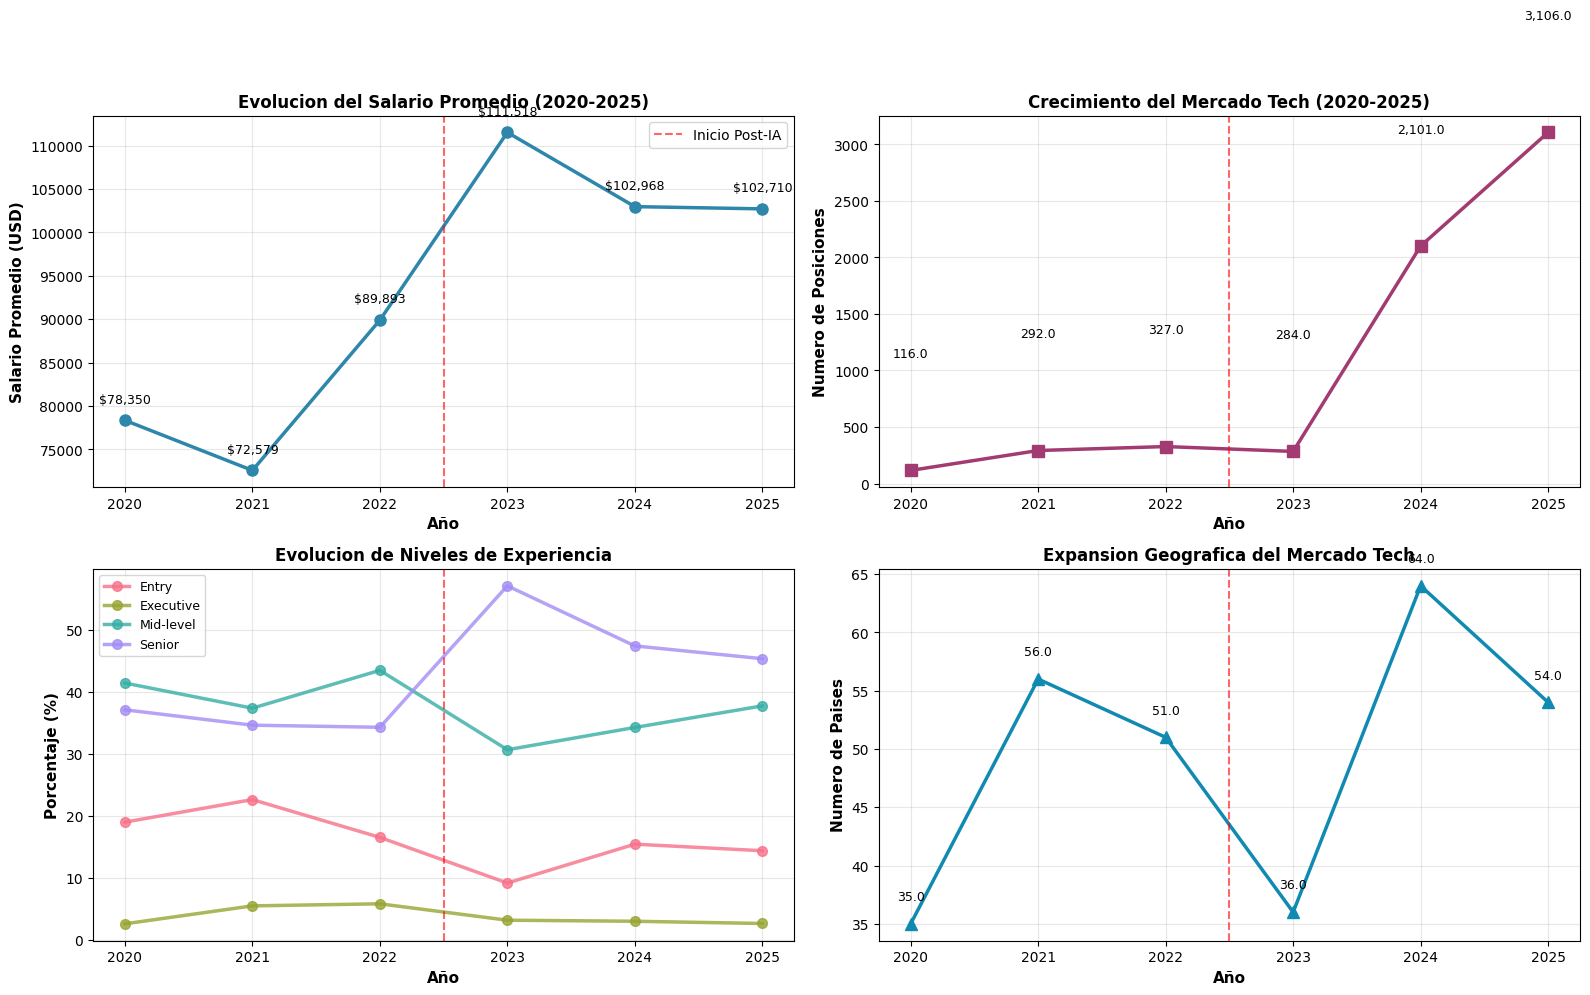

In [9]:
# Asegurar que 'yearly_metrics' exista: crear a partir de df si no está definido
if 'yearly_metrics' not in globals():
    yearly_metrics = (
        df.groupby('work_year')
          .agg(mean_salary=('salary_in_usd', 'mean'),
               median_salary=('salary_in_usd', 'median'),
               job_count=('salary_in_usd', 'count'),
               country_count=('employee_country_name', 'nunique'))
          .reset_index()
          .rename(columns={'work_year': 'year'})
          .sort_values('year')
          .reset_index(drop=True)
    )

# Asegurar que 'exp_level_year_pct' exista: crear a partir de df si no está definido
if 'exp_level_year_pct' not in globals():
    exp_level_year = df.groupby(['work_year', 'experience_level']).size().unstack(fill_value=0)
    exp_level_year_pct = exp_level_year.div(exp_level_year.sum(axis=1), axis=0) * 100
    exp_level_year_pct.index.name = 'work_year'
    # Si se prefiere índice como enteros de año
    try:
        exp_level_year_pct.index = exp_level_year_pct.index.astype(int)
    except Exception:
        pass

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 3.1 Salario promedio
axes[0, 0].plot(yearly_metrics['year'], yearly_metrics['mean_salary'], 
                marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6, label='Inicio Post-IA')
axes[0, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Salario Promedio (USD)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Evolucion del Salario Promedio (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 0].text(row['year'], row['mean_salary'] + 2000, f"${row['mean_salary']:,.0f}", 
                    ha='center', fontsize=9)

# 3.2 Numero de empleos tech
axes[0, 1].plot(yearly_metrics['year'], yearly_metrics['job_count'], 
                marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[0, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[0, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Numero de Posiciones', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Crecimiento del Mercado Tech (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 1].text(row['year'], row['job_count'] + 1000, f"{row['job_count']:,}", 
                    ha='center', fontsize=9)

# 3.3 Proporcion de niveles de experiencia (todos los disponibles)
exp_levels = exp_level_year_pct.columns.tolist()
colors = sns.color_palette("husl", len(exp_levels))
exp_level_map = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

for i, level in enumerate(exp_levels):
    label = exp_level_map.get(level, level)
    axes[1, 0].plot(exp_level_year_pct.index, exp_level_year_pct[level], 
                    marker='o', linewidth=2.5, markersize=7, 
                    color=colors[i], label=label, alpha=0.8)

axes[1, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Porcentaje (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Evolucion de Niveles de Experiencia', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 3.4 Numero de paises activos
axes[1, 1].plot(yearly_metrics['year'], yearly_metrics['country_count'], 
                marker='^', linewidth=2.5, markersize=8, color='#118AB2')
axes[1, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Numero de Paises', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Expansion Geografica del Mercado Tech', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[1, 1].text(row['year'], row['country_count'] + 2, f"{row['country_count']}", 
                    ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### TEST DE RANDOM WALK EN SERIES APILADAS

In [10]:
print("\n" + "="*70)
print("TEST DE RANDOM WALK - SERIES APILADAS POR PAIS")
print("="*70)

# Test en salarios apilados (niveles) - CUATRIMESTRAL
stacked_salaries = country_quarter_salary['mean_salary'].dropna()
adf_salary = adfuller(stacked_salaries, autolag='AIC')

print(f"\n4.1 TEST EN SALARIOS (series apiladas por cuatrimestre - {len(stacked_salaries)} obs):")
print(f"ADF Statistic: {adf_salary[0]:.4f}")
print(f"p-value: {adf_salary[1]:.4f}")
print(f"Lags usados: {adf_salary[2]}")
print(f"Numero de observaciones: {adf_salary[3]}")
print("\nValores criticos:")
for key, value in adf_salary[4].items():
    print(f"  {key}: {value:.4f}")

if adf_salary[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los salarios siguen un RANDOM WALK")
    print("Serie NO estacionaria - tendencia temporal presente")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk")
    print("Serie estacionaria")

# Test en retornos apilados
adf_returns = adfuller(stacked_returns, autolag='AIC')

print(f"\n4.2 TEST EN RETORNOS (series apiladas por cuatrimestre - {len(stacked_returns)} obs):")
print(f"ADF Statistic: {adf_returns[0]:.4f}")
print(f"p-value: {adf_returns[1]:.4f}")
print(f"Lags usados: {adf_returns[2]}")
print(f"Numero de observaciones: {adf_returns[3]}")
print("\nValores criticos:")
for key, value in adf_returns[4].items():
    print(f"  {key}: {value:.4f}")

if adf_returns[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los retornos siguen un random walk")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS")
    print("No hay autocorrelacion significativa - variaciones son aleatorias")



TEST DE RANDOM WALK - SERIES APILADAS POR PAIS

4.1 TEST EN SALARIOS (series apiladas por cuatrimestre - 118 obs):
ADF Statistic: -2.9814
p-value: 0.0367
Lags usados: 7
Numero de observaciones: 110

Valores criticos:
  1%: -3.4912
  5%: -2.8882
  10%: -2.5810

CONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk
Serie estacionaria

4.2 TEST EN RETORNOS (series apiladas por cuatrimestre - 111 obs):
ADF Statistic: -17.5960
p-value: 0.0000
Lags usados: 0
Numero de observaciones: 110

Valores criticos:
  1%: -3.4912
  5%: -2.8882
  10%: -2.5810

CONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS
No hay autocorrelacion significativa - variaciones son aleatorias


### ANALISIS DE AUTOCORRELACION (ACF) - SERIES APILADAS

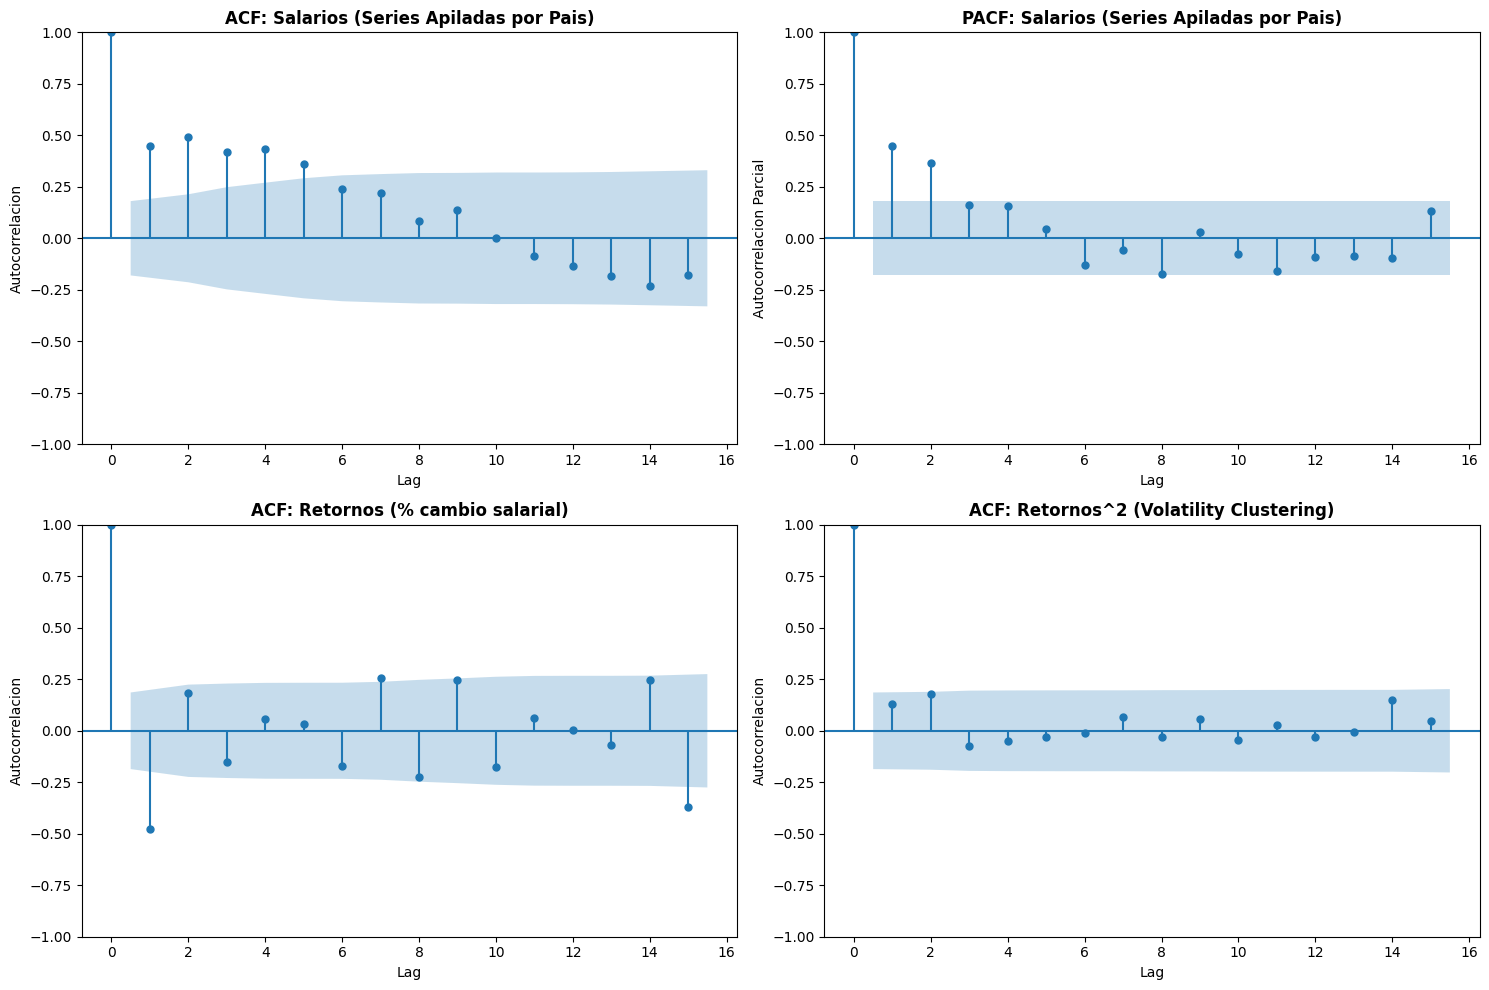


INTERPRETACION DE ACF - SERIES APILADAS

5.1 ACF DE SALARIOS (primeros 5 lags):
  Lag 1: 0.4484
  Lag 2: 0.4942
  Lag 3: 0.4172
  Lag 4: 0.4312
  Lag 5: 0.3600

5.2 ACF DE RETORNOS (primeros 5 lags):
  Lag 1: -0.4750
  Lag 2: 0.1846
  Lag 3: -0.1505
  Lag 4: 0.0562
  Lag 5: 0.0314

Bandas de confianza (95%): +/- 0.1860


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 5.1 ACF de Salarios apilados
plot_acf(stacked_salaries, lags=15, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lag', fontsize=10)
axes[0, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.2 PACF de Salarios apilados
plot_pacf(stacked_salaries, lags=15, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Lag', fontsize=10)
axes[0, 1].set_ylabel('Autocorrelacion Parcial', fontsize=10)

# 5.3 ACF de Retornos apilados
plot_acf(stacked_returns, lags=15, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF: Retornos (% cambio salarial)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag', fontsize=10)
axes[1, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.4 ACF de Retornos^2 (volatility clustering)
returns_squared = stacked_returns ** 2
plot_acf(returns_squared, lags=15, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF: Retornos^2 (Volatility Clustering)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelacion', fontsize=10)

plt.tight_layout()
plt.show()

# Calcular ACF manualmente
acf_salary = acf(stacked_salaries, nlags=10, fft=False)
acf_returns = acf(stacked_returns, nlags=10, fft=False)

print("\n" + "="*70)
print("INTERPRETACION DE ACF - SERIES APILADAS")
print("="*70)
print("\n5.1 ACF DE SALARIOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_salary[i]:.4f}")

print("\n5.2 ACF DE RETORNOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_returns[i]:.4f}")

n = len(stacked_returns)
conf_bound = 1.96 / np.sqrt(n)
print(f"\nBandas de confianza (95%): +/- {conf_bound:.4f}")

### STREAMGRAPH: EVOLUCION DE CATEGORIAS


Verificacion Streamgraph - Suma por cuatrimestre:
  Min: 100.00%
  Max: 100.00%
  Promedio: 100.00%
  OK: Todas las sumas son 100%


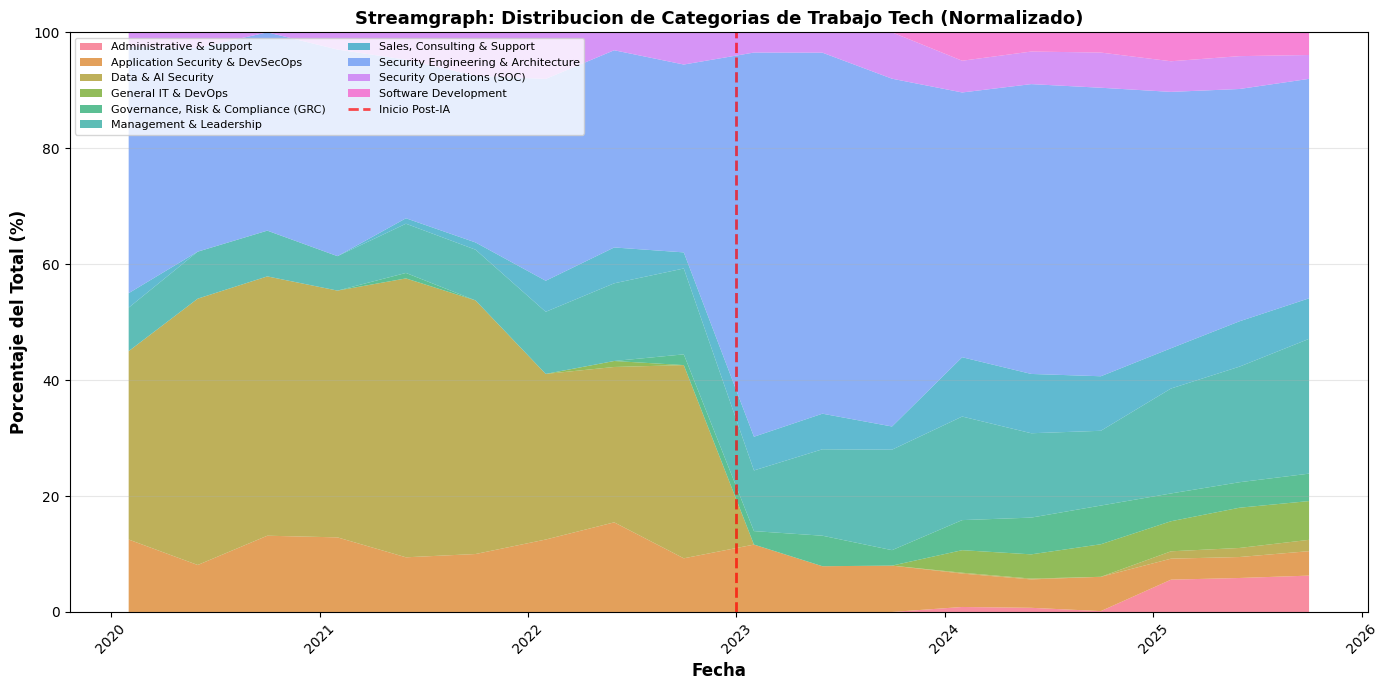

In [12]:
# CORRECCION 2: El area debe sumar al 100% en cada punto temporal

# Tomar top 10 categorias por volumen
top_categories = df.groupby('category').size().nlargest(10).index.tolist()
category_quarter_filtered = category_quarter[category_quarter['category'].isin(top_categories)]

# Pivot y convertir a porcentajes (suma 100% en cada cuatrimestre)
category_quarter_pivot = category_quarter_filtered.pivot(
    index='fecha_artificial', 
    columns='category', 
    values='count'
).fillna(0)

# Normalizar a porcentajes
category_quarter_pct = category_quarter_pivot.div(category_quarter_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

if len(category_quarter_pct.columns) > 0:
    colors_stream = sns.color_palette("husl", len(category_quarter_pct.columns))
    
    # Usar stackplot que garantiza que el area suma correctamente
    ax.stackplot(category_quarter_pct.index, 
                 *[category_quarter_pct[col] for col in category_quarter_pct.columns],
                 labels=category_quarter_pct.columns,
                 colors=colors_stream,
                 alpha=0.8,
                 baseline='zero')  # Asegura que inicie en 0
    
    ax.axvline(pd.Timestamp('2023-01-01'), color='red', linestyle='--', 
               linewidth=2, alpha=0.7, label='Inicio Post-IA')
    ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax.set_ylabel('Porcentaje del Total (%)', fontsize=12, fontweight='bold')
    ax.set_title('Streamgraph: Distribucion de Categorias de Trabajo Tech (Normalizado)', 
                 fontsize=13, fontweight='bold')
    
    # Verificar que suma 100%
    total_check = category_quarter_pct.sum(axis=1)
    print(f"\nVerificacion Streamgraph - Suma por cuatrimestre:")
    print(f"  Min: {total_check.min():.2f}%")
    print(f"  Max: {total_check.max():.2f}%")
    print(f"  Promedio: {total_check.mean():.2f}%")
    
    if not np.allclose(total_check, 100, atol=0.1):
        print("  ADVERTENCIA: Las sumas no son exactamente 100%")
    else:
        print("  OK: Todas las sumas son 100%")
    
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)  # Forzar rango 0-100%
    plt.xticks(rotation=45)
    
else:
    ax.text(0.5, 0.5, 'No hay suficientes categorias para visualizar', 
            ha='center', va='center', fontsize=12)
    ax.set_title('Streamgraph: Evolucion de Categorias (sin datos suficientes)', fontsize=13)

plt.tight_layout()
plt.show()

### COMPARACION PRE-IA vs POST-IA

In [13]:
print("\n" + "="*70)
print("COMPARACION ESTADISTICA: PRE-IA vs POST-IA")
print("="*70)

pre_ia = df[df['ai_period'] == 'Pre-IA (2020-2022)']['salary_in_usd']
post_ia = df[df['ai_period'] == 'Post-IA (2023-2025)']['salary_in_usd']

t_stat, p_value = stats.ttest_ind(post_ia, pre_ia)

print(f"\n7.1 SALARIOS:")
print(f"Pre-IA:  Media = ${pre_ia.mean():,.2f}, Mediana = ${pre_ia.median():,.2f}, n = {len(pre_ia)}")
print(f"Post-IA: Media = ${post_ia.mean():,.2f}, Mediana = ${post_ia.median():,.2f}, n = {len(post_ia)}")
print(f"\nCambio porcentual: {((post_ia.mean() - pre_ia.mean()) / pre_ia.mean() * 100):.2f}%")
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4e}")
if p_value < 0.001:
    print("Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")


COMPARACION ESTADISTICA: PRE-IA vs POST-IA

7.1 SALARIOS:
Pre-IA:  Media = $81,192.76, Mediana = $69,336.00, n = 735
Post-IA: Media = $103,263.97, Mediana = $93,500.00, n = 5491

Cambio porcentual: 27.18%

T-test: t = 10.3934, p-value = 4.2613e-25
Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)

7.2 NUMERO DE POSICIONES:
Pre-IA:  735 posiciones
Post-IA: 5,491 posiciones
Crecimiento: 647.07%


### SLOPEGRAPH: COMPARACION 2020 vs 2025 POR PAIS

In [14]:
!!pip install adjustText

['Requirement already satisfied: adjustText in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.3.0)',
 'Requirement already satisfied: numpy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (2.3.3)',
 'Requirement already satisfied: matplotlib in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (3.10.6)',
 'Requirement already satisfied: scipy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (1.16.2)',
 'Requirement already satisfied: contourpy>=1.0.1 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (0.12.1)',
 'Requirement already

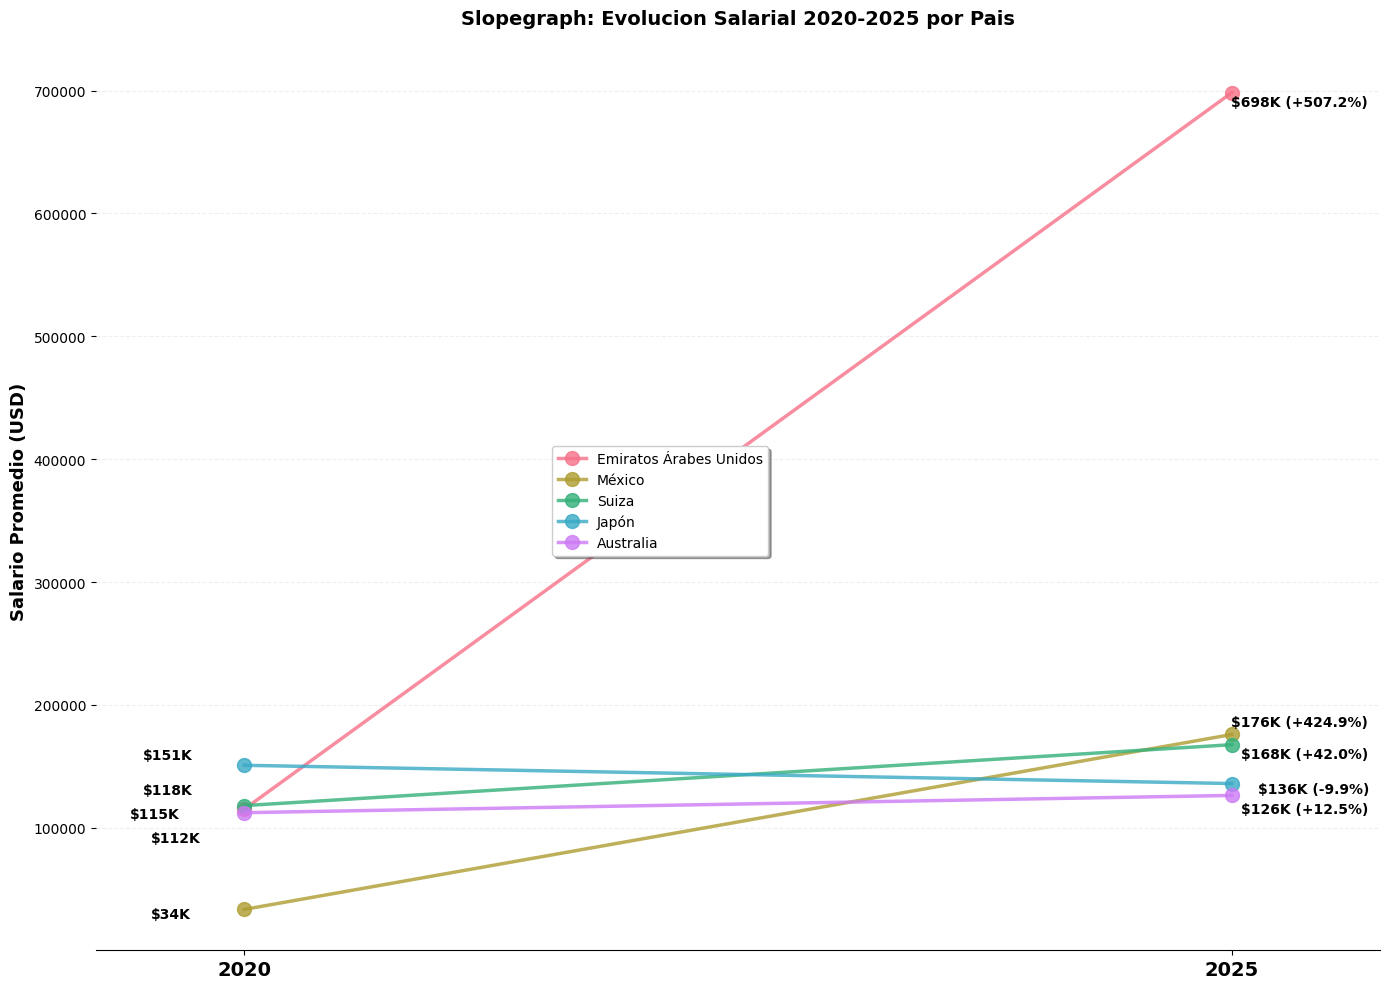


SLOPEGRAPH: TOP 5 PAISES
Emiratos Árabes Unidos: $115,000 -> $698,326 (+507.2%)
México: $33,511 -> $175,912 (+424.9%)
Suiza: $118,008 -> $167,613 (+42.0%)
Japón: $150,844 -> $135,981 (-9.9%)
Australia: $112,263 -> $126,305 (+12.5%)


In [15]:

from adjustText import adjust_text  # ### AÑADIDO 1: Importar la librería ###


# Obtener salarios por pais en 2020 y 2025
salary_2020 = df[df['work_year'] == 2020].groupby('employee_country_name')['salary_in_usd'].mean()
salary_2025 = df[df['work_year'] == 2025].groupby('employee_country_name')['salary_in_usd'].mean()

# Paises presentes en ambos años
common_countries = salary_2020.index.intersection(salary_2025.index)

if len(common_countries) >= 5:
    # Calcular crecimiento
    growth = ((salary_2025[common_countries] - salary_2020[common_countries]) / salary_2020[common_countries] * 100)
    
    # Top 5 paises por salario promedio en 2025
    top_countries = salary_2025[common_countries].nlargest(5).index
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Colores diferentes para cada linea
    colors = sns.color_palette("husl", len(top_countries))
    
    # ### AÑADIDO 2: Listas para guardar las etiquetas de texto ###
    texts_2020 = []
    texts_2025 = []
    
    for idx, country in enumerate(top_countries):
        y_2020 = salary_2020[country]
        y_2025 = salary_2025[country]
        change_pct = growth[country]
        
        # Linea con color unico
        ax.plot([0, 1], [y_2020, y_2025], 
                marker='o', markersize=10, linewidth=2.5, 
                alpha=0.8, color=colors[idx], label=country)
        
        # ### AÑADIDO 3: Guardar la etiqueta en la lista ###
        # Etiqueta 2020 (izquierda)
        texts_2020.append(
            ax.text(-0.05, y_2020, f"${y_2020/1000:.0f}K", 
                    ha='right', va='center', fontsize=10, fontweight='bold')
        )
        
        # ### AÑADIDO 4: Guardar la etiqueta en la lista ###
        # Etiqueta 2025 (derecha) con cambio porcentual
        texts_2025.append(
            ax.text(1.05, y_2025, f"${y_2025/1000:.0f}K ({change_pct:+.1f}%)", 
                    ha='left', va='center', fontsize=10, fontweight='bold')
        )
    
    ax.set_xlim(-0.15, 1.15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['2020', '2025'], fontsize=14, fontweight='bold')
    ax.set_ylabel('Salario Promedio (USD)', fontsize=13, fontweight='bold')
    ax.set_title('Slopegraph: Evolucion Salarial 2020-2025 por Pais', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Leyenda (se mantiene como en tu original)
    ax.legend(loc='center left', bbox_to_anchor=(0.35, 0.5), 
              fontsize=10, frameon=True, shadow=True)
    
    # ### AÑADIDO 5: Llamar a la función para ajustar el texto ###
    adjust_text(texts_2020)
    adjust_text(texts_2025)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("SLOPEGRAPH: TOP 5 PAISES") # Ajustado de 8 a 5 para que coincida con el código
    print("="*70)
    for country in top_countries:
        change = growth[country]
        print(f"{country}: ${salary_2020[country]:,.0f} -> ${salary_2025[country]:,.0f} ({change:+.1f}%)")
else:
    print("\nNOTA: No hay suficientes paises con datos en 2020 y 2025 para Slopegraph")

### HEATMAP: SALARIO PROMEDIO POR AÑO Y EXPERIENCE LEVEL

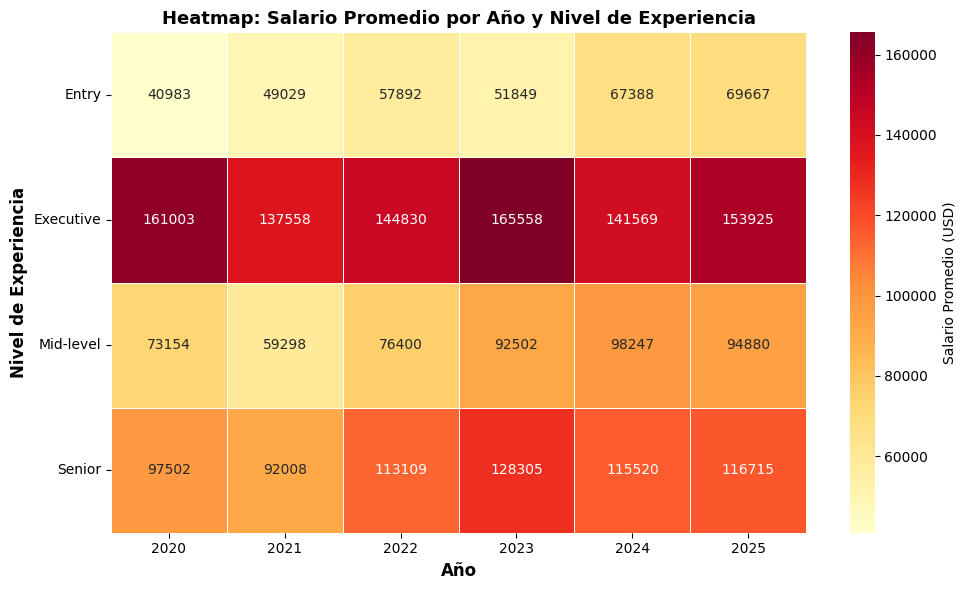


HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO
experience_level            EN             EX            MI             SE
work_year                                                                 
2020              40982.681818  161003.333333  73154.166667   97502.069767
2021              49029.136364  137557.625000  59297.596330   92007.871287
2022              57891.537037  144830.421053  76400.492958  113108.848214
2023              51848.961538  165557.888889  92502.494253  128305.098765
2024              67388.240741  141568.698413  98246.726008  115520.446231
2025              69666.773543  153924.780488  94880.066610  116715.424307


In [16]:
salary_year_exp = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(salary_year_exp.T, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Salario Promedio (USD)'}, ax=ax, linewidths=0.5)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Nivel de Experiencia', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Salario Promedio por Año y Nivel de Experiencia', 
             fontsize=13, fontweight='bold')

exp_level_labels = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
current_labels = ax.get_yticklabels()
new_labels = [exp_level_labels.get(label.get_text(), label.get_text()) for label in current_labels]
ax.set_yticklabels(new_labels, rotation=0)

plt.tight_layout()
plt.savefig('05_heatmap_salario_experiencia.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO")
print("="*70)
print(salary_year_exp)

### WATERFALL CHART: CAMBIO EN POSICIONES POR EXPERIENCE LEVEL

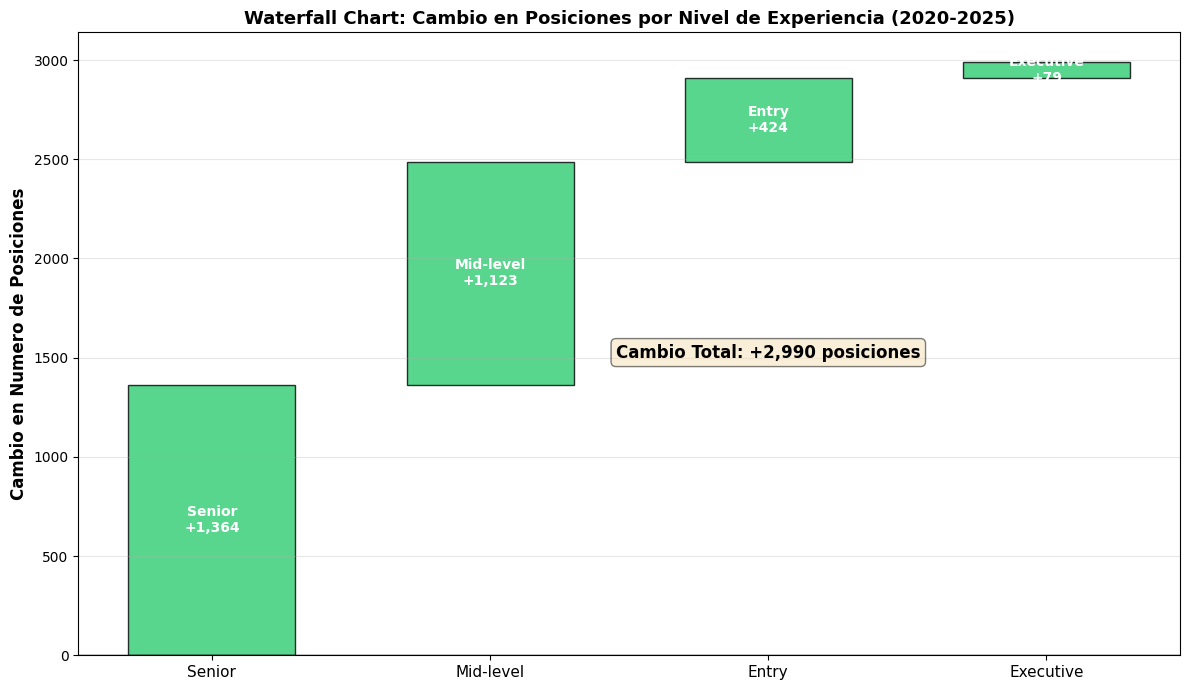


WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)
Senior: +1,364 posiciones
Mid-level: +1,123 posiciones
Entry: +424 posiciones
Executive: +79 posiciones

Cambio Total: +2,990 posiciones


In [17]:
exp_2020 = df[df['work_year'] == 2020]['experience_level'].value_counts()
exp_2025 = df[df['work_year'] == 2025]['experience_level'].value_counts()

all_levels = sorted(set(exp_2020.index) | set(exp_2025.index))
changes = {}
for level in all_levels:
    val_2020 = exp_2020.get(level, 0)
    val_2025 = exp_2025.get(level, 0)
    changes[level] = val_2025 - val_2020

changes_sorted = dict(sorted(changes.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 7))

cumulative = 0
x_pos = 0
colors_waterfall = []
positions = []
values_for_plot = []

for level, change in changes_sorted.items():
    if change > 0:
        colors_waterfall.append('#2ecc71')
    else:
        colors_waterfall.append('#e74c3c')
    
    ax.bar(x_pos, change, bottom=cumulative, width=0.6, 
           color=colors_waterfall[-1], alpha=0.8, edgecolor='black')
    
    label_name = exp_level_labels.get(level, level)
    ax.text(x_pos, cumulative + change/2, f"{label_name}\n{change:+,}", 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    positions.append(label_name)
    cumulative += change
    x_pos += 1

ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontsize=11)
ax.set_ylabel('Cambio en Numero de Posiciones', fontsize=12, fontweight='bold')
ax.set_title('Waterfall Chart: Cambio en Posiciones por Nivel de Experiencia (2020-2025)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

total_change = sum(changes.values())
ax.text(len(positions)/2, max(changes.values())*1.1, 
        f"Cambio Total: {total_change:+,} posiciones", 
        ha='center', fontsize=12, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)")
print("="*70)
for level, change in changes_sorted.items():
    label_name = exp_level_labels.get(level, level)
    print(f"{label_name}: {change:+,} posiciones")
print(f"\nCambio Total: {total_change:+,} posiciones")


### CROSS-CORRELATION FUNCTION (CCF) ENTRE PAISES

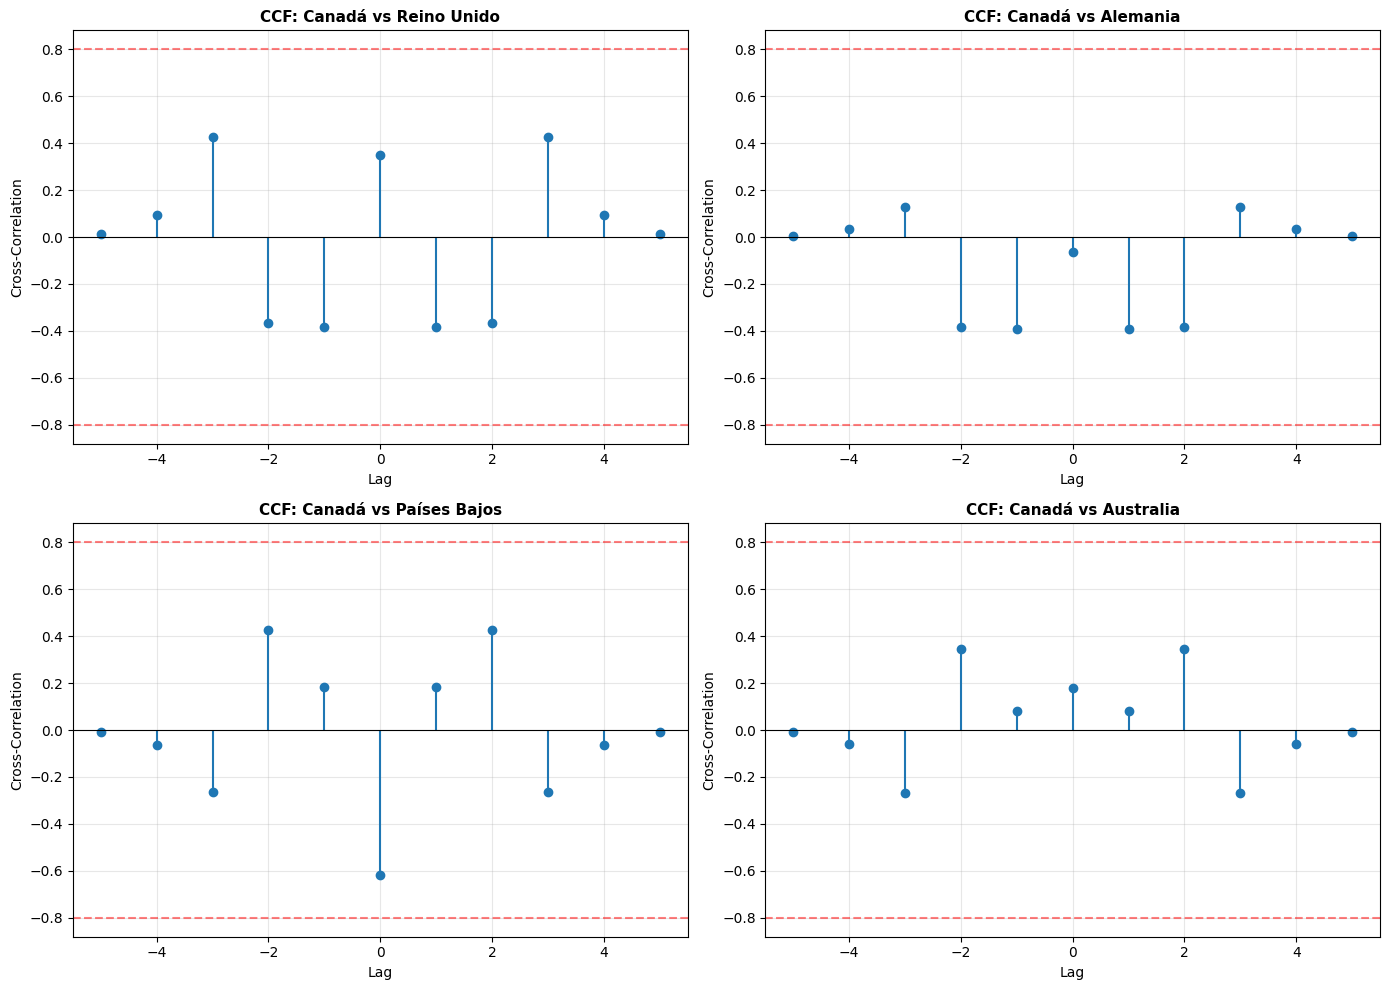


CROSS-CORRELATION FUNCTION: Canadá vs OTROS PAISES
Interpretacion:
- Lag negativo: Pais de referencia predice al otro pais
- Lag positivo: Otro pais predice al pais de referencia
- Lag 0: Correlacion contemporanea

7.2 NUMERO DE POSICIONES:
Pre-IA:  735 posiciones
Post-IA: 5,491 posiciones
Crecimiento: 647.07%


In [18]:
from statsmodels.tsa.stattools import ccf

# Construir country_year_salary si no existe: media salarial por pais y año
if 'country_year_salary' not in globals():
    country_year_salary = (
        df.groupby(['employee_country_name', 'work_year'])
          .agg(mean_salary=('salary_in_usd', 'mean'),
               count=('salary_in_usd', 'count'))
          .reset_index()
          .rename(columns={'employee_country_name': 'country', 'work_year': 'year'})
    )

# Seleccionar top 5 paises por volumen
top_5_countries = df['employee_country_name'].value_counts().head(5).index.tolist()

# Crear series temporales para cada pais
country_series = {}
for country in top_5_countries:
    country_data = country_year_salary[country_year_salary['country'] == country].sort_values('year')
    if len(country_data) >= 4:
        country_series[country] = country_data.set_index('year')['mean_salary']

if len(country_series) >= 2:
    reference_country = top_5_countries[0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    plot_idx = 0
    for i, country in enumerate(top_5_countries[1:5]):
        if country in country_series and reference_country in country_series:
            series1 = country_series[reference_country]
            series2 = country_series[country]
            
            common_years = series1.index.intersection(series2.index)
            if len(common_years) >= 4:
                s1 = series1[common_years].values
                s2 = series2[common_years].values
                
                ccf_values = ccf(s1, s2, adjusted=False)
                # ccf returns correlations for non-negative lags; create symmetric lags for plotting
                max_lag = len(ccf_values) - 1
                lags = np.arange(-max_lag, max_lag + 1)
                # build symmetric ccf array (lag negative -> ccf at positive lag of reversed order)
                ccf_sym = np.concatenate((ccf_values[:0:-1], ccf_values))
                
                mid = len(ccf_sym) // 2
                half = mid  # number of lags to show on each side
                axes[plot_idx].stem(lags[mid - half: mid + half + 1], ccf_sym[mid - half: mid + half + 1], 
                                   basefmt=' ', linefmt='C0-', markerfmt='C0o')
                
                conf_bound = 1.96 / np.sqrt(len(common_years))
                axes[plot_idx].axhline(conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(-conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(0, color='black', linewidth=0.8)
                
                axes[plot_idx].set_xlabel('Lag', fontsize=10)
                axes[plot_idx].set_ylabel('Cross-Correlation', fontsize=10)
                axes[plot_idx].set_title(f'CCF: {reference_country} vs {country}', 
                                        fontsize=11, fontweight='bold')
                axes[plot_idx].grid(True, alpha=0.3)
                
                plot_idx += 1
    
    for idx in range(plot_idx, 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print(f"CROSS-CORRELATION FUNCTION: {reference_country} vs OTROS PAISES")
    print("="*70)
    print("Interpretacion:")
    print("- Lag negativo: Pais de referencia predice al otro pais")
    print("- Lag positivo: Otro pais predice al pais de referencia")
    print("- Lag 0: Correlacion contemporanea")
else:
    print("\nNOTA: No hay suficientes paises con datos para CCF")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")


### ANALISIS ESPACIAL - MAPAS GEOGRAFICOS

In [19]:
!!pip install geopandas folium

['Requirement already satisfied: geopandas in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.1.1)',
 'Requirement already satisfied: folium in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Requirement already satisfied: numpy>=1.24 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.3)',
 'Requirement already satisfied: pyogrio>=0.7.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (0.11.1)',
 'Requirement already satisfied: packaging in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (25.0)',
 'Requirement already satisfied: pandas>=2.0.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.2)',
 'Requirement already satisfied: pyproj>=3.5.0 in c:\\users\\yuse

In [20]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
df['ai_period'] = df['work_year'].apply(lambda y: 'Pre-IA' if y <= 2022 else 'Post-IA')

print(f"\n📊 Dataset cargado: {df.shape[0]:,} registros")
print(f"   Columnas: {df.shape[1]}")
print(f"   Países únicos: {df['employee_country_name'].nunique()}")
print(f"   Departamentos: {df['department'].nunique()}")


📊 Dataset cargado: 65,117 registros
   Columnas: 23
   Países únicos: 95
   Departamentos: 11


### BALANCEO AUTOMÁTICO INTELIGENTE

In [22]:
print("\n" + "="*80)
print("BALANCEO AUTOMÁTICO POR SIMILITUD DE EMPLEOS")
print("="*80)

# Análisis de distribución por país
country_counts = df['employee_country_name'].value_counts()
dominant = country_counts.index[0]

# Estadísticas de distribución
q25, q50, q75, q90, q95 = country_counts.quantile([0.25, 0.5, 0.75, 0.90, 0.95])

print(f"\n📊 Distribución original:")
print(f"   • País dominante: {dominant} ({country_counts[dominant]:,} empleos)")
print(f"   • Percentil 95: {q95:.0f}")
print(f"   • Percentil 75: {q75:.0f}")
print(f"   • Mediana (P50): {q50:.0f}")
print(f"   • Percentil 25: {q25:.0f}")

# ESTRATEGIA: Submuestrear país dominante a 3x el P95 de otros países
# Esto mantiene su importancia pero permite comparación justa
otros_paises_p95 = country_counts[country_counts.index != dominant].quantile(0.95)
target_dominant = int(otros_paises_p95 * 3)

print(f"\n🎯 Estrategia de balanceo:")
print(f"   • P95 de otros países: {otros_paises_p95:.0f}")
print(f"   • Target para {dominant}: {target_dominant:,} (3x P95)")

# Aplicar balanceo
np.random.seed(42)
df_dominant = df[df['employee_country_name'] == dominant].sample(n=min(target_dominant, len(df[df['employee_country_name'] == dominant])), random_state=42)
df_others = df[df['employee_country_name'] != dominant]
df_balanced = pd.concat([df_dominant, df_others], ignore_index=True)

print(f"\n✅ Resultado del balanceo:")
print(f"   • {dominant}: {len(df_dominant):,} empleos")
print(f"   • Otros países: {len(df_others):,} empleos")
print(f"   • Total balanceado: {len(df_balanced):,} empleos")
print(f"   • Reducción: {(1 - len(df_balanced)/len(df))*100:.1f}%")


BALANCEO AUTOMÁTICO POR SIMILITUD DE EMPLEOS

📊 Distribución original:
   • País dominante: Estados Unidos (58,909 empleos)
   • Percentil 95: 300
   • Percentil 75: 24
   • Mediana (P50): 6
   • Percentil 25: 2

🎯 Estrategia de balanceo:
   • P95 de otros países: 214
   • Target para Estados Unidos: 642 (3x P95)

✅ Resultado del balanceo:
   • Estados Unidos: 642 empleos
   • Otros países: 6,208 empleos
   • Total balanceado: 6,850 empleos
   • Reducción: 89.5%


### CÓDIGOS ISO AUTOMÁTICOS (CON FUZZY MATCHING)

In [23]:
print("\n" + "="*80)
print("GENERANDO CÓDIGOS ISO AUTOMÁTICAMENTE")
print("="*80)

try:
    import pycountry
    from difflib import get_close_matches
    
    def get_iso3_code(country_name):
        """
        Convierte nombre de país a código ISO3 automáticamente.
        Usa fuzzy matching para nombres en español/inglés.
        """
        if pd.isna(country_name):
            return None
        
        # Diccionario de casos especiales (nombres en español y variaciones)
        special_cases = {
            # Nombres en español comunes
            'Estados Unidos': 'USA',
            'Reino Unido': 'GBR',
            'Países Bajos': 'NLD',
            'Corea del Sur': 'KOR',
            'República Checa': 'CZE',
            'Arabia Saudita': 'SAU',
            'España': 'ESP',
            'Bélgica': 'BEL',
            'Emiratos Árabes Unidos': 'ARE',
            'Irán': 'IRN',
            'Turquía': 'TUR',
            'Túnez': 'TUN',
            'Bolivia': 'BOL',
            'Taiwán': 'TWN',
            'Macedonia (ARYM)': 'MKD',
            # Variaciones adicionales comunes
            'Alemania': 'DEU',
            'Suiza': 'CHE',
            'Japón': 'JPN',
            'Grecia': 'GRC',
            'Dinamarca': 'DNK',
            'Suecia': 'SWE',
            'Noruega': 'NOR',
            'Finlandia': 'FIN',
            'Polonia': 'POL',
            'Austria': 'AUT',
            'Hungría': 'HUN',
            'Rumania': 'ROU',
            'Croacia': 'HRV'
        }
        
        # Revisar casos especiales primero
        if country_name in special_cases:
            return special_cases[country_name]
        
        # Intentar búsqueda directa por nombre
        try:
            country = pycountry.countries.get(name=country_name)
            if country:
                return country.alpha_3
        except:
            pass
        
        # Intentar búsqueda por nombre oficial
        try:
            country = pycountry.countries.get(official_name=country_name)
            if country:
                return country.alpha_3
        except:
            pass
        
        # Fuzzy matching: buscar país más cercano
        all_country_names = [c.name for c in pycountry.countries]
        matches = get_close_matches(country_name, all_country_names, n=1, cutoff=0.6)
        
        if matches:
            country = pycountry.countries.get(name=matches[0])
            return country.alpha_3
        
        return None
    
    # Generar mapeo automático para todos los países en el dataset
    unique_countries = df_balanced['employee_country_name'].unique()
    iso_map = {}
    
    print(f"\nGenerando códigos ISO3 para {len(unique_countries)} países...")
    not_found = []
    
    for country in unique_countries:
        iso_code = get_iso3_code(country)
        if iso_code:
            iso_map[country] = iso_code
        else:
            not_found.append(country)
    
    print(f"✓ Países mapeados exitosamente: {len(iso_map)}")
    if not_found:
        print(f"⚠️ Países sin código ISO (se excluirán de mapas): {not_found}")
    
except ImportError:
    print("⚠️ pycountry no disponible. Usando mapeo manual...")
    # Fallback: diccionario manual reducido (solo países comunes)
    iso_map = {
        'Estados Unidos': 'USA', 'Canadá': 'CAN', 'Reino Unido': 'GBR', 
        'Alemania': 'DEU', 'España': 'ESP', 'Francia': 'FRA', 'India': 'IND',
        'Países Bajos': 'NLD', 'Australia': 'AUS', 'Brasil': 'BRA', 
        'Portugal': 'PRT', 'Italia': 'ITA', 'Polonia': 'POL', 'Austria': 'AUT',
        'Suiza': 'CHE', 'México': 'MEX', 'Grecia': 'GRC', 'Suecia': 'SWE',
        'Noruega': 'NOR', 'Dinamarca': 'DNK', 'Finlandia': 'FIN', 'Irlanda': 'IRL',
        'Bélgica': 'BEL', 'Israel': 'ISR', 'Singapur': 'SGP', 'Japón': 'JPN',
        'Corea del Sur': 'KOR', 'China': 'CHN', 'Argentina': 'ARG'
    }



GENERANDO CÓDIGOS ISO AUTOMÁTICAMENTE

Generando códigos ISO3 para 95 países...
✓ Países mapeados exitosamente: 95


### CHOROPLETH MAP: DENSIDAD DE EMPLEOS

In [24]:
print("\n" + "="*80)
print("3.1.1 CHOROPLETH MAP: Densidad de Empleos por País")
print("="*80)

# Agregar por país
country_density = df_balanced.groupby('employee_country_name').agg({
    'salary_in_usd': ['count', 'mean', 'median'],
    'work_year': 'nunique',
    'department': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).reset_index()

country_density.columns = ['country', 'job_count', 'mean_salary', 'median_salary', 'years', 'top_dept']
country_density['iso'] = country_density['country'].map(iso_map)

# Filtrar países sin ISO (para mapas)
country_density_mapped = country_density[country_density['iso'].notna()].copy()

print(f"\n🔍 Verificación de datos para Choropleth 1:")
print(f"   • Total países: {len(country_density)}")
print(f"   • Países con ISO: {len(country_density_mapped)}")
print(f"   • Rango de empleos: {country_density_mapped['job_count'].min()} - {country_density_mapped['job_count'].max()}")
print(f"\n📊 Muestra de datos:")
print(country_density_mapped[['country', 'iso', 'job_count', 'mean_salary']].head(10))

# Verificar que hay datos
if len(country_density_mapped) == 0:
    print("❌ ERROR: No hay países con códigos ISO para mapear")
else:
    fig_choropleth1 = px.choropleth(
        country_density_mapped,
        locations='iso',
        locationmode='ISO-3',  # IMPORTANTE: especificar modo ISO-3
        color='job_count',
        hover_name='country',
        hover_data={
            'iso': False,
            'job_count': ':,',
            'mean_salary': ':$,.0f',
            'median_salary': ':$,.0f',
            'top_dept': True
        },
        color_continuous_scale='YlOrRd',
        title='<b>Choropleth Map: Densidad de Empleos Data Science por País</b>',
        labels={'job_count': 'Número de Empleos'}
    )
    
    fig_choropleth1.update_geos(
        projection_type="natural earth",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue",
        showcountries=True,
        countrycolor="white"
    )
    
    fig_choropleth1.update_layout(
        height=700,
        width=1200,
        font=dict(size=12),
        title_x=0.5,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    
    print(f"✓ Choropleth 1 generado con {len(country_density_mapped)} países")
    
    # MOSTRAR EL MAPA
    fig_choropleth1.show()
    print("   → Mapa abierto en navegador")

print(f"\n📊 Top 10 países por densidad:")
print(country_density_mapped.nlargest(10, 'job_count')[['country', 'job_count', 'mean_salary']])



3.1.1 CHOROPLETH MAP: Densidad de Empleos por País

🔍 Verificación de datos para Choropleth 1:
   • Total países: 95
   • Países con ISO: 95
   • Rango de empleos: 1 - 2132

📊 Muestra de datos:
          country  iso  job_count    mean_salary
0      Afganistán  AFG          3   76666.666667
1         Albania  ALB          2   50000.000000
2        Alemania  DEU        479  103321.281837
3  Arabia Saudita  SAU          1  100000.000000
4         Argelia  ARG          1  100000.000000
5       Argentina  ARG          8   57000.000000
6         Armenia  ARM          2   50000.000000
7       Australia  AUS        298  126744.600671
8         Austria  AUT        169   62113.899408
9      Azerbaiyán  AZE          2   50000.000000
✓ Choropleth 1 generado con 95 países


   → Mapa abierto en navegador

📊 Top 10 países por densidad:
           country  job_count    mean_salary
15          Canadá       2132  127999.055347
75     Reino Unido       1353   85852.600148
30  Estados Unidos        642  148649.962617
2         Alemania        479  103321.281837
71    Países Bajos        303   77677.207921
7        Australia        298  126744.600671
8          Austria        169   62113.899408
27      Eslovaquia        147   36984.795918
34         Francia        121   73073.859504
29          España         96   72378.125000


### CHOROPLETH MAP: CRECIMIENTO SALARIAL PRE vs POST-IA

In [25]:
print("\n" + "="*80)
print("3.1.2 CHOROPLETH MAP: Crecimiento Salarial Pre-IA vs Post-IA")
print("="*80)

# Calcular salarios por período
salary_by_period = df_balanced.groupby(['employee_country_name', 'ai_period']).agg({
    'salary_in_usd': ['mean', 'count']
}).reset_index()
salary_by_period.columns = ['country', 'period', 'mean_salary', 'count']

# Pivotar para comparar
salary_pivot = salary_by_period.pivot(
    index='country',
    columns='period',
    values='mean_salary'
).reset_index()

# Solo países con datos en AMBOS períodos
salary_pivot = salary_pivot.dropna(subset=['Pre-IA', 'Post-IA'])

# Calcular crecimiento
salary_pivot['growth_pct'] = ((salary_pivot['Post-IA'] - salary_pivot['Pre-IA']) / salary_pivot['Pre-IA'] * 100)
salary_pivot['growth_abs'] = salary_pivot['Post-IA'] - salary_pivot['Pre-IA']
salary_pivot['iso'] = salary_pivot['country'].map(iso_map)

# Filtrar países mapeables
salary_pivot_mapped = salary_pivot[salary_pivot['iso'].notna()].copy()

print(f"\n🔍 Verificación de datos para Choropleth 2:")
print(f"   • Países con ambos períodos: {len(salary_pivot)}")
print(f"   • Países con ISO: {len(salary_pivot_mapped)}")
print(f"   • Rango de crecimiento: {salary_pivot_mapped['growth_pct'].min():.1f}% - {salary_pivot_mapped['growth_pct'].max():.1f}%")
print(f"\n📊 Muestra de datos:")
print(salary_pivot_mapped[['country', 'iso', 'Pre-IA', 'Post-IA', 'growth_pct']].head(10))

if len(salary_pivot_mapped) == 0:
    print("❌ ERROR: No hay países con datos en ambos períodos")
else:
    fig_choropleth2 = px.choropleth(
        salary_pivot_mapped,
        locations='iso',
        locationmode='ISO-3',  # IMPORTANTE: especificar modo ISO-3
        color='growth_pct',
        hover_name='country',
        hover_data={
            'iso': False,
            'Pre-IA': ':$,.0f',
            'Post-IA': ':$,.0f',
            'growth_pct': ':.1f',
            'growth_abs': ':+$,.0f'
        },
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
        title='<b>Choropleth Map: Crecimiento Salarial Pre-IA (≤2022) vs Post-IA (≥2023)</b>',
        labels={'growth_pct': 'Crecimiento (%)'}
    )
    
    fig_choropleth2.update_geos(
        projection_type="natural earth",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue",
        showcountries=True,
        countrycolor="white"
    )
    
    fig_choropleth2.update_layout(
        height=700,
        width=1200,
        font=dict(size=12),
        title_x=0.5,
        margin=dict(l=0, r=0, t=50, b=0)
    )
    
    print(f"✓ Choropleth 2 generado con {len(salary_pivot_mapped)} países")
    
    # MOSTRAR EL MAPA
    fig_choropleth2.show()
    print("   → Mapa abierto en navegador")

print(f"\n📈 Top 10 países por crecimiento:")
print(salary_pivot_mapped.nlargest(10, 'growth_pct')[['country', 'Pre-IA', 'Post-IA', 'growth_pct']])


3.1.2 CHOROPLETH MAP: Crecimiento Salarial Pre-IA vs Post-IA

🔍 Verificación de datos para Choropleth 2:
   • Países con ambos períodos: 58
   • Países con ISO: 58
   • Rango de crecimiento: -90.6% - 658.9%

📊 Muestra de datos:
period    country  iso         Pre-IA        Post-IA  growth_pct
2        Alemania  DEU   85670.313433  106191.706311   23.953914
5       Argentina  ARG   53000.000000   61000.000000   15.094340
7       Australia  AUS  127391.961538  126682.720588   -0.556739
8         Austria  AUT   71339.200000   61832.640244  -13.325857
12         Brasil  BRA   62499.411765   64242.500000    2.788967
13       Bulgaria  BGR  103773.500000  110334.666667    6.322584
14        Bélgica  BEL   70740.400000  127410.368421   80.109765
15         Canadá  CAN  115812.158879  128643.004938   11.079015
16          Chile  CHL   45019.000000   96500.000000  114.353939
18         Chipre  CHL   42026.000000   70833.000000   68.545662
✓ Choropleth 2 generado con 58 países


   → Mapa abierto en navegador

📈 Top 10 países por crecimiento:
period                 country         Pre-IA        Post-IA  growth_pct
65                      México   19862.666667  150744.928571  658.936003
88                     Turquía   23822.500000  152212.200000  538.943016
39                    Honduras   20000.000000  115000.000000  475.000000
21                  Costa Rica   20100.000000   89285.714286  344.207534
62                       Malta   28369.000000  101068.500000  256.263880
19                    Colombia   21844.000000   71000.000000  225.032045
26      Emiratos Árabes Unidos  118142.857143  369163.000000  212.471705
78                     Rumania   45878.000000  125666.500000  173.914512
58                  Luxemburgo   54374.000000  128860.500000  136.989186
33                   Finlandia   36773.000000   80078.272727  117.763774


### PROPORTIONAL SYMBOL MAP: Salario Promedio

In [26]:
print("\n" + "="*80)
print("3.1.4 PROPORTIONAL SYMBOL MAP: Salario Promedio por Ubicación")
print("="*80)

# Usar coordenadas reales del dataset
country_coords = df_balanced.groupby('employee_country_name').agg({
    'employee_latitude': 'first',
    'employee_longitude': 'first',
    'salary_in_usd': ['mean', 'count']
}).reset_index()

country_coords.columns = ['country', 'lat', 'lon', 'mean_salary', 'job_count']
country_coords = country_coords[country_coords['lat'].notna() & country_coords['lon'].notna()]

fig_symbols = px.scatter_geo(
    country_coords,
    lat='lat',
    lon='lon',
    size='mean_salary',
    color='mean_salary',
    hover_name='country',
    hover_data={
        'lat': False,
        'lon': False,
        'mean_salary': ':$,.0f',
        'job_count': ':,'
    },
    color_continuous_scale='Viridis',
    size_max=50,
    title='<b>Proportional Symbol Map: Salario Promedio (Tamaño = Salario)</b>',
    labels={'mean_salary': 'Salario Promedio'}
)

fig_symbols.update_geos(projection_type="natural earth")
fig_symbols.update_layout(height=600, font=dict(size=12), title_x=0.5)

print(f"✓ Países con coordenadas: {len(country_coords)}")

# MOSTRAR MAPA
fig_symbols.show()
print("   → Proportional Symbol Map abierto en navegador")


3.1.4 PROPORTIONAL SYMBOL MAP: Salario Promedio por Ubicación
✓ Países con coordenadas: 95


   → Proportional Symbol Map abierto en navegador


### POINT DISTRIBUTION MAP: Clustering por Departamento

In [27]:
print("\n" + "="*80)
print("3.1.5 POINT DISTRIBUTION MAP: Distribución con Clustering")
print("="*80)

# Muestra aleatoria para visualización (10% o máx 5000 puntos)
sample_size = min(5000, int(len(df_balanced) * 0.1))
df_sample = df_balanced.sample(n=sample_size, random_state=42)

# Filtrar puntos con coordenadas válidas
df_sample_mapped = df_sample[
    df_sample['employee_latitude'].notna() & 
    df_sample['employee_longitude'].notna()
].copy()

fig_points = px.scatter_geo(
    df_sample_mapped,
    lat='employee_latitude',
    lon='employee_longitude',
    color='department',
    hover_name='employee_country_name',
    hover_data={
        'employee_latitude': False,
        'employee_longitude': False,
        'salary_in_usd': ':$,.0f',
        'experience_level': True,
        'job_title': True
    },
    title=f'<b>Point Distribution Map: Distribución Geográfica de Empleos ({len(df_sample_mapped):,} puntos)</b>',
    opacity=0.6
)

fig_points.update_geos(projection_type="natural earth")
fig_points.update_layout(height=600, font=dict(size=11), title_x=0.5)

print(f"✓ Puntos mapeados: {len(df_sample_mapped):,}")
print(f"   Departamentos: {df_sample_mapped['department'].nunique()}")

# MOSTRAR MAPA
fig_points.show()
print("   → Point Distribution Map abierto en navegador")



3.1.5 POINT DISTRIBUTION MAP: Distribución con Clustering
✓ Puntos mapeados: 685
   Departamentos: 9


   → Point Distribution Map abierto en navegador


### CARTOGRAM: Impacto Económico (Treemap)

In [28]:
print("\n" + "="*80)
print("3.1.6 CARTOGRAM: Países por Impacto Económico Total")
print("="*80)

# Calcular impacto económico
country_density['economic_impact'] = country_density['job_count'] * country_density['mean_salary']
country_density['impact_billions'] = country_density['economic_impact'] / 1e9

# Para el cartogram, necesitamos países con coordenadas
cartogram_data = country_density.merge(
    country_coords[['country', 'lat', 'lon']], 
    on='country', 
    how='inner'
)

# Normalizar tamaños para visualización (raíz cuadrada para mejor proporción)
cartogram_data['bubble_size'] = np.sqrt(cartogram_data['economic_impact']) / 1000

print(f"✓ Países para cartogram: {len(cartogram_data)}")
print(f"\n📊 Top 10 países por impacto económico:")
print(cartogram_data.nlargest(10, 'economic_impact')[['country', 'job_count', 'mean_salary', 'impact_billions']])

# CARTOGRAM usando burbujas proporcionales en posición geográfica
fig_cartogram = go.Figure()

# Agregar mapa base
fig_cartogram.add_trace(go.Scattergeo(
    lon=cartogram_data['lon'],
    lat=cartogram_data['lat'],
    mode='markers+text',
    marker=dict(
        size=cartogram_data['bubble_size'],
        color=cartogram_data['mean_salary'],
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(
            title="Salario<br>Promedio<br>(USD)",
            x=1.02
        ),
        line=dict(width=1, color='white'),
        sizemode='diameter'
    ),
    text=cartogram_data['country'],
    textfont=dict(size=8, color='white', family='Arial Black'),
    textposition='middle center',
    hovertemplate='<b>%{text}</b><br>' +
                  'Empleos: %{customdata[0]:,}<br>' +
                  'Salario Promedio: $%{customdata[1]:,.0f}<br>' +
                  'Impacto Económico: $%{customdata[2]:.2f}B<br>' +
                  '<extra></extra>',
    customdata=cartogram_data[['job_count', 'mean_salary', 'impact_billions']].values,
    showlegend=False
))

fig_cartogram.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor='rgb(230, 230, 230)',
    coastlinecolor='rgb(180, 180, 180)',
    showocean=True,
    oceancolor='rgb(200, 220, 240)',
    showcountries=True,
    countrycolor='rgb(200, 200, 200)',
    showlakes=True,
    lakecolor='rgb(200, 220, 240)'
)

fig_cartogram.update_layout(
    title='<b>Cartogram: Países Redimensionados por Impacto Económico (Tamaño = Empleos × Salario)</b>',
    height=700,
    width=1200,
    font=dict(size=12),
    title_x=0.5,
    margin=dict(l=0, r=0, t=50, b=0)
)





3.1.6 CARTOGRAM: Países por Impacto Económico Total
✓ Países para cartogram: 95

📊 Top 10 países por impacto económico:
           country  job_count    mean_salary  impact_billions
15          Canadá       2132  127999.055347         0.272894
75     Reino Unido       1353   85852.600148         0.116159
30  Estados Unidos        642  148649.962617         0.095433
2         Alemania        479  103321.281837         0.049491
7        Australia        298  126744.600671         0.037770
71    Países Bajos        303   77677.207921         0.023536
8          Austria        169   62113.899408         0.010497
34         Francia        121   73073.859504         0.008842
45         Irlanda         77  101731.844156         0.007833
48          Italia         82   94481.902439         0.007748


# INTEGRACION ESPACIOTEMPORAL

In [29]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'], errors='coerce')
df['ai_period'] = df['work_year'].apply(lambda y: 'Pre-IA' if y <= 2022 else 'Post-IA')

# Crear fechas artificiales con cuatrimestres
np.random.seed(42)
df['cuatrimestre'] = np.random.choice([1, 2, 3], size=len(df))
cuatrimestre_mes = {1: 2, 2: 6, 3: 10}
df['mes_artificial'] = df['cuatrimestre'].map(cuatrimestre_mes)
df['fecha_artificial'] = pd.to_datetime(
    df['work_year'].astype(str) + '-' + df['mes_artificial'].astype(str) + '-01'
)

print(f"\n📊 Dataset: {df.shape[0]:,} registros")
print(f"   Rango temporal: {df['fecha_artificial'].min()} - {df['fecha_artificial'].max()}")
print(f"   Países: {df['employee_country_name'].nunique()}")


📊 Dataset: 65,117 registros
   Rango temporal: 2020-02-01 00:00:00 - 2025-10-01 00:00:00
   Países: 95


In [30]:

print("\n" + "="*80)
print("PREPARACIÓN DE DATOS ESPACIOTEMPORALES")
print("="*80)

# Filtrar países con coordenadas y datos en ambos períodos
country_both_periods = df.groupby(['employee_country_name', 'ai_period']).size().unstack(fill_value=0)
countries_valid = country_both_periods[(country_both_periods['Pre-IA'] > 0) & 
                                       (country_both_periods['Post-IA'] > 0)].index.tolist()

df_valid = df[df['employee_country_name'].isin(countries_valid)].copy()

# Agregar coordenadas
df_valid = df_valid[df_valid['employee_latitude'].notna() & 
                    df_valid['employee_longitude'].notna()]

print(f"\n✓ Países con datos Pre y Post-IA: {len(countries_valid)}")
print(f"✓ Registros válidos: {len(df_valid):,}")


PREPARACIÓN DE DATOS ESPACIOTEMPORALES

✓ Países con datos Pre y Post-IA: 58
✓ Registros válidos: 64,803


### EARLY ADOPTERS - Difusión Geográfica del Impacto IA

In [31]:
print("\n" + "="*80)
print("3.3.1 EARLY ADOPTERS: Difusión Geográfica del Impacto IA")
print("="*80)

# Calcular impacto IA por país
impact_by_country = df_valid.groupby(['employee_country_name', 'ai_period']).agg({
    'salary_in_usd': 'mean',
    'work_year': 'count',
    'employee_latitude': 'first',
    'employee_longitude': 'first'
}).reset_index()

impact_by_country.columns = ['country', 'period', 'mean_salary', 'job_count', 'lat', 'lon']

# Pivotar para calcular cambios
impact_pivot = impact_by_country.pivot(index='country', columns='period', values='mean_salary')
impact_pivot['salary_growth'] = ((impact_pivot['Post-IA'] - impact_pivot['Pre-IA']) / 
                                  impact_pivot['Pre-IA'] * 100)

# Agregar coordenadas y conteos
coords_data = impact_by_country.groupby('country')[['lat', 'lon']].first()
job_counts_post = impact_by_country[impact_by_country['period'] == 'Post-IA'][['country', 'job_count']]

impact_pivot = impact_pivot.merge(coords_data, left_index=True, right_index=True)
impact_pivot = impact_pivot.merge(job_counts_post, left_index=True, right_on='country')
impact_pivot = impact_pivot.set_index('country')

# Calcular "velocidad de adopción": % crecimiento + volumen post-IA
impact_pivot['adoption_speed'] = (impact_pivot['salary_growth'] * 0.5 + 
                                   impact_pivot['job_count'] / impact_pivot['job_count'].max() * 100 * 0.5)

# Clasificar países por velocidad de adopción
impact_pivot['adoption_category'] = pd.qcut(
    impact_pivot['adoption_speed'], 
    q=4, 
    labels=['Late Adopter', 'Moderate Adopter', 'Fast Adopter', 'Early Adopter']
)

print(f"\n📊 Clasificación de países por adopción IA:")
print(impact_pivot['adoption_category'].value_counts().sort_index())

print(f"\n🏆 Early Adopters (Top 10):")
early_adopters = impact_pivot.nlargest(10, 'adoption_speed')
print(early_adopters[['Pre-IA', 'Post-IA', 'salary_growth', 'job_count', 'adoption_speed', 'adoption_category']])

# VISUALIZACIÓN 1: Mapa de Early Adopters
fig_early = px.scatter_geo(
    impact_pivot.reset_index(),
    lat='lat',
    lon='lon',
    size='job_count',
    color='adoption_category',
    hover_name='country',
    hover_data={
        'lat': False,
        'lon': False,
        'Pre-IA': ':$,.0f',
        'Post-IA': ':$,.0f',
        'salary_growth': ':.1f%',
        'job_count': ':,',
        'adoption_speed': ':.1f'
    },
    color_discrete_map={
        'Early Adopter': '#00ff00',
        'Fast Adopter': '#90EE90',
        'Moderate Adopter': '#FFD700',
        'Late Adopter': '#FF6347'
    },
    size_max=50,
    title='<b>Mapa de Early Adopters: Difusión Geográfica del Impacto IA</b><br>' +
          '<sub>Tamaño = Empleos Post-IA | Color = Velocidad de Adopción</sub>'
)

fig_early.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    showcountries=True,
    countrycolor="white"
)

fig_early.update_layout(height=700, width=1200, font=dict(size=12))
fig_early.show()

print("\n✓ Mapa de Early Adopters generado")

# VISUALIZACIÓN 2: Timeline de adopción
timeline_data = df_valid.groupby(['fecha_artificial', 'employee_country_name']).agg({
    'salary_in_usd': 'mean'
}).reset_index()

# Asegurar que fecha_artificial es datetime
timeline_data['fecha_artificial'] = pd.to_datetime(timeline_data['fecha_artificial'])

# Filtrar top 10 early adopters para timeline
top10_countries = early_adopters.head(10).index.tolist() if not early_adopters.empty else []
timeline_top10 = timeline_data[timeline_data['employee_country_name'].isin(top10_countries)].copy()

if not timeline_top10.empty:
    fig_timeline = px.line(
        timeline_top10,
        x='fecha_artificial',
        y='salary_in_usd',
        color='employee_country_name',
        title='<b>Timeline de Adopción IA: Evolución Salarial de Early Adopters</b>',
        labels={
            'fecha_artificial': 'Fecha',
            'salary_in_usd': 'Salario Promedio (USD)',
            'employee_country_name': 'País'
        }
    )

    # Agregar línea vertical en 2023 (inicio era Post-IA)
    # Convertir a timestamp numérico para evitar el error
    vline_date = pd.Timestamp('2023-01-01')
    
    # Usar add_shape en lugar de add_vline para mayor control
    fig_timeline.add_shape(
        type="line",
        x0=vline_date,
        x1=vline_date,
        y0=0,
        y1=1,
        yref="paper",
        line=dict(color="red", width=2, dash="dash")
    )
    
    # Agregar anotación manual
    fig_timeline.add_annotation(
        x=vline_date,
        y=1,
        yref="paper",
        text="Inicio Post-IA",
        showarrow=False,
        yanchor="bottom",
        font=dict(color="red", size=12)
    )

    fig_timeline.update_layout(height=600, width=1200, hovermode='x unified')
    fig_timeline.show()
    
    print("\n✓ Timeline de Early Adopters generado")
else:
    print("\n⚠️ No hay datos suficientes para generar el timeline de Early Adopters.")


3.3.1 EARLY ADOPTERS: Difusión Geográfica del Impacto IA

📊 Clasificación de países por adopción IA:
adoption_category
Late Adopter        15
Moderate Adopter    14
Fast Adopter        14
Early Adopter       15
Name: count, dtype: int64

🏆 Early Adopters (Top 10):
                               Pre-IA        Post-IA  salary_growth  \
country                                                               
México                   19862.666667  150744.928571     658.936003   
Turquía                  23822.500000  152212.200000     538.943016   
Honduras                 20000.000000  115000.000000     475.000000   
Costa Rica               20100.000000   89285.714286     344.207534   
Malta                    28369.000000  101068.500000     256.263880   
Colombia                 21844.000000   71000.000000     225.032045   
Emiratos Árabes Unidos  118142.857143  369163.000000     212.471705   
Rumania                  45878.000000  125666.500000     173.914512   
Luxemburgo              


✓ Mapa de Early Adopters generado



✓ Timeline de Early Adopters generado


### PROXIMIDAD GEOGRÁFICA vs SIMILITUD SALARIAL

In [39]:
print("\n" + "="*80)
print("3.3.3 PROXIMIDAD GEOGRÁFICA vs SIMILITUD EN EVOLUCIÓN SALARIAL")
print("="*80)

# Preparar datos por país
country_summary = df_valid.groupby('employee_country_name').agg({
    'employee_latitude': 'first',
    'employee_longitude': 'first',
    'salary_in_usd': 'mean'
}).reset_index()

country_summary.columns = ['country', 'lat', 'lon', 'mean_salary']

# Calcular matriz de distancias geográficas (haversine)
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """Calcular distancia en km entre dos puntos"""
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    km = 6371 * c
    return km

# Crear matriz de distancias
n_countries = len(country_summary)
geo_distance_matrix = np.zeros((n_countries, n_countries))

for i in range(n_countries):
    for j in range(n_countries):
        if i != j:
            geo_distance_matrix[i, j] = haversine(
                country_summary.iloc[i]['lon'], country_summary.iloc[i]['lat'],
                country_summary.iloc[j]['lon'], country_summary.iloc[j]['lat']
            )

geo_distance_df = pd.DataFrame(
    geo_distance_matrix,
    index=country_summary['country'],
    columns=country_summary['country']
)

# Calcular similitud en evolución salarial
# Usar series temporales de países comunes
common_countries = list(set(country_summary['country']) & set(valid_countries_ts))
print(f"\n✓ Países con datos geográficos y temporales: {len(common_countries)}")

# Matriz de similitud salarial (correlación de series temporales)
salary_similarity_matrix = pivot_returns_valid[common_countries].corr()

# Extraer distancias geográficas para países comunes
geo_distance_common = geo_distance_df.loc[common_countries, common_countries]

# Crear pares para análisis
pairs_data = []
for i, country1 in enumerate(common_countries):
    for j, country2 in enumerate(common_countries):
        if i < j:  # Evitar duplicados
            pairs_data.append({
                'country1': country1,
                'country2': country2,
                'geo_distance': geo_distance_common.loc[country1, country2],
                'salary_similarity': salary_similarity_matrix.loc[country1, country2]
            })

pairs_df = pd.DataFrame(pairs_data)
pairs_df = pairs_df[pairs_df['geo_distance'] > 0]  # Filtrar país consigo mismo

# Calcular correlación: ¿Menor distancia → Mayor similitud?
corr_geo_salary = stats.pearsonr(pairs_df['geo_distance'], pairs_df['salary_similarity'])

print(f"\n📊 Correlación: Distancia Geográfica vs Similitud Salarial")
print(f"   Pearson r = {corr_geo_salary[0]:.3f}")
print(f"   p-value = {corr_geo_salary[1]:.4f}")
print(f"   Interpretación: {'✅ La proximidad geográfica SÍ predice similitud salarial' if corr_geo_salary[1] < 0.05 and corr_geo_salary[0] < 0 else '❌ No hay relación significativa'}")

# VISUALIZACIÓN: Scatter proximidad vs similitud
fig_proximity = px.scatter(
    pairs_df,
    x='geo_distance',
    y='salary_similarity',
    hover_data=['country1', 'country2'],
    labels={
        'geo_distance': 'Distancia Geográfica (km)',
        'salary_similarity': 'Similitud en Evolución Salarial (Correlación)'
    },
    title=f'<b>Proximidad Geográfica vs Similitud Salarial</b><br>' +
          f'<sub>Pearson r={corr_geo_salary[0]:.3f}, p={corr_geo_salary[1]:.4f}</sub>',
    trendline='ols',
    trendline_color_override='red'
)

fig_proximity.update_layout(height=600, width=1000)
fig_proximity.show()

print("\n✓ Scatter de proximidad geográfica generado")

# VISUALIZACIÓN ADICIONAL: Network de países similares
print("\n📊 Identificando clusters geográfico-salariales...")

# Encontrar pares con alta similitud salarial (>0.6)
similar_pairs = pairs_df[pairs_df['salary_similarity'] > 0.6].copy()

print(f"\n✓ Pares de países con alta similitud salarial (>0.6): {len(similar_pairs)}")
print(similar_pairs.nlargest(10, 'salary_similarity')[['country1', 'country2', 'geo_distance', 'salary_similarity']])

# Network graph de similitud
import networkx as nx

G = nx.Graph()
for _, row in similar_pairs.iterrows():
    G.add_edge(row['country1'], row['country2'], weight=row['salary_similarity'])

# Obtener posiciones de países
pos = {country: (row['lon'], row['lat']) 
       for country, row in country_summary[country_summary['country'].isin(common_countries)].set_index('country').iterrows()}

# VISUALIZACIÓN MEJORADA: Network con líneas coloreadas y grosor variable
fig_network = go.Figure()

# Agregar líneas con grosor proporcional a la similitud
edge_colors = []
edge_widths = []
edge_texts = []

for edge in G.edges(data=True):
    if edge[0] in pos and edge[1] in pos:
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        weight = edge[2]['weight']
        
        # Color según intensidad de correlación
        if weight > 0.8:
            color = 'rgba(0, 255, 0, 0.7)'  # Verde fuerte
            width = 3
        elif weight > 0.7:
            color = 'rgba(144, 238, 144, 0.6)'  # Verde claro
            width = 2
        else:
            color = 'rgba(255, 215, 0, 0.5)'  # Amarillo
            width = 1
        
        fig_network.add_trace(go.Scattergeo(
            lon=[x0, x1],
            lat=[y0, y1],
            mode='lines',
            line=dict(width=width, color=color),
            hoverinfo='text',
            hovertext=f'{edge[0]} ↔ {edge[1]}<br>Correlación: {weight:.3f}',
            showlegend=False
        ))

# Agregar nodos (países) con tamaño proporcional al número de conexiones
node_degrees = dict(G.degree())
node_sizes = [node_degrees.get(node, 1) * 5 for node in G.nodes() if node in pos]

node_trace = go.Scattergeo(
    lon=[pos[node][0] for node in G.nodes() if node in pos],
    lat=[pos[node][1] for node in G.nodes() if node in pos],
    text=[f"{node}<br>Conexiones: {node_degrees.get(node, 0)}" for node in G.nodes() if node in pos],
    mode='markers+text',
    marker=dict(
        size=node_sizes,
        color='red',
        line=dict(width=2, color='white'),
        sizemode='diameter'
    ),
    textposition='top center',
    textfont=dict(size=9, color='black', family='Arial Black'),
    hoverinfo='text',
    showlegend=False
)

fig_network.add_trace(node_trace)

fig_network.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    showcountries=True,
    countrycolor="rgb(200, 200, 200)",
    showocean=True,
    oceancolor="lightblue",
    showlakes=True,
    lakecolor="lightblue"
)

# Agregar leyenda manual
fig_network.add_annotation(
    x=0.02, y=0.98,
    xref='paper', yref='paper',
    text='<b>Grosor de línea:</b><br>' +
         '━━━ Correlación > 0.8<br>' +
         '━━ Correlación 0.7-0.8<br>' +
         '━ Correlación 0.6-0.7',
    showarrow=False,
    bgcolor='white',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=10),
    align='left',
    xanchor='left',
    yanchor='top'
)

fig_network.update_layout(
    title='<b>Red de Similitud Salarial: Países con Evolución Correlacionada (r >0.6)</b><br>' +
          '<sub>Grosor de línea = Fuerza de correlación | Tamaño de nodo = Número de conexiones</sub>',
    height=700,
    width=1200,
    showlegend=False,
    margin=dict(l=0, r=0, t=80, b=0)
)

fig_network.show()

print("\n✓ Network de similitud salarial generado")

# VISUALIZACIÓN ADICIONAL: Heatmap de correlación (más informativo)
print("\n📊 Generando heatmap de correlación mejorado...")

# Usar top 15 países por número de conexiones
top_connected = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:15]
top_connected_countries = [c[0] for c in top_connected]

# Filtrar matriz de similitud
similarity_matrix_filtered = salary_similarity_matrix.loc[
    top_connected_countries, 
    top_connected_countries
]

fig_heatmap_corr = go.Figure(data=go.Heatmap(
    z=similarity_matrix_filtered.values,
    x=similarity_matrix_filtered.columns,
    y=similarity_matrix_filtered.index,
    colorscale='RdYlGn',
    zmid=0,
    zmin=-1,
    zmax=1,
    text=similarity_matrix_filtered.values.round(2),
    texttemplate='%{text}',
    textfont={"size": 9},
    colorbar=dict(title="Correlación<br>Temporal")
))

fig_heatmap_corr.update_layout(
    title='<b>Heatmap: Correlación Temporal entre Países (Top 15 más conectados)</b><br>' +
          '<sub>Verde = Evolución similar | Rojo = Evolución opuesta</sub>',
    xaxis_title='País',
    yaxis_title='País',
    height=800,
    width=900,
    xaxis={'side': 'bottom', 'tickangle': 45},
    yaxis={'side': 'left'}
)

fig_heatmap_corr.show()

print("\n✓ Heatmap de correlación generado")

# Análisis de clusters
print("\n📊 Identificando clusters regionales...")

# Países con más de 3 conexiones = hubs
hubs = [country for country, degree in node_degrees.items() if degree > 3]
print(f"\n🏆 Países HUB (>3 conexiones): {hubs}")

# Bloques regionales detectados
print(f"\n🌍 Bloques regionales detectados:")
components = list(nx.connected_components(G))
for i, component in enumerate(components, 1):
    if len(component) > 2:
        print(f"   Cluster {i} ({len(component)} países): {', '.join(sorted(component))}")


3.3.3 PROXIMIDAD GEOGRÁFICA vs SIMILITUD EN EVOLUCIÓN SALARIAL

✓ Países con datos geográficos y temporales: 22

📊 Correlación: Distancia Geográfica vs Similitud Salarial
   Pearson r = 0.054
   p-value = 0.4172
   Interpretación: ❌ No hay relación significativa



✓ Scatter de proximidad geográfica generado

📊 Identificando clusters geográfico-salariales...

✓ Pares de países con alta similitud salarial (>0.6): 73
           country1     country2  geo_distance  salary_similarity
174    Países Bajos     Alemania    371.812180           0.999996
226          Italia     Alemania   1045.902080           0.999806
103   Nueva Zelanda        Suiza  18761.747573           0.999775
172    Países Bajos       Italia   1265.830860           0.999749
180         Polonia        India   6165.674387           0.999507
178         Polonia        Suiza    971.343603           0.998772
44   Estados Unidos    Australia  15184.483973           0.998306
148          Canadá  Reino Unido   5807.429032           0.997892
100   Nueva Zelanda      Polonia  17804.376407           0.997496
112       Australia       Canadá  14151.620462           0.996763



✓ Network de similitud salarial generado

📊 Generando heatmap de correlación mejorado...



✓ Heatmap de correlación generado

📊 Identificando clusters regionales...

🏆 Países HUB (>3 conexiones): ['Brasil', 'Portugal', 'Grecia', 'Estados Unidos', 'Japón', 'Australia', 'Canadá', 'Irlanda', 'Austria', 'Reino Unido', 'Nueva Zelanda', 'Países Bajos', 'Polonia', 'Suiza', 'España', 'India', 'Italia', 'Alemania', 'México']

🌍 Bloques regionales detectados:
   Cluster 1 (22 países): Alemania, Australia, Austria, Brasil, Bélgica, Canadá, España, Estados Unidos, Francia, Grecia, India, Irlanda, Italia, Japón, México, Nueva Zelanda, Países Bajos, Polonia, Portugal, Reino Unido, Singapur, Suiza


# Getting the data from CSV

Loading the base dataset

Loading the base dataset

In [ ]:
base_df = pd.read_csv('./data/projectU2.csv').drop(columns=['created_at', 'updated_at'])
base_df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,0,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,100,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,50,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,100,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,0,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,2025,MI,FT,Security Engineer,80000,USD,80000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65113,2025,MI,FT,Security Engineer,120000,USD,120000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65114,2025,MI,CT,Security Engineer,120000,USD,120000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65115,2025,MI,CT,Security Engineer,130000,USD,130000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos


In [ ]:
columns = list(base_df.columns)
print(columns)

['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'category', 'subcategory', 'department', 'employee_latitude', 'employee_longitude', 'employee_country_name', 'company_latitude', 'company_longitude', 'company_country_name']


In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65117 entries, 0 to 65116
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   work_year              65117 non-null  int64  
 1   experience_level       65117 non-null  object 
 2   employment_type        65117 non-null  object 
 3   job_title              65117 non-null  object 
 4   salary                 65117 non-null  int64  
 5   salary_currency        65117 non-null  object 
 6   salary_in_usd          65117 non-null  int64  
 7   employee_residence     65117 non-null  object 
 8   remote_ratio           65117 non-null  int64  
 9   company_location       65117 non-null  object 
 10  company_size           65117 non-null  object 
 11  category               65117 non-null  object 
 12  subcategory            65117 non-null  object 
 13  department             65117 non-null  object 
 14  employee_latitude      65117 non-null  float64
 15  em

In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65117 entries, 0 to 65116
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   work_year              65117 non-null  int64  
 1   experience_level       65117 non-null  object 
 2   employment_type        65117 non-null  object 
 3   job_title              65117 non-null  object 
 4   salary                 65117 non-null  int64  
 5   salary_currency        65117 non-null  object 
 6   salary_in_usd          65117 non-null  int64  
 7   employee_residence     65117 non-null  object 
 8   remote_ratio           65117 non-null  int64  
 9   company_location       65117 non-null  object 
 10  company_size           65117 non-null  object 
 11  category               65117 non-null  object 
 12  subcategory            65117 non-null  object 
 13  department             65117 non-null  object 
 14  employee_latitude      65117 non-null  float64
 15  em

In [ ]:
base_df.isnull().sum()

work_year                0
experience_level         0
employment_type          0
job_title                0
salary                   0
salary_currency          0
salary_in_usd            0
employee_residence       0
remote_ratio             0
company_location         0
company_size             0
category                 0
subcategory              0
department               0
employee_latitude        0
employee_longitude       0
employee_country_name    0
company_latitude         0
company_longitude        0
company_country_name     0
dtype: int64

In [ ]:
base_df = base_df.replace(to_replace={'remote_ratio': {0: 'Remote', 50: 'Hybrid', 100: 'On-site'}})
base_df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,Remote,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,On-site,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,Hybrid,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,On-site,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,Remote,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,2025,MI,FT,Security Engineer,80000,USD,80000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65113,2025,MI,FT,Security Engineer,120000,USD,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65114,2025,MI,CT,Security Engineer,120000,USD,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65115,2025,MI,CT,Security Engineer,130000,USD,130000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos


# Hierarchical analysis

In [ ]:
base_df['department'].unique()

array(['Cybersecurity', 'Executive & Leadership',
       'Engineering & Development', 'Operations', 'Data & Analytics',
       'Sales & Consulting', 'Information Technology (IT)',
       'Finance & Accounting', 'Legal & Compliance',
       'Human Resources (HR)', 'Product Management'], dtype=object)

In [ ]:
jobs_df = base_df.drop(columns=['work_year', 'employee_latitude', 'employee_longitude', 'company_latitude', 'company_longitude', 'salary', 'salary_currency'])
jobs_df

,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_country_name,company_country_name
0,SE,FT,Security Engineer,107000,US,Remote,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
1,MI,FT,Security Engineer,135000,US,On-site,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
2,SE,FT,Security Engineer,148000,US,Hybrid,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
3,SE,FT,Staff Application Security Engineer,180000,US,On-site,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,Estados Unidos,Estados Unidos
4,EX,FT,Information Security Manager,117810,US,Remote,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,Estados Unidos,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,MI,FT,Security Engineer,80000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65113,MI,FT,Security Engineer,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65114,MI,CT,Security Engineer,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65115,MI,CT,Security Engineer,130000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos


In [ ]:
departments_list = list(jobs_df['department'].unique())
print(departments_list)

['Cybersecurity', 'Executive & Leadership', 'Engineering & Development', 'Operations', 'Data & Analytics', 'Sales & Consulting', 'Information Technology (IT)', 'Finance & Accounting', 'Legal & Compliance', 'Human Resources (HR)', 'Product Management']


In [ ]:
employees_number = []
incomes_per_sub = []
subcategories = []
categories = []
departments = []

for department in departments_list:
    department_df = jobs_df[jobs_df['department'] == department]
    categories_list = department_df['category'].unique()
    for category in categories_list:
        category_df = department_df[department_df['category'] == category]
        subcategories_list = category_df['subcategory'].unique()
        for subcategory in subcategories_list:
            subcategory_df = category_df[category_df['subcategory'] == subcategory]
            income = subcategory_df['salary_in_usd'].sum()
            employees_number.append(subcategory_df['subcategory'].count())
            incomes_per_sub.append(income)
            subcategories.append(subcategory)
            categories.append(category)
            departments.append(department)
    
jobs_df2 = pd.DataFrame({
    'department': departments,
    'category': categories,
    'subcategory': subcategories,
    'employees': employees_number,
    'income': incomes_per_sub
})

jobs_df2


,department,category,subcategory,employees,income
0,Cybersecurity,Security Engineering & Architecture,Security Engineering,16110,2589672695
1,Cybersecurity,Security Engineering & Architecture,General Security Analysis & Administration,8962,1059617253
2,Cybersecurity,Security Engineering & Architecture,Cloud & Network Security,100,15891297
3,Cybersecurity,Security Engineering & Architecture,Identity & Access Management (IAM),307,42049676
4,Cybersecurity,Application Security & DevSecOps,Application Security,44,4104204
...,...,...,...,...,...
78,Finance & Accounting,"Governance, Risk & Compliance (GRC)",Audit & Assurance,249,26696295
79,Finance & Accounting,Threat Intelligence & Forensics,Malware Analysis & Forensics,4,477388
80,Legal & Compliance,"Governance, Risk & Compliance (GRC)",Risk & Compliance,128,18656326
81,Human Resources (HR),Training & Education,Technical Training & Education,8,828299


In [ ]:
treemap_chart = px.treemap(
    data_frame= jobs_df2,
    values='income',
    path=['department', 'category', 'subcategory'],
    title='Income per department in USD (2020 - 2025)',
    color='income',  # Color by subcategory income to show the incomes per department
    color_continuous_scale="peach"
)

treemap_chart.update_traces(textinfo="label+value", textfont_size=11)
treemap_chart.update_layout(height=700, width=1000)
treemap_chart.show()

In [ ]:
sunburst_chart = px.sunburst(
    data_frame=jobs_df2,
    title='Departments presence in IT',
    height=800,
    path=['department', 'category', 'subcategory'],
    values='employees',
    color='employees',
    color_continuous_scale=px.colors.sequential.Viridis
)

# Customize layout for better display
sunburst_chart.update_layout(
    font=dict(size=12),
    title_x=0.5, # Center the title
)

# Showing the organizational structure
sunburst_chart.show()

In [ ]:
"""
def country_potential(department: str = None):
"""

employees_per_country = []
countries = []
countries_investment = []

for country in list(base_df['company_country_name'].unique()):
    countries_df = base_df[base_df['company_country_name'] == country]
    investment = countries_df['salary_in_usd'].sum()
    employees = len(countries_df)
    employees_per_country.append(employees)
    countries.append(country)
    countries_investment.append(investment)

dendrogram_df = pd.DataFrame({'Country': countries, 'Country_investment': countries_investment, 'No_employees': employees_per_country})
dendrogram_df= dendrogram_df.sort_values(by='Country_investment', ascending=False).head(15).drop(index=[0])

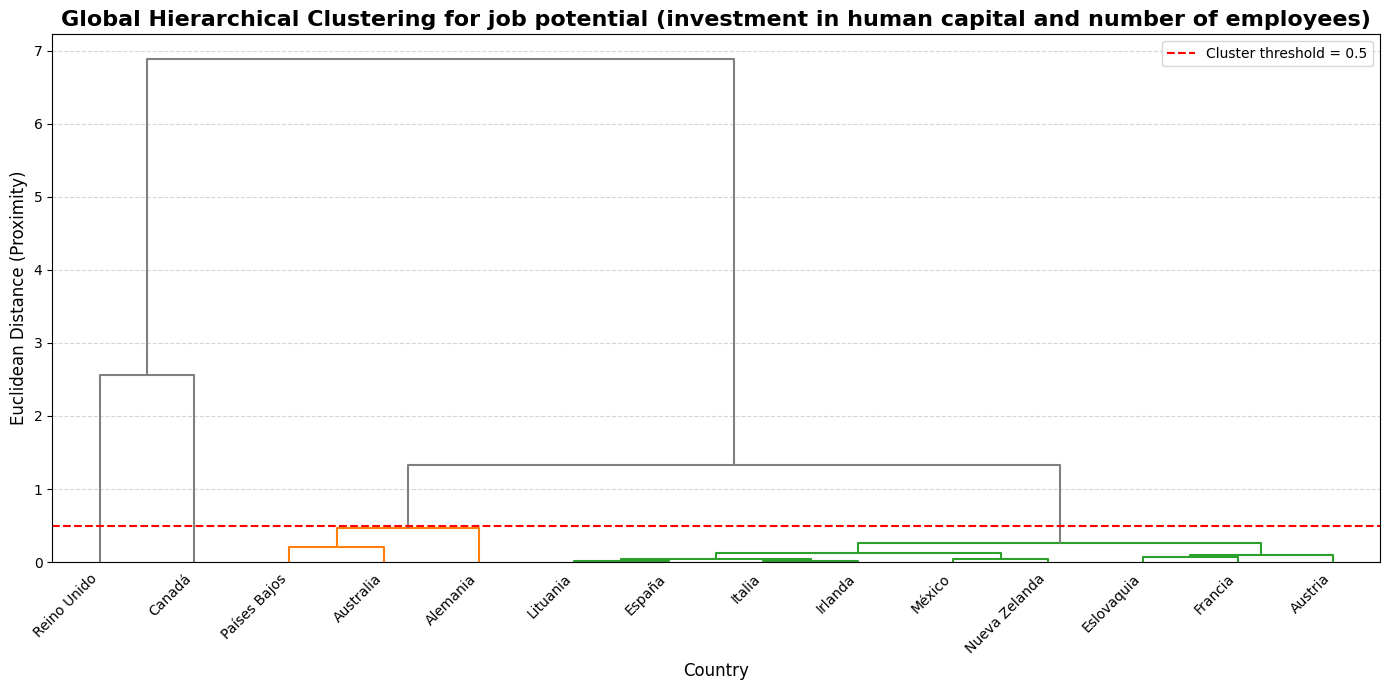

In [ ]:
# ------- For euclidean distance --------- #

job_potential = dendrogram_df[['Country_investment', 'No_employees']].values
scaler = StandardScaler()
job_normalized = scaler.fit_transform(job_potential)

X = job_normalized
country_labels = dendrogram_df['Country'].values
distance_matrix = pdist(X, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# -------- Setting threshold ------------ #

threshold = 0.5 # distance threshold
clusters = fcluster(linked, threshold, criterion='distance')

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    orientation='top',
    labels=country_labels,
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=threshold,
    above_threshold_color='gray'
)

# ------------- Plotting the dendrogram ------------ #
plt.title('Global Hierarchical Clustering for job potential (investment in human capital and number of employees)', fontsize=16, weight='bold')
plt.ylabel('Euclidean Distance (Proximity)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Cluster threshold = {threshold}')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
"""
def country_potential(department: str = None):
"""

for level in list(base_df['experience_level'].unique()):
    levels_df = base_df[base_df['experience_level'] == level]
    level_name = level
    no_employees = levels_df['experience_level'].count()
    level_income = levels_df['salary_in_usd'].sum()
    level_avg_income = levels_df['salary_in_usd'].mean()
    on_site = levels_df[levels_df['remote_ratio'] == 'On-site']['remote_ratio'].count()
    hybrid = levels_df[levels_df['remote_ratio'] == 'Hybrid']['remote_ratio'].count()
    remote = levels_df[levels_df['remote_ratio'] == 'Remote']['remote_ratio'].count()
    freelancer = levels_df[levels_df['employment_type'] == 'FL']['employment_type'].count()
    full_time = levels_df[levels_df['employment_type'] == 'FT']['employment_type'].count()
    part_time = levels_df[levels_df['employment_type'] == 'PT']['employment_type'].count()
    contract = levels_df[levels_df['employment_type'] == 'CT']['employment_type'].count()
    freelancer = levels_df[levels_df['employment_type'] == 'FL']['employment_type'].count()
    if level == 'EN':
        level_name = 'Entry level'
        row_1 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'MI':
        level_name = 'Medium'
        row_2 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'SE':
        level_name = 'Senior'
        row_3 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'EX':
        level_name = 'Executive'
        row_4 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]

employees_df = pd.DataFrame(np.array([row_1, row_2, row_3, row_4]), columns=['Level', 'FT_employees', 'PT_employees', 'CT_employees', 'FL_employees', 'No_employees', 'On_site', 'Hybrid', 'Remote', 'Level_income', 'Level_avg_income'])
employees_df = employees_df.astype({'Level': str, 'FT_employees': int, 'PT_employees':int, 'CT_employees': int, 'FL_employees': int, 'No_employees': int, 'On_site': int, 'Hybrid': int, 'Remote': int, 'Level_income': int, 'Level_avg_income': float})
employees_df

,Level,FT_employees,PT_employees,CT_employees,FL_employees,No_employees,On_site,Hybrid,Remote,Level_income,Level_avg_income
0,Entry level,6589,96,15,1,6701,1067,110,5524,681841362,101752.180570
1,Medium,20288,52,32,4,20376,3522,185,16669,2628381419,128993.984050
2,Senior,36214,46,44,6,36310,7933,172,28205,5800194125,159740.956348
3,Executive,1726,2,2,0,1730,416,35,1279,337612333,195151.637572


In [ ]:
barchart_fig = px.bar(
    data_frame=employees_df,
    y= 'Level',
    x= 'Level_income',
    orientation='h',
    labels = {'Level': 'Employee level', 'Level_income': 'Avg. income'},
    title='Average income per employee level',
    height=600
)
barchart_fig.update_layout(yaxis={'categoryorder':'total ascending'})
barchart_fig.show()

In [ ]:
bubble_chart = px.scatter(
    data_frame=employees_df,
    x= 'No_employees',
    y= 'Level_avg_income',
    size= 'Level_income',
    color='Level',
    hover_name= 'Level',
    title= 'Job potential per level',
    labels={'No_employees': 'Number of employees', 'Level_avg_income': 'Average income (USD)'},
)

bubble_chart.show()

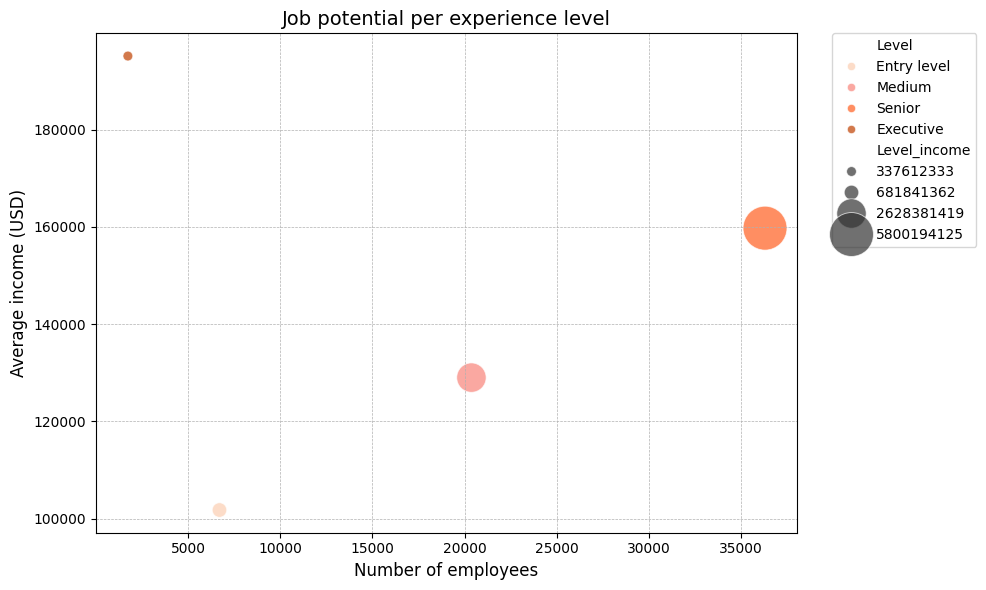

In [ ]:
# --- VISUALIZATION 1: External Viability (Scatter Plot) ---
plt.figure(figsize=(10, 6))
# Use log scale for Population to handle the wide range of values effectively
scatter = sns.scatterplot(
    data=employees_df,
    x='No_employees',
    y='Level_avg_income',
    size='Level_income',
    hue='Level',
    sizes=(50, 1000), # Define min/max size for markers
    alpha=0.7,
    palette={'Entry level': '#FBCEB1', 'Medium': '#F88379', 'Senior': '#FF5F1F', 'Executive': '#C04000'}
)

# Add annotations (country codes)
for i, row in employees_df.iterrows():
    plt.annotate(row['Level'], (row['Level_income'], row['Level_avg_income']), fontsize=9)

plt.title('Job potential per experience level', fontsize=14)
plt.xlabel('Number of employees', fontsize=12)
plt.ylabel('Average income (USD)', fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

# Social network analysis

In [ ]:
import networkx as nx

### Loading geodataset

In [ ]:
geo_df = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
geo_df

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,None,None,None,None,None,None,None,None,None,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Admin-0 country,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


In [ ]:
list(geo_df.columns)

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 'ADM0_A3_TW',
 'ADM0_A3_IN',
 'ADM0_A3_NP',
 'ADM0_A3_PK',
 'ADM0_A3_DE',
 'ADM0_A3_GB',
 'ADM0_A3_BR',
 'ADM0_A3_IL',
 'ADM0_A3_PS',
 'ADM0_A3_SA',
 'ADM0_A3_EG',
 'ADM0_A3_MA',
 'ADM0_A3_PT

In [ ]:
temp_df = geo_df[geo_df['NAME'].isin(['Taiwan'])]
temp_df['ISO_A2']

140    CN-TW
Name: ISO_A2, dtype: object

In [ ]:
geo_df.loc[geo_df['NAME'] == 'Norway', 'ISO_A2'] = 'NO'
geo_df.loc[geo_df['NAME'] == 'France', 'ISO_A2'] = 'FR'
geo_df.loc[geo_df['NAME'] == 'Taiwan', 'ISO_A2'] = 'TW'

In [ ]:
list(geo_df['NAME'].unique())

['Fiji',
 'Tanzania',
 'W. Sahara',
 'Canada',
 'United States of America',
 'Kazakhstan',
 'Uzbekistan',
 'Papua New Guinea',
 'Indonesia',
 'Argentina',
 'Chile',
 'Dem. Rep. Congo',
 'Somalia',
 'Kenya',
 'Sudan',
 'Chad',
 'Haiti',
 'Dominican Rep.',
 'Russia',
 'Bahamas',
 'Falkland Is.',
 'Norway',
 'Greenland',
 'Fr. S. Antarctic Lands',
 'Timor-Leste',
 'South Africa',
 'Lesotho',
 'Mexico',
 'Uruguay',
 'Brazil',
 'Bolivia',
 'Peru',
 'Colombia',
 'Panama',
 'Costa Rica',
 'Nicaragua',
 'Honduras',
 'El Salvador',
 'Guatemala',
 'Belize',
 'Venezuela',
 'Guyana',
 'Suriname',
 'France',
 'Ecuador',
 'Puerto Rico',
 'Jamaica',
 'Cuba',
 'Zimbabwe',
 'Botswana',
 'Namibia',
 'Senegal',
 'Mali',
 'Mauritania',
 'Benin',
 'Niger',
 'Nigeria',
 'Cameroon',
 'Togo',
 'Ghana',
 "Côte d'Ivoire",
 'Guinea',
 'Guinea-Bissau',
 'Liberia',
 'Sierra Leone',
 'Burkina Faso',
 'Central African Rep.',
 'Congo',
 'Gabon',
 'Eq. Guinea',
 'Zambia',
 'Malawi',
 'Mozambique',
 'eSwatini',
 'Angol

In [ ]:
list(geo_df['ISO_A2'].unique())

['FJ',
 'TZ',
 'EH',
 'CA',
 'US',
 'KZ',
 'UZ',
 'PG',
 'ID',
 'AR',
 'CL',
 'CD',
 'SO',
 'KE',
 'SD',
 'TD',
 'HT',
 'DO',
 'RU',
 'BS',
 'FK',
 'NO',
 'GL',
 'TF',
 'TL',
 'ZA',
 'LS',
 'MX',
 'UY',
 'BR',
 'BO',
 'PE',
 'CO',
 'PA',
 'CR',
 'NI',
 'HN',
 'SV',
 'GT',
 'BZ',
 'VE',
 'GY',
 'SR',
 'FR',
 'EC',
 'PR',
 'JM',
 'CU',
 'ZW',
 'BW',
 'NA',
 'SN',
 'ML',
 'MR',
 'BJ',
 'NE',
 'NG',
 'CM',
 'TG',
 'GH',
 'CI',
 'GN',
 'GW',
 'LR',
 'SL',
 'BF',
 'CF',
 'CG',
 'GA',
 'GQ',
 'ZM',
 'MW',
 'MZ',
 'SZ',
 'AO',
 'BI',
 'IL',
 'LB',
 'MG',
 'PS',
 'GM',
 'TN',
 'DZ',
 'JO',
 'AE',
 'QA',
 'KW',
 'IQ',
 'OM',
 'VU',
 'KH',
 'TH',
 'LA',
 'MM',
 'VN',
 'KP',
 'KR',
 'MN',
 'IN',
 'BD',
 'BT',
 'NP',
 'PK',
 'AF',
 'TJ',
 'KG',
 'TM',
 'IR',
 'SY',
 'AM',
 'SE',
 'BY',
 'UA',
 'PL',
 'AT',
 'HU',
 'MD',
 'RO',
 'LT',
 'LV',
 'EE',
 'DE',
 'BG',
 'GR',
 'TR',
 'AL',
 'HR',
 'CH',
 'LU',
 'BE',
 'NL',
 'PT',
 'ES',
 'IE',
 'NC',
 'SB',
 'NZ',
 'AU',
 'LK',
 'CN',
 'TW',
 'IT',
 'DK',

In [ ]:
temp_df = geo_df[geo_df['NAME'].isin(['Taiwan'])]
temp_df['ISO_A2']

140    TW
Name: ISO_A2, dtype: object

In [ ]:
base_df = base_df.replace({'employee_residence': {'HK': 'CN', 'AS': 'US', 'JE': 'GB', 'MT': 'GB', 'GU': 'US'}, 'company_location': {'HK': 'CN', 'AS': 'US', 'JE': 'GB', 'MT': 'GB', 'GU': 'US'}})
base_df = base_df[base_df['employee_residence'] != 'SG']
base_df = base_df[base_df['company_location'] != 'SG']
base_df = base_df[base_df['employee_residence'] != 'SM']
base_df = base_df[base_df['company_location'] != 'SM']

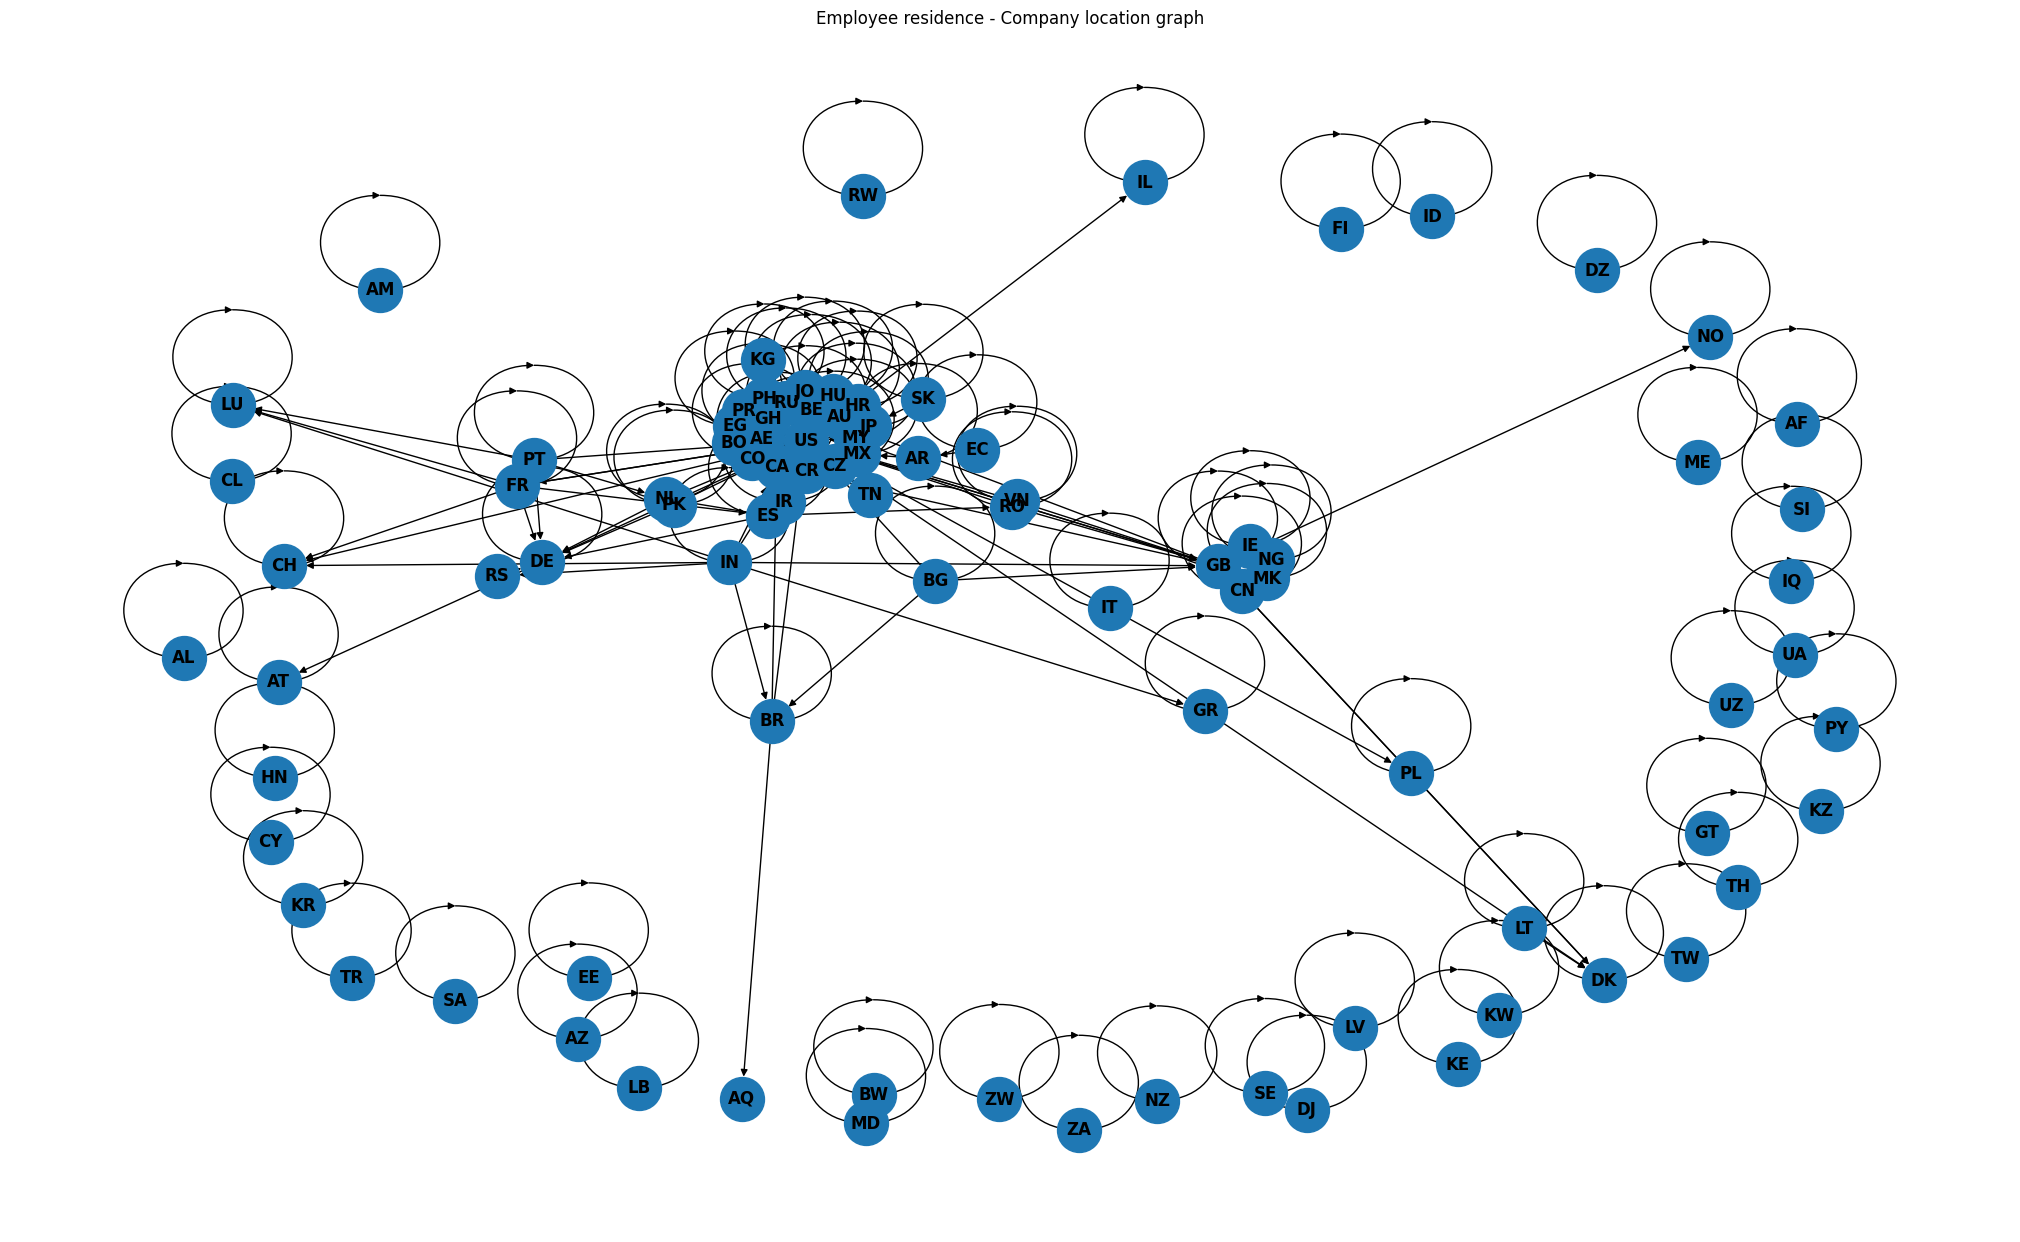

In [ ]:
base_graph = nx.from_pandas_edgelist(base_df, source='employee_residence', target='company_location', edge_attr='salary_in_usd', create_using=nx.DiGraph())

plt.figure(figsize=(20, 12))

nx.draw(
    G= base_graph,
    pos= nx.spring_layout(base_graph, seed= 42),
    with_labels= True,
    node_size= 1000,
    font_weight='bold'
)

plt.title('Employee residence - Company location graph')
plt.show()

In [ ]:
countries_locations = pd.read_csv('./data/projectU2.csv',usecols=['employee_latitude', 'employee_longitude', 'employee_residence'])
countries_locations

,employee_residence,employee_latitude,employee_longitude
0,US,37.090240,-95.71289
1,US,37.090240,-95.71289
2,US,37.090240,-95.71289
3,US,37.090240,-95.71289
4,US,37.090240,-95.71289
...,...,...,...
65112,US,37.090240,-95.71289
65113,US,37.090240,-95.71289
65114,US,37.090240,-95.71289
65115,US,37.090240,-95.71289


In [ ]:
#countries_locations_list = list(countries_locations.index.unique())
countries_locations = countries_locations.replace({'employee_residence': {'HK': 'CN', 'AS': 'US', 'JE': 'GB', 'MT': 'GB', 'GU': 'US'}})
countries_locations = countries_locations[countries_locations['employee_residence'] != 'SG']
countries_locations = countries_locations[countries_locations['employee_residence'] != 'SM']
countries_locations = countries_locations.drop_duplicates(subset=['employee_residence'])
countries_locations

,employee_residence,employee_latitude,employee_longitude
0,US,37.090240,-95.712890
9,AU,-25.274399,133.775130
12,CA,56.130367,-106.346770
18,AR,-38.416096,-63.616673
23,IE,53.412910,-8.243890
...,...,...,...
22217,AL,41.153330,20.168331
24596,DJ,11.825138,42.590275
28873,ZW,-19.015438,29.154858
37336,KW,29.311660,47.481766


In [ ]:
locations_dict = {}

for index, row in countries_locations.iterrows():
    locations_dict[row['employee_residence']] = (row['employee_latitude'], row['employee_longitude'])

print(locations_dict)

{'US': (37.09024, -95.71289), 'AU': (-25.274399, 133.77513), 'CA': (56.130367, -106.34677), 'AR': (-38.416096, -63.616673), 'IE': (53.41291, -8.24389), 'GB': (55.37805, -3.435973), 'SA': (23.885942, 45.079163), 'CH': (46.818188, 8.227512), 'DK': (56.26392, 9.501785), 'NL': (52.132633, 5.291266), 'SE': (60.128162, 18.643501), 'BG': (42.733883, 25.48583), 'HN': (15.199999, -86.241905), 'ZA': (-30.559483, 22.937506), 'PT': (39.39987, -8.224454), 'RU': (61.52401, 105.318756), 'IT': (41.87194, 12.56738), 'DE': (51.16569, 10.451526), 'ES': (40.46367, -3.74922), 'FR': (46.22764, 2.213749), 'PL': (51.919437, 19.145136), 'GR': (39.074207, 21.824312), 'BE': (50.503887, 4.469936), 'NZ': (-40.90056, 174.88597), 'AF': (33.93911, 67.70995), 'JP': (36.204823, 138.25293), 'HU': (47.162495, 19.503304), 'IN': (20.593683, 78.96288), 'CN': (35.86166, 104.1954), 'AE': (23.424076, 53.847816), 'MX': (23.6345, -102.55279), 'AT': (47.51623, 14.550072), 'NG': (9.081999, 8.675277), 'PH': (12.879721, 121.77402), 

C:\Users\ariel\AppData\Local\Temp\ipykernel_11200\2069276899.py:3: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




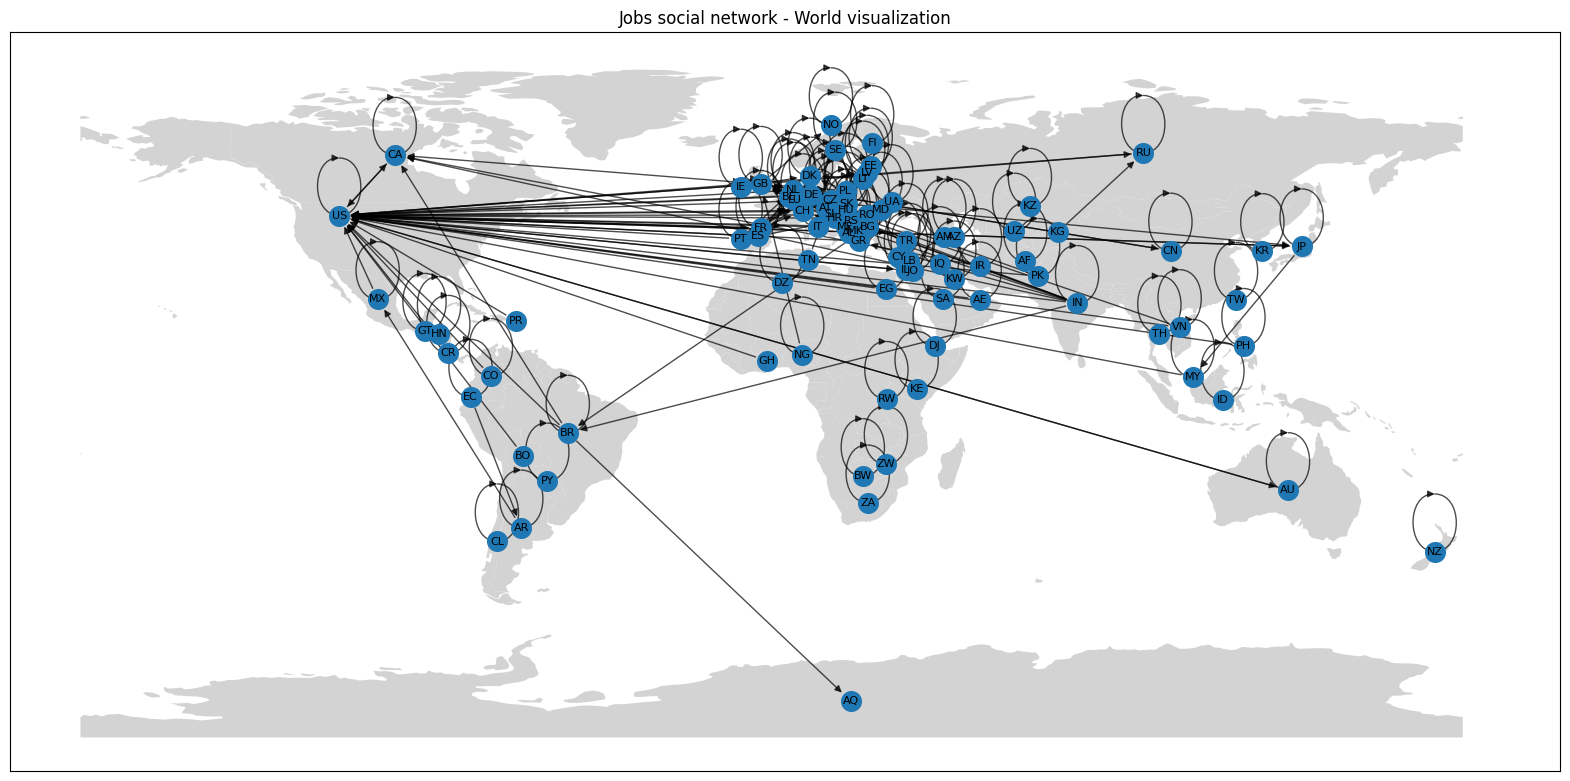

In [ ]:
geo_df = geo_df[['ISO_A2', 'geometry']]
geo_df = geo_df.to_crs(epsg=4326)
geo_df['centroid'] = geo_df.geometry.centroid

geo_df['coords'] = geo_df['centroid'].apply(lambda p: (p.x, p.y))

coordinates = {}

for node in base_graph.nodes():
    row = geo_df[geo_df['ISO_A2'] == node]
    if not row.empty:
        coordinates[node] = row['coords'].values[0]

fig, ax = plt.subplots(figsize=(20, 12))
geo_df.plot(ax=ax, color='lightgrey')

nx.draw_networkx_edges(base_graph, coordinates, ax=ax, width=1, alpha=0.7)
nx.draw_networkx_nodes(base_graph, coordinates, ax=ax, node_size=200)
nx.draw_networkx_labels(base_graph, coordinates, ax=ax, font_size=8)

plt.title('Jobs social network - World visualization')
plt.show()

### **Social Network graph analysis**

Creating a function to get the statisctics/characteristics of the graph.

In [ ]:
def analyze_social_network(G):
    """
    Analyzes a directed social network graph and returns key statistics
    
    Parameters:
    G: NetworkX DiGraph object
    
    Returns:
    Dictionary with network statistics
    """
    
    stats = {}
    
    # 1. Basic Structure
    stats['num_nodes'] = G.number_of_nodes()
    stats['num_edges'] = G.number_of_edges()
    stats['is_directed'] = G.is_directed()

    if stats['is_directed'] == True:
        stats['is_directed'] = 'Yes'
    else:
        stats['is_directed'] = 'No:('
    
    # 2. Degree Statistics
    degrees = [d for n, d in G.degree()]
    stats['average_degree'] = sum(degrees) / len(degrees) if degrees else 0
    
    # 3. Density
    stats['density'] = nx.density(G)
    
    # 4. Clustering Coefficient
    # For directed graphs, we convert to undirected for clustering
    G_undirected = G.to_undirected()
    stats['clustering_coefficient'] = nx.average_clustering(G_undirected)
    
    # 5. Centrality Measures (top 10 nodes)
    in_centrality = nx.in_degree_centrality(G)
    out_centrality = nx.out_degree_centrality(G)
    
    stats['top_in_centrality'] = sorted(in_centrality.items(), 
                                        key=lambda x: x[1], 
                                        reverse=True)[:10]
    stats['top_out_centrality'] = sorted(out_centrality.items(), 
                                         key=lambda x: x[1], 
                                         reverse=True)[:10]
    
    # 6. Strongly Connected Components
    sccs = list(nx.strongly_connected_components(G))
    stats['num_strongly_connected_components'] = len(sccs)
    stats['largest_scc_size'] = len(max(sccs, key=len)) if sccs else 0
    
    # 7. Largest Connected Component (weakly connected for directed graphs)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len) if wccs else set()
    stats['largest_connected_component_size'] = len(largest_wcc)
    
    # 8. Average Path Length (only for largest connected component)
    if largest_wcc:
        largest_subgraph = G.subgraph(largest_wcc)
        # For directed graphs, convert to undirected for path length
        largest_undirected = largest_subgraph.to_undirected()
        
        if nx.is_connected(largest_undirected):
            stats['average_path_length'] = nx.average_shortest_path_length(largest_undirected)
        else:
            stats['average_path_length'] = None
    else:
        stats['average_path_length'] = None
    
    return stats


# Function to print statistics in a readable format
def print_network_stats(stats):
    """
    Prints network statistics in a formatted way
    """
    print("=" * 60)
    print("SOCIAL NETWORK GRAPH STATISTICS")
    print("=" * 60)
    
    print("\nBASIC STRUCTURE")
    print(f"  • Number of Nodes: {stats['num_nodes']}")
    print(f"  • Number of Edges: {stats['num_edges']}")
    print(f"  • Directed Graph: {stats['is_directed']}")
    
    print("\nCONNECTIVITY METRICS")
    print(f"  • Average Degree: {stats['average_degree']:.2f}")
    print(f"  • Density: {stats['density']:.4f}")
    print(f"  • Clustering Coefficient: {stats['clustering_coefficient']:.4f}")
    
    print("\n CENTRALITY (Top 10 Countries)")
    print("\n  IN-DEGREE (Companies Located Here):")
    for i, (node, centrality) in enumerate(stats['top_in_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nOUT-DEGREE (Employees Residing Here):")
    for i, (node, centrality) in enumerate(stats['top_out_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nCOMPONENT ANALYSIS")
    print(f"  • Number of Strongly Connected Components: {stats['num_strongly_connected_components']}")
    print(f"  • Largest SCC Size: {stats['largest_scc_size']}")
    print(f"  • Largest Connected Component: {stats['largest_connected_component_size']} nodes")
    
    if stats['average_path_length']:
        print(f"  • Average Path Length: {stats['average_path_length']:.2f}")
    else:
        print(f"  • Average Path Length: N/A (graph not connected)")
    
    print("=" * 60)

In [ ]:
graph_measures = analyze_social_network(base_graph)
print_network_stats(graph_measures)

SOCIAL NETWORK GRAPH STATISTICS

BASIC STRUCTURE
  • Number of Nodes: 90
  • Number of Edges: 171
  • Directed Graph: Yes

CONNECTIVITY METRICS
  • Average Degree: 3.80
  • Density: 0.0213
  • Clustering Coefficient: 0.1155

 CENTRALITY (Top 10 Countries)

  IN-DEGREE (Companies Located Here):
    1. US: 0.3820
    2. GB: 0.1236
    3. DE: 0.0787
    4. CA: 0.0674
    5. DK: 0.0562
    6. CH: 0.0449
    7. LU: 0.0449
    8. NL: 0.0337
    9. BR: 0.0337
    10. RU: 0.0337

OUT-DEGREE (Employees Residing Here):
    1. IN: 0.1011
    2. US: 0.0899
    3. GB: 0.0787
    4. FR: 0.0674
    5. PT: 0.0562
    6. ES: 0.0562
    7. BG: 0.0449
    8. BR: 0.0449
    9. NL: 0.0337
    10. IT: 0.0337

COMPONENT ANALYSIS
  • Number of Strongly Connected Components: 78
  • Largest SCC Size: 13
  • Largest Connected Component: 54 nodes
  • Average Path Length: 2.52


In [ ]:
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
from networkx.algorithms import community

def detect_communities(G, method='louvain'):
    """
    Detects communities in a directed graph using various algorithms
    
    Parameters:
    G: NetworkX DiGraph object
    method: str - 'louvain', 'label_propagation', 'girvan_newman', or 'greedy_modularity'
    
    Returns:
    Dictionary mapping nodes to community IDs
    """
    
    # Convert directed graph to undirected for community detection
    G_undirected = G.to_undirected()
    
    print(f"Detecting communities using {method.upper()} method...")
    
    if method == 'louvain':
        # Louvain requires the python-louvain package
        # We'll use greedy_modularity_communities as an alternative
        communities_generator = community.greedy_modularity_communities(G_undirected, weight='weight')
        communities = list(communities_generator)
        
    elif method == 'label_propagation':
        communities_generator = community.label_propagation_communities(G_undirected)
        communities = list(communities_generator)
        
    elif method == 'girvan_newman':
        # Girvan-Newman returns a generator of community divisions
        # We take the first level (most granular)
        communities_generator = community.girvan_newman(G_undirected)
        # Get a reasonable number of communities (tune this parameter)
        for _ in range(3):  # Adjust iterations for more/fewer communities
            try:
                communities = next(communities_generator)
            except StopIteration:
                break
        communities = list(communities)
        
    elif method == 'greedy_modularity':
        communities_generator = community.greedy_modularity_communities(G_undirected)
        communities = list(communities_generator)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Convert to dictionary format: {node: community_id}
    node_to_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i
    
    return node_to_community, communities


def analyze_communities(G, node_to_community, communities):
    """
    Analyzes community structure and returns statistics
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    communities: list of sets, each set contains nodes in a community
    
    Returns:
    Dictionary with community statistics
    """
    
    stats = {}
    stats['num_communities'] = len(communities)
    stats['community_sizes'] = [len(comm) for comm in communities]
    stats['largest_community'] = max(stats['community_sizes'])
    stats['smallest_community'] = min(stats['community_sizes'])
    stats['average_community_size'] = np.mean(stats['community_sizes'])
    
    # Calculate modularity
    G_undirected = G.to_undirected()
    stats['modularity'] = community.modularity(G_undirected, communities)
    
    # Get top nodes in each community (by degree)
    stats['community_details'] = []
    for i, comm in enumerate(communities):
        subgraph = G.subgraph(comm)
        degrees = dict(subgraph.degree())
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        stats['community_details'].append({
            'id': i,
            'size': len(comm),
            'nodes': list(comm),
            'top_nodes': top_nodes
        })
    
    return stats


def print_community_stats(stats):
    """
    Prints community detection statistics in a formatted way
    """
    
    print(f"\nOVERALL STATISTICS")
    print(f"  • Number of Communities: {stats['num_communities']}")
    print(f"  • Modularity Score: {stats['modularity']:.4f}")
    print(f"  • Average Community Size: {stats['average_community_size']:.2f} nodes")
    print(f"  • Largest Community: {stats['largest_community']} nodes")
    print(f"  • Smallest Community: {stats['smallest_community']} nodes")
    
    print(f"\nCOMMUNITY DETAILS (sorted by size)")
    
    # Sort communities by size
    sorted_communities = sorted(stats['community_details'], 
                               key=lambda x: x['size'], 
                               reverse=True)
    
    for comm in sorted_communities:
        print(f"\n  Community {comm['id']} ({comm['size']} nodes)")
        print(f"    Top nodes by degree:")
        for node, degree in comm['top_nodes']:
            print(f"      • {node} (degree: {degree})")
    
    print("=" * 60)


def visualize_communities(G, node_to_community, title="Community Detection", 
                         figsize=(16, 12), layout='spring'):
    """
    Visualizes the graph with communities highlighted in different colors
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    title: str - plot title
    figsize: tuple - figure size
    layout: str - 'spring', 'kamada_kawai', or 'circular'
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Choose layout algorithm
    if layout == 'spring':
        pos = nx.spring_layout(G, k=1, iterations=50, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    
    # Get unique communities and assign colors
    unique_communities = sorted(set(node_to_community.values()))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    community_colors = {comm_id: colors[i] for i, comm_id in enumerate(unique_communities)}
    
    # Map each node to its color
    node_colors = [community_colors[node_to_community[node]] for node in G.nodes()]
    
    # Calculate node sizes based on degree
    node_sizes = [G.degree(node) * 100 + 100 for node in G.nodes()]
    
    # PLOT 1: Full network with communities
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, 
                          edgecolors='black', linewidths=1.5, ax=ax1)
    
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          alpha=0.2, arrows=True, 
                          arrowsize=10, arrowstyle='->', ax=ax1)
    
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax1)
    
    ax1.set_title(f"{title}\n({len(unique_communities)} communities detected)", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: Community distribution (bar chart)
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    sorted_communities = sorted(community_sizes.items())
    comm_ids = [f"C{c}" for c, _ in sorted_communities]
    sizes = [s for _, s in sorted_communities]
    bar_colors = [community_colors[c] for c, _ in sorted_communities]
    
    ax2.bar(comm_ids, sizes, color=bar_colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Community ID', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Nodes', fontsize=12, fontweight='bold')
    ax2.set_title('Community Size Distribution', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels if many communities
    if len(comm_ids) > 10:
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


def visualize_largest_communities(G, node_to_community, top_n=3, figsize=(18, 6)):
    """
    Visualizes the largest N communities separately for detailed inspection
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    top_n: int - number of largest communities to visualize
    """
    
    # Count nodes in each community
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    # Get top N largest communities
    largest_communities = sorted(community_sizes.items(), 
                                key=lambda x: x[1], 
                                reverse=True)[:top_n]
    
    fig, axes = plt.subplots(1, top_n, figsize=figsize)
    
    if top_n == 1:
        axes = [axes]
    
    colors = plt.cm.Set3(np.linspace(0, 1, top_n))
    
    for idx, (comm_id, size) in enumerate(largest_communities):
        # Get nodes in this community
        comm_nodes = [node for node, comm in node_to_community.items() if comm == comm_id]
        subgraph = G.subgraph(comm_nodes)
        
        # Layout for this subgraph
        pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)
        
        # Node sizes based on degree within community
        node_sizes = [subgraph.degree(node) * 150 + 100 for node in subgraph.nodes()]
        
        # Draw
        nx.draw_networkx_nodes(subgraph, pos, node_color=[colors[idx]], 
                              node_size=node_sizes, alpha=0.8, 
                              edgecolors='black', linewidths=1.5, ax=axes[idx])
        
        nx.draw_networkx_edges(subgraph, pos, edge_color='gray', 
                              alpha=0.3, arrows=True, 
                              arrowsize=10, ax=axes[idx])
        
        nx.draw_networkx_labels(subgraph, pos, font_size=8, 
                               font_weight='bold', ax=axes[idx])
        
        axes[idx].set_title(f"Community {comm_id}\n({size} nodes)", 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.suptitle('Largest Communities (Detailed View)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# MAIN EXECUTION FUNCTION
def perform_community_analysis(G, method='greedy_modularity'):
    """
    Complete community detection and visualization pipeline
    
    Parameters:
    G: NetworkX DiGraph
    method: str - community detection method
    """
    
    print(f"\n{'='*60}")
    print(f"Starting Community Detection Analysis")
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"{'='*60}\n")
    
    # Step 1: Detect communities
    node_to_community, communities = detect_communities(G, method=method)
    
    # Step 2: Analyze communities
    stats = analyze_communities(G, node_to_community, communities)
    
    # Step 3: Print statistics
    print_community_stats(stats)
    
    # Step 4: Visualize
    print("\nGenerating visualizations...")
    visualize_communities(G, node_to_community, 
                         title=f"IT Jobs Network - {method.upper()} Method")
    
    # Step 5: Detailed view of largest communities
    if stats['num_communities'] >= 3:
        visualize_largest_communities(G, node_to_community, top_n=min(3, stats['num_communities']))
    
    return node_to_community, communities, stats


Starting Community Detection Analysis
Graph: 90 nodes, 171 edges

Detecting communities using GREEDY_MODULARITY method...

OVERALL STATISTICS
  • Number of Communities: 44
  • Modularity Score: 0.6951
  • Average Community Size: 2.05 nodes
  • Largest Community: 15 nodes
  • Smallest Community: 1 nodes

COMMUNITY DETAILS (sorted by size)

  Community 0 (15 nodes)
    Top nodes by degree:
      • US (degree: 17)
      • AU (degree: 4)
      • CR (degree: 3)
      • AE (degree: 3)
      • HU (degree: 3)

  Community 1 (12 nodes)
    Top nodes by degree:
      • DE (degree: 9)
      • FR (degree: 6)
      • ES (degree: 6)
      • IN (degree: 5)
      • LU (degree: 5)

  Community 2 (9 nodes)
    Top nodes by degree:
      • GB (degree: 10)
      • CN (degree: 4)
      • RU (degree: 4)
      • MK (degree: 3)
      • VN (degree: 3)

  Community 3 (5 nodes)
    Top nodes by degree:
      • DK (degree: 5)
      • PL (degree: 4)
      • IT (degree: 3)
      • LT (degree: 3)
      • GR (degree

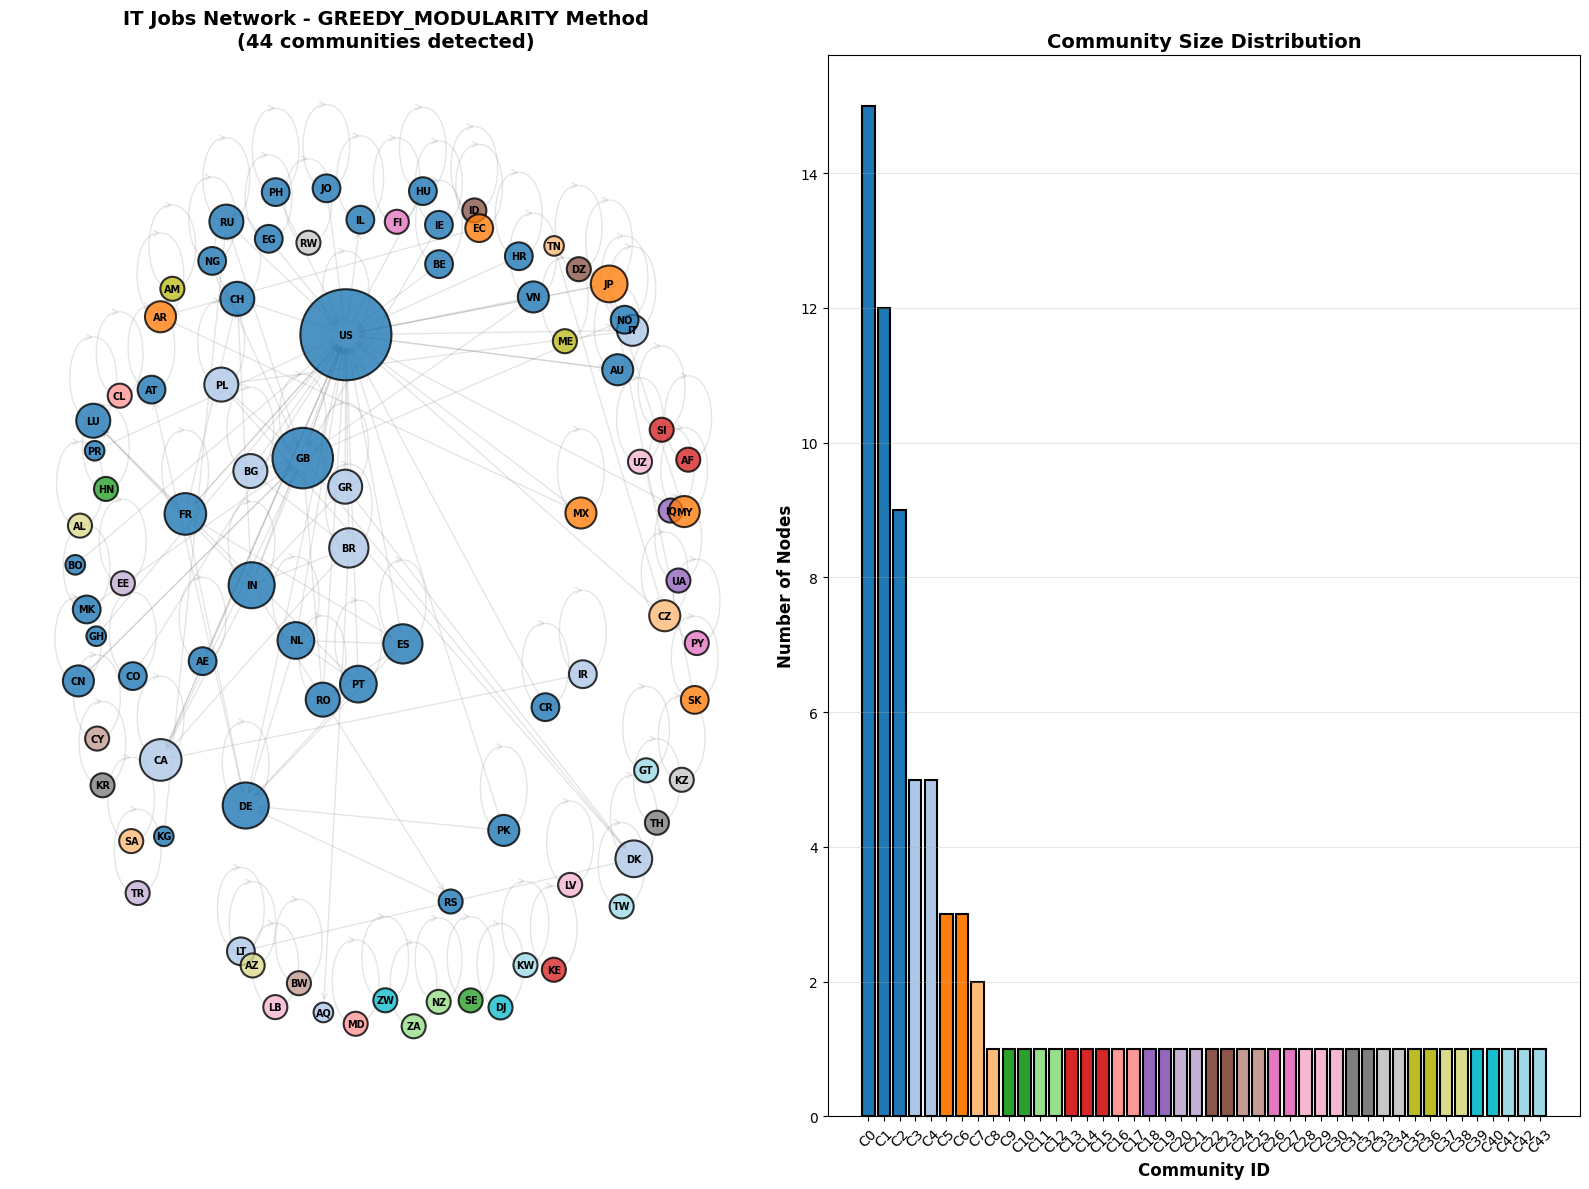

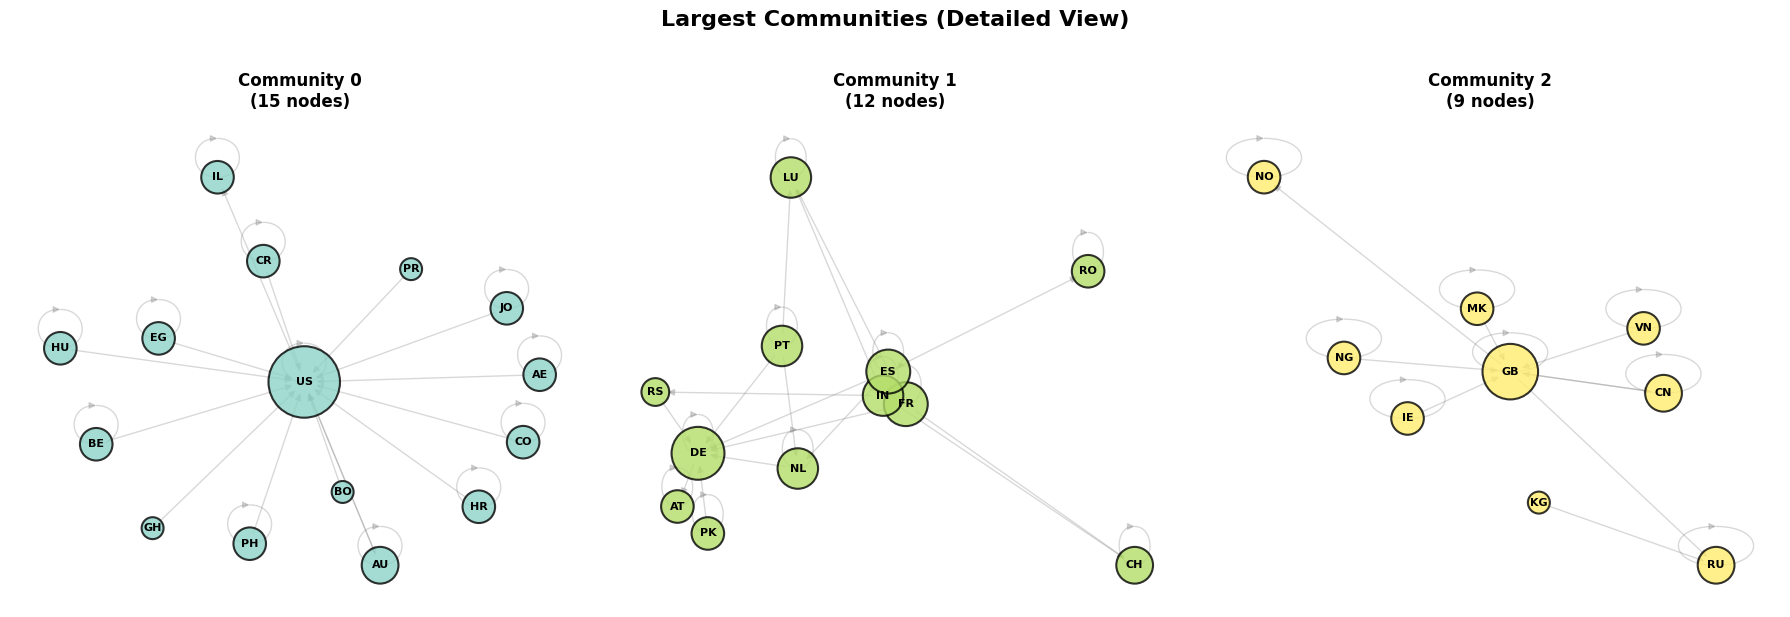

{'AE': 0,
 'GH': 0,
 'HU': 0,
 'JO': 0,
 'IL': 0,
 'CO': 0,
 'PH': 0,
 'EG': 0,
 'BO': 0,
 'HR': 0,
 'US': 0,
 'PR': 0,
 'AU': 0,
 'BE': 0,
 'CR': 0,
 'FR': 1,
 'IN': 1,
 'ES': 1,
 'AT': 1,
 'RO': 1,
 'PT': 1,
 'LU': 1,
 'CH': 1,
 'PK': 1,
 'NL': 1,
 'DE': 1,
 'RS': 1,
 'MK': 2,
 'VN': 2,
 'KG': 2,
 'IE': 2,
 'GB': 2,
 'NO': 2,
 'CN': 2,
 'RU': 2,
 'NG': 2,
 'PL': 3,
 'IT': 3,
 'LT': 3,
 'DK': 3,
 'GR': 3,
 'BG': 4,
 'AQ': 4,
 'BR': 4,
 'CA': 4,
 'IR': 4,
 'AR': 5,
 'EC': 5,
 'MX': 5,
 'JP': 6,
 'SK': 6,
 'MY': 6,
 'CZ': 7,
 'TN': 7,
 'SA': 8,
 'SE': 9,
 'HN': 10,
 'ZA': 11,
 'NZ': 12,
 'AF': 13,
 'KE': 14,
 'SI': 15,
 'MD': 16,
 'CL': 17,
 'IQ': 18,
 'UA': 19,
 'TR': 20,
 'EE': 21,
 'ID': 22,
 'DZ': 23,
 'BW': 24,
 'CY': 25,
 'PY': 26,
 'FI': 27,
 'LV': 28,
 'LB': 29,
 'UZ': 30,
 'KR': 31,
 'TH': 32,
 'KZ': 33,
 'RW': 34,
 'ME': 35,
 'AM': 36,
 'AZ': 37,
 'AL': 38,
 'DJ': 39,
 'ZW': 40,
 'KW': 41,
 'GT': 42,
 'TW': 43}

In [ ]:
node_to_community, communities, stats = perform_community_analysis(base_graph, method='greedy_modularity')
node_to_community


Starting Community Detection Analysis
Graph: 90 nodes, 171 edges

Detecting communities using GREEDY_MODULARITY method...

OVERALL STATISTICS
  • Number of Communities: 44
  • Modularity Score: 0.6951
  • Average Community Size: 2.05 nodes
  • Largest Community: 15 nodes
  • Smallest Community: 1 nodes

COMMUNITY DETAILS (sorted by size)

  Community 0 (15 nodes)
    Top nodes by degree:
      • US (degree: 17)
      • AU (degree: 4)
      • CR (degree: 3)
      • AE (degree: 3)
      • HU (degree: 3)

  Community 1 (12 nodes)
    Top nodes by degree:
      • DE (degree: 9)
      • FR (degree: 6)
      • ES (degree: 6)
      • IN (degree: 5)
      • LU (degree: 5)

  Community 2 (9 nodes)
    Top nodes by degree:
      • GB (degree: 10)
      • CN (degree: 4)
      • RU (degree: 4)
      • MK (degree: 3)
      • VN (degree: 3)

  Community 3 (5 nodes)
    Top nodes by degree:
      • DK (degree: 5)
      • PL (degree: 4)
      • IT (degree: 3)
      • LT (degree: 3)
      • GR (degree

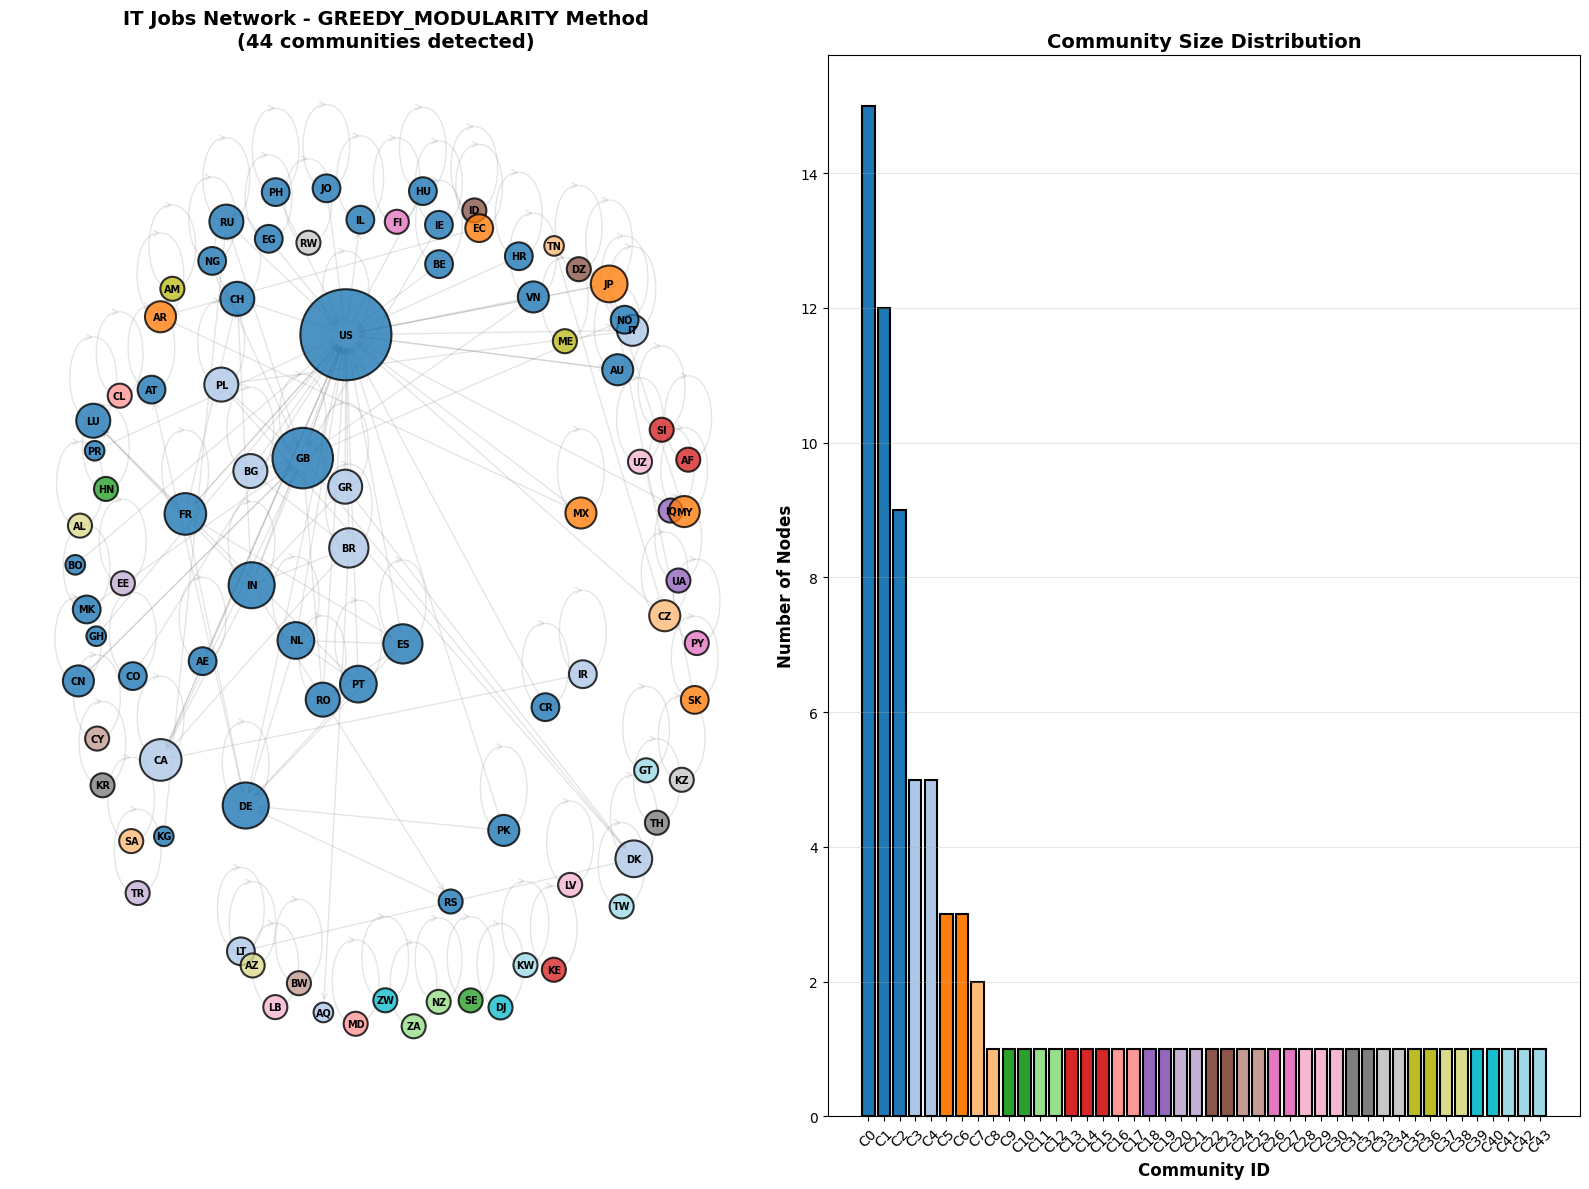

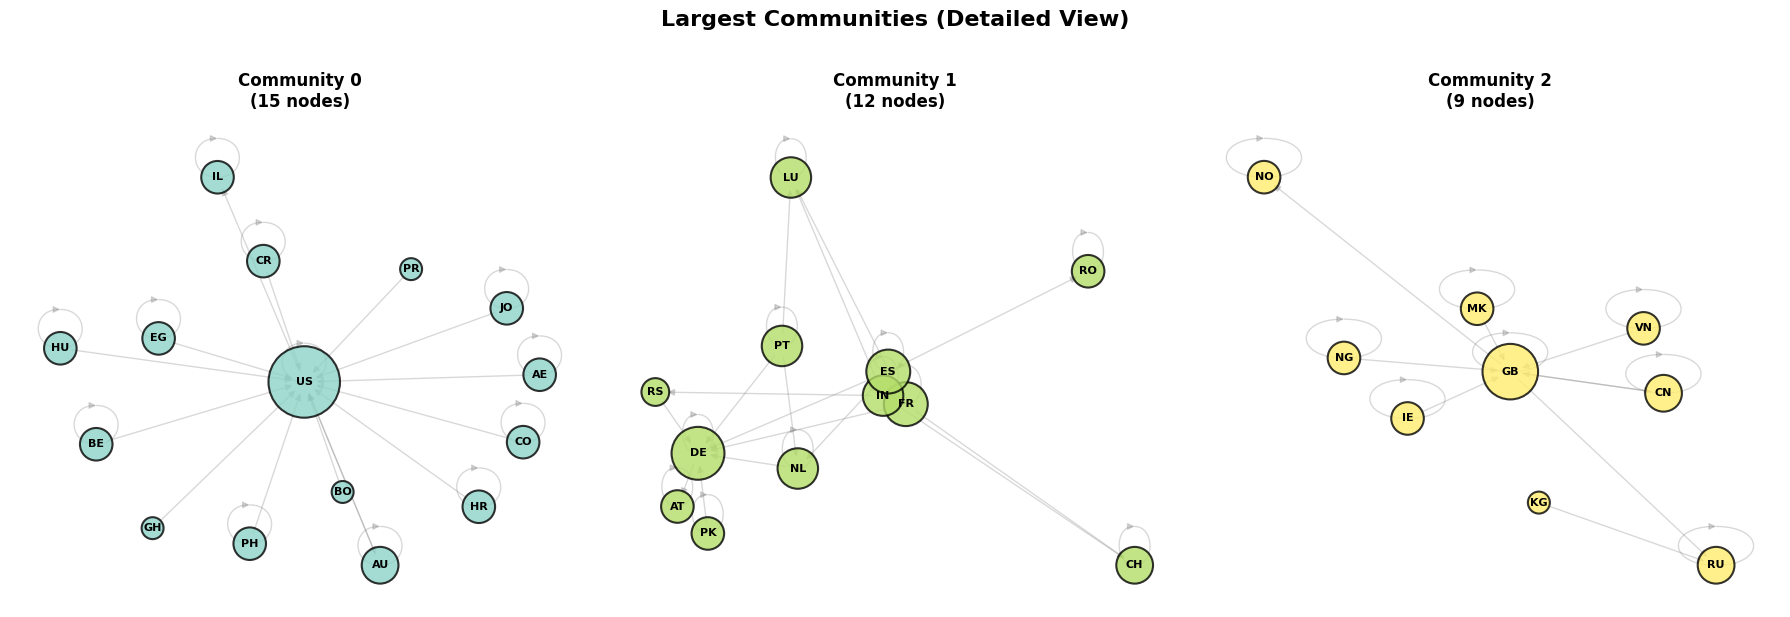

{'AE': 0,
 'GH': 0,
 'HU': 0,
 'JO': 0,
 'IL': 0,
 'CO': 0,
 'PH': 0,
 'EG': 0,
 'BO': 0,
 'HR': 0,
 'US': 0,
 'PR': 0,
 'AU': 0,
 'BE': 0,
 'CR': 0,
 'FR': 1,
 'IN': 1,
 'ES': 1,
 'AT': 1,
 'RO': 1,
 'PT': 1,
 'LU': 1,
 'CH': 1,
 'PK': 1,
 'NL': 1,
 'DE': 1,
 'RS': 1,
 'MK': 2,
 'VN': 2,
 'KG': 2,
 'IE': 2,
 'GB': 2,
 'NO': 2,
 'CN': 2,
 'RU': 2,
 'NG': 2,
 'PL': 3,
 'IT': 3,
 'LT': 3,
 'DK': 3,
 'GR': 3,
 'BG': 4,
 'AQ': 4,
 'BR': 4,
 'CA': 4,
 'IR': 4,
 'AR': 5,
 'EC': 5,
 'MX': 5,
 'JP': 6,
 'SK': 6,
 'MY': 6,
 'CZ': 7,
 'TN': 7,
 'SA': 8,
 'SE': 9,
 'HN': 10,
 'ZA': 11,
 'NZ': 12,
 'AF': 13,
 'KE': 14,
 'SI': 15,
 'MD': 16,
 'CL': 17,
 'IQ': 18,
 'UA': 19,
 'TR': 20,
 'EE': 21,
 'ID': 22,
 'DZ': 23,
 'BW': 24,
 'CY': 25,
 'PY': 26,
 'FI': 27,
 'LV': 28,
 'LB': 29,
 'UZ': 30,
 'KR': 31,
 'TH': 32,
 'KZ': 33,
 'RW': 34,
 'ME': 35,
 'AM': 36,
 'AZ': 37,
 'AL': 38,
 'DJ': 39,
 'ZW': 40,
 'KW': 41,
 'GT': 42,
 'TW': 43}

In [ ]:
node_to_community, communities, stats = perform_community_analysis(base_graph, method='greedy_modularity')
node_to_community

# Centrality meeasures

### **Betweenness centrality**

In [ ]:
def calculate_betweenness(G: nx.DiGraph, top_n: int = 10) -> dict:
    """
    Calculates betweenness centrality for a directed graph and displays the top N
    members with the highest centrality.

    Args:
        G (nx.DiGraph): The directed, weighted graph (e.g., Congress Twitter network).
        top_n (int): The number of top members to display.

    Returns:
        dict: A dictionary of {node: betweenness_score} for the entire graph.
    """
    print(f"**Calculating Betweenness Centrality for {G.number_of_nodes()} members...**\n")

    # Use the 'weight' attribute if available, although standard betweenness 
    # often ignores weights for directed graphs unless specified differently 
    # (nx.betweenness_centrality can use weights via 'weight' argument for 
    # shortest path calculation, but here we treat it as standard unweighted for robustness).
    betweenness = nx.betweenness_centrality(G, normalized=True, weight=None) 
    
    # Sort the results in descending order
    sorted_betweenness = dict(sorted(betweenness.items(), key=lambda item: item[1], reverse=True))
    
    # Display the top N
    print(f"***Top {top_n} Members by Betweenness Centrality (Highest Bridge/Broker Score)***")
    for i, (node, score) in enumerate(list(sorted_betweenness.items())[:top_n]):
        print(f"Rank {i+1}: Node '{node}' - Betweenness: {score:.4f}")
        
    return betweenness

In [ ]:
betweenness = calculate_betweenness(base_graph)
print(betweenness)

**Calculating Betweenness Centrality for 90 members...**

***Top 10 Members by Betweenness Centrality (Highest Bridge/Broker Score)***
Rank 1: Node 'US' - Betweenness: 0.0897
Rank 2: Node 'FR' - Betweenness: 0.0317
Rank 3: Node 'GB' - Betweenness: 0.0313
Rank 4: Node 'ES' - Betweenness: 0.0111
Rank 5: Node 'DE' - Betweenness: 0.0079
Rank 6: Node 'JP' - Betweenness: 0.0078
Rank 7: Node 'MX' - Betweenness: 0.0049
Rank 8: Node 'AR' - Betweenness: 0.0026
Rank 9: Node 'CZ' - Betweenness: 0.0024
Rank 10: Node 'CA' - Betweenness: 0.0023
{'US': 0.08973867892407218, 'AU': 0.0, 'CA': 0.0022982635342185904, 'AR': 0.002553626149131767, 'IE': 0.0, 'GB': 0.03126064010895472, 'DK': 0.0, 'SA': 0.0, 'CH': 0.0, 'NL': 0.0, 'SE': 0.0, 'BG': 0.0, 'BR': 0.00029792305073203946, 'HN': 0.0, 'ZA': 0.0, 'PT': 0.0, 'RU': 0.0022982635342185904, 'IT': 0.0, 'DE': 0.007916241062308479, 'ES': 0.011108273748723188, 'FR': 0.031664964249233915, 'PL': 0.0003830439223697651, 'GR': 6.384065372829418e-05, 'BE': 0.0, 'NZ': 0.

In [ ]:
def display_graph_by_betweenness(G: nx.DiGraph, betweenness_scores: dict):
    """
    Displays the directed graph, coloring and sizing the nodes based on
    their betweenness centrality score.

    Args:
        G (nx.DiGraph): The directed graph.
        betweenness_scores (dict): The dictionary of {node: betweenness_score} 
                                   from calculate_betweenness.
    """
    if not betweenness_scores:
        print("Error: Betweenness scores are empty. Please run Function 1 first.")
        return

    print("\n**Generating Graph Visualization...**")

    # 1. Prepare Node Attributes (Size and Color)
    
    # Extract scores into a list based on the order of nodes in the graph
    node_list = list(G.nodes())
    scores = np.array([betweenness_scores[node] for node in node_list])
    
    # Normalize scores for color mapping (0 to 1)
    if scores.max() > 0:
        normalized_scores = scores / scores.max()
    else:
        normalized_scores = scores # All zero if max is zero
        
    # Scale scores for node size (e.g., from 100 to 2000)
    # Adding a base size to ensure visibility of nodes with zero betweenness.
    base_size = 100
    scale_factor = 2500
    node_sizes = base_size + (scores * scale_factor)

    # 2. Setup Plot
    plt.figure(figsize=(15, 12))
    
    # Calculate a layout (Spectral is good for showing disconnected components)
    pos = nx.spring_layout(G, k=0.1, iterations=50, seed=42) # k adjusts distance between nodes

    # 3. Draw Nodes and Edges
    
    # Draw nodes, colored by centrality (using a 'viridis' colormap)
    nodes = nx.draw_networkx_nodes(
        G, pos, 
        node_size=node_sizes, 
        node_color=normalized_scores, 
        cmap=plt.cm.viridis,
        alpha=0.8
    )
    
    # Draw edges (directed graph)
    nx.draw_networkx_edges(
        G, pos, 
        arrowstyle='-|>', 
        arrowsize=10, 
        edge_color='gray', 
        alpha=0.2
    )
    
    # Optional: Draw a few labels for the highest centrality nodes
    top_nodes = list(dict(sorted(betweenness_scores.items(), key=lambda item: item[1], reverse=True)).keys())[:5]
    labels = {node: node for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color='red')

    # 4. Add Colorbar and Title
    if nodes is not None:
        cbar = plt.colorbar(nodes)
        cbar.set_label('Betweenness Centrality (Normalized)')

    plt.title("Congress Twitter Network: Nodes Sized and Colored by Betweenness Centrality")
    plt.axis('off') # Hide the axis
    plt.show()


**Generating Graph Visualization...**


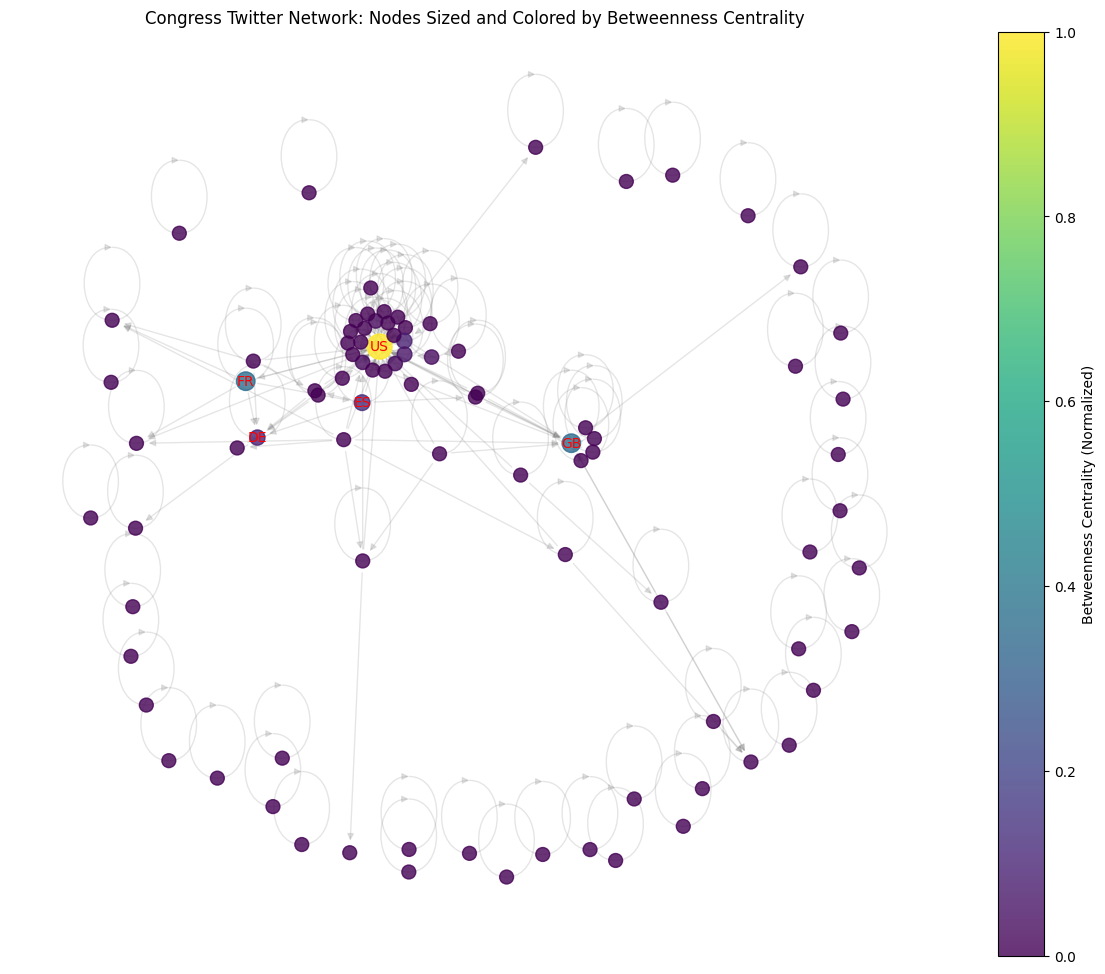

In [ ]:
betwenness_graph = display_graph_by_betweenness(base_graph, betweenness)
betwenness_graph

# PageRank

In [ ]:
def calculate_pagerank(G: nx.DiGraph, alpha: float = 0.85, max_iter: int = 100, 
                       tol: float = 1.0e-6, top_n: int = 10) -> dict:
    """
    Calculates PageRank centrality for a directed graph.
    
    PageRank measures node importance based on the structure of incoming links.
    A node is important if it is linked to by other important nodes.
    
    Args:
        G (nx.DiGraph): The directed graph
        alpha (float): Damping parameter (default 0.85)
        max_iter (int): Maximum number of iterations
        tol (float): Error tolerance for convergence
        top_n (int): Number of top members to display
    
    Returns:
        dict: A dictionary of {node: pagerank_score} for the entire graph
    """
    print(f"**Calculating PageRank for {G.number_of_nodes()} members...**")
    print(f"Parameters: alpha={alpha}, max_iter={max_iter}, tolerance={tol}\n")
    
    # Calculate PageRank
    pagerank = nx.pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol, weight='weight')
    
    # Sort the results in descending order
    sorted_pagerank = dict(sorted(pagerank.items(), key=lambda item: item[1], reverse=True))
    
    # Display the top N
    print(f"***Top {top_n} Members by PageRank (Highest Influence Score)***")
    for i, (node, score) in enumerate(list(sorted_pagerank.items())[:top_n]):
        print(f"Rank {i+1}: Node '{node}' - PageRank: {score:.6f}")
    
    print(f"\n**PageRank Statistics:**")
    scores = list(pagerank.values())
    print(f"  • Mean PageRank: {np.mean(scores):.6f}")
    print(f"  • Median PageRank: {np.median(scores):.6f}")
    print(f"  • Max PageRank: {np.max(scores):.6f}")
    print(f"  • Min PageRank: {np.min(scores):.6f}")
    print(f"  • Std Dev: {np.std(scores):.6f}")
    
    return pagerank


def visualize_pagerank(G: nx.DiGraph, pagerank_scores: dict, top_n_highlight: int = 20):
    """
    Visualizes the directed graph with nodes colored and sized by PageRank.
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of {node: pagerank_score}
        top_n_highlight (int): Number of top nodes to label
    """
    if not pagerank_scores:
        print("Error: PageRank scores are empty. Please run calculate_pagerank first.")
        return
    
    print("\n**Generating PageRank Visualization...**")
    
    # Prepare node attributes
    node_list = list(G.nodes())
    scores = np.array([pagerank_scores[node] for node in node_list])
    
    # Normalize scores for color mapping (0 to 1)
    if scores.max() > 0:
        normalized_scores = scores / scores.max()
    else:
        normalized_scores = scores
    
    # Scale scores for node size
    base_size = 100
    scale_factor = 5000
    node_sizes = base_size + (scores * scale_factor)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
    
    # PLOT 1: Network visualization
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=normalized_scores,
        cmap=plt.cm.plasma,
        alpha=0.8,
        ax=ax1
    )
    
    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='-|>',
        arrowsize=8,
        edge_color='gray',
        alpha=0.15,
        ax=ax1
    )
    
    # Label top nodes
    top_nodes = list(dict(sorted(pagerank_scores.items(), 
                                 key=lambda item: item[1], 
                                 reverse=True)).keys())[:top_n_highlight]
    labels = {node: str(node) for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, 
                           font_color='white', font_weight='bold', ax=ax1)
    
    if nodes is not None:
        cbar = plt.colorbar(nodes, ax=ax1)
        cbar.set_label('PageRank Score (Normalized)', fontsize=12)
    
    ax1.set_title("Congress Twitter Network: Nodes Sized and Colored by PageRank", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: PageRank distribution histogram
    scores_sorted = sorted(pagerank_scores.values(), reverse=True)
    ax2.hist(scores_sorted, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(scores_sorted), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(scores_sorted):.6f}')
    ax2.axvline(np.median(scores_sorted), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(scores_sorted):.6f}')
    
    ax2.set_xlabel('PageRank Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('PageRank Score Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
def calculate_pagerank(G: nx.DiGraph, alpha: float = 0.85, max_iter: int = 100, 
                       tol: float = 1.0e-6, top_n: int = 10) -> dict:
    """
    Calculates PageRank centrality for a directed graph.
    
    PageRank measures node importance based on the structure of incoming links.
    A node is important if it is linked to by other important nodes.
    
    Args:
        G (nx.DiGraph): The directed graph
        alpha (float): Damping parameter (default 0.85)
        max_iter (int): Maximum number of iterations
        tol (float): Error tolerance for convergence
        top_n (int): Number of top members to display
    
    Returns:
        dict: A dictionary of {node: pagerank_score} for the entire graph
    """
    print(f"**Calculating PageRank for {G.number_of_nodes()} members...**")
    print(f"Parameters: alpha={alpha}, max_iter={max_iter}, tolerance={tol}\n")
    
    # Calculate PageRank
    pagerank = nx.pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol, weight='weight')
    
    # Sort the results in descending order
    sorted_pagerank = dict(sorted(pagerank.items(), key=lambda item: item[1], reverse=True))
    
    # Display the top N
    print(f"***Top {top_n} Members by PageRank (Highest Influence Score)***")
    for i, (node, score) in enumerate(list(sorted_pagerank.items())[:top_n]):
        print(f"Rank {i+1}: Node '{node}' - PageRank: {score:.6f}")
    
    print(f"\n**PageRank Statistics:**")
    scores = list(pagerank.values())
    print(f"  • Mean PageRank: {np.mean(scores):.6f}")
    print(f"  • Median PageRank: {np.median(scores):.6f}")
    print(f"  • Max PageRank: {np.max(scores):.6f}")
    print(f"  • Min PageRank: {np.min(scores):.6f}")
    print(f"  • Std Dev: {np.std(scores):.6f}")
    
    return pagerank


def visualize_pagerank(G: nx.DiGraph, pagerank_scores: dict, top_n_highlight: int = 20):
    """
    Visualizes the directed graph with nodes colored and sized by PageRank.
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of {node: pagerank_score}
        top_n_highlight (int): Number of top nodes to label
    """
    if not pagerank_scores:
        print("Error: PageRank scores are empty. Please run calculate_pagerank first.")
        return
    
    print("\n**Generating PageRank Visualization...**")
    
    # Prepare node attributes
    node_list = list(G.nodes())
    scores = np.array([pagerank_scores[node] for node in node_list])
    
    # Normalize scores for color mapping (0 to 1)
    if scores.max() > 0:
        normalized_scores = scores / scores.max()
    else:
        normalized_scores = scores
    
    # Scale scores for node size
    base_size = 100
    scale_factor = 5000
    node_sizes = base_size + (scores * scale_factor)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)
    
    # PLOT 1: Network visualization
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=normalized_scores,
        cmap=plt.cm.plasma,
        alpha=0.8,
        ax=ax1
    )
    
    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='-|>',
        arrowsize=8,
        edge_color='gray',
        alpha=0.15,
        ax=ax1
    )
    
    # Label top nodes
    top_nodes = list(dict(sorted(pagerank_scores.items(), 
                                 key=lambda item: item[1], 
                                 reverse=True)).keys())[:top_n_highlight]
    labels = {node: str(node) for node in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, 
                           font_color='white', font_weight='bold', ax=ax1)
    
    if nodes is not None:
        cbar = plt.colorbar(nodes, ax=ax1)
        cbar.set_label('PageRank Score (Normalized)', fontsize=12)
    
    ax1.set_title("Congress Twitter Network: Nodes Sized and Colored by PageRank", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: PageRank distribution histogram
    scores_sorted = sorted(pagerank_scores.values(), reverse=True)
    ax2.hist(scores_sorted, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(scores_sorted), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(scores_sorted):.6f}')
    ax2.axvline(np.median(scores_sorted), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(scores_sorted):.6f}')
    
    ax2.set_xlabel('PageRank Score', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('PageRank Score Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


***TOP 10 MEMBERS BY PAGERANK (Most Influential)***
------------------------------------------------------------
  Rank 1: Node 'CH' - PageRank: 0.077015
  Rank 2: Node 'US' - PageRank: 0.076099
  Rank 3: Node 'IL' - PageRank: 0.065099
  Rank 4: Node 'DK' - PageRank: 0.049090
  Rank 5: Node 'AT' - PageRank: 0.031404
  Rank 6: Node 'NO' - PageRank: 0.029645
  Rank 7: Node 'LU' - PageRank: 0.025478
  Rank 8: Node 'CA' - PageRank: 0.025373
  Rank 9: Node 'GB' - PageRank: 0.022737
  Rank 10: Node 'AU' - PageRank: 0.017004

**PAGERANK STATISTICS:**
  • Mean PageRank: 0.011111
  • Median PageRank: 0.011257
  • Max PageRank: 0.077015
  • Min PageRank: 0.001689
  • Standard Deviation: 0.013703

**GENERATING PAGERANK VISUALIZATIONS...**



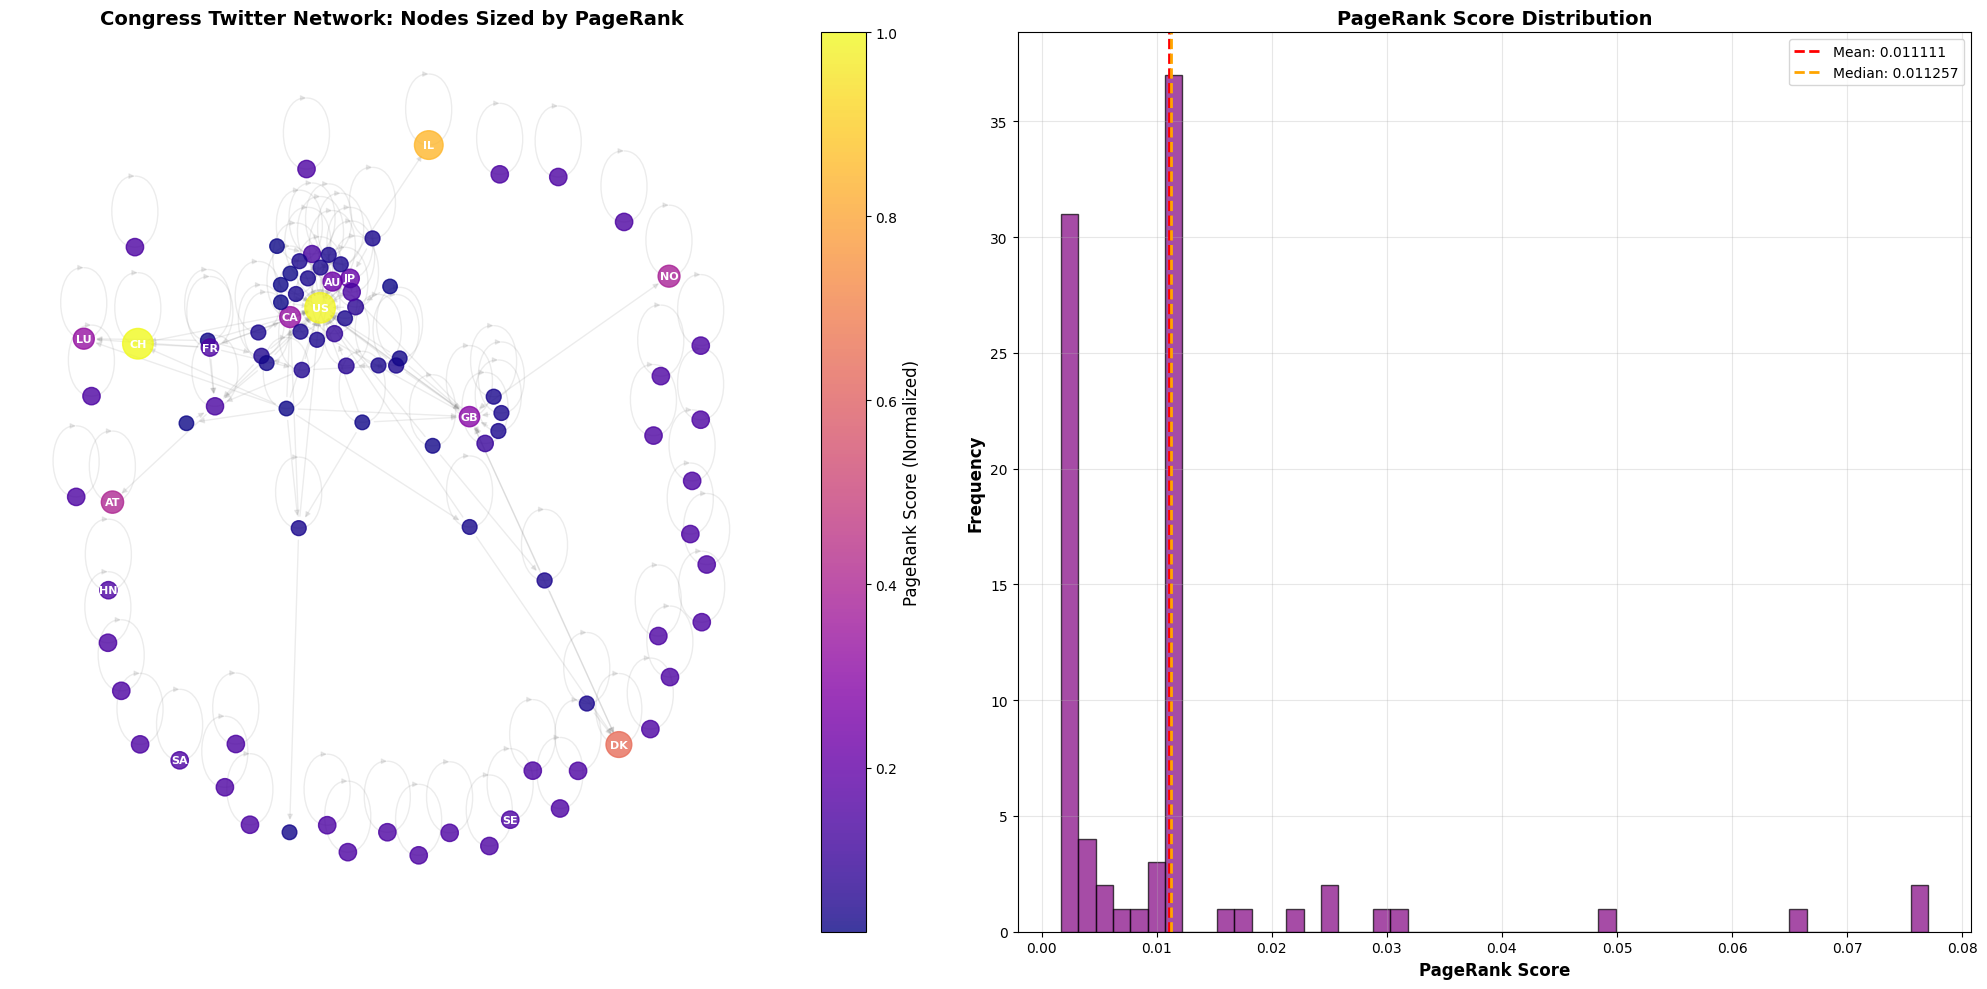

In [ ]:
# Calculate PageRank with standard parameters
pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1.0e-6, weight='weight')

# Sort by PageRank score
sorted_pagerank = dict(sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True))

# Display Top 10
print("***TOP 10 MEMBERS BY PAGERANK (Most Influential)***")
print("-" * 60)
for i, (node, score) in enumerate(list(sorted_pagerank.items())[:10]):
    print(f"  Rank {i+1}: Node '{node}' - PageRank: {score:.6f}")

# Statistics
scores = list(pagerank_scores.values())
print(f"\n**PAGERANK STATISTICS:**")
print(f"  • Mean PageRank: {np.mean(scores):.6f}")
print(f"  • Median PageRank: {np.median(scores):.6f}")
print(f"  • Max PageRank: {np.max(scores):.6f}")
print(f"  • Min PageRank: {np.min(scores):.6f}")
print(f"  • Standard Deviation: {np.std(scores):.6f}")

print("\n**GENERATING PAGERANK VISUALIZATIONS...**\n")

# Prepare node attributes
node_list = list(G.nodes())
pr_values = np.array([pagerank_scores[node] for node in node_list])

# Normalize for colors
normalized_pr = pr_values / pr_values.max()

# Size nodes by PageRank
node_sizes = 100 + (pr_values * 5000)

# Create figure
fig = plt.figure(figsize=(20, 10))

# Layout
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# SUBPLOT 1: Network with PageRank
ax1 = plt.subplot(1, 2, 1)
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=normalized_pr,
    cmap=plt.cm.plasma,
    alpha=0.8,
    ax=ax1
)

nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>',
    arrowsize=8,
    edge_color='gray',
    alpha=0.15,
    ax=ax1
)

# Label top 15 nodes
top_15_nodes = list(sorted_pagerank.keys())[:15]
labels = {node: str(node) for node in top_15_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, 
                       font_color='white', font_weight='bold', ax=ax1)

cbar = plt.colorbar(nodes, ax=ax1)
cbar.set_label('PageRank Score (Normalized)', fontsize=12)

ax1.set_title("Congress Twitter Network: Nodes Sized by PageRank", 
              fontsize=14, fontweight='bold')
ax1.axis('off')

# SUBPLOT 2: PageRank Distribution
ax2 = plt.subplot(1, 2, 2)
scores_sorted = sorted(pagerank_scores.values(), reverse=True)
ax2.hist(scores_sorted, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(scores_sorted), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(scores_sorted):.6f}')
ax2.axvline(np.median(scores_sorted), color='orange', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(scores_sorted):.6f}')

ax2.set_xlabel('PageRank Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('PageRank Score Distribution', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def compare_pagerank_with_degree(G: nx.DiGraph, pagerank_scores: dict, top_n: int = 15):
    """
    Compares PageRank with in-degree, out-degree, and total degree centrality.
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of {node: pagerank_score}
        top_n (int): Number of top nodes to compare
    """
    print(f"\n**Comparing PageRank with Degree Centralities (Top {top_n} nodes)**\n")
    
    # Calculate degree centralities
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())
    total_degree = dict(G.degree())
    
    # Get top nodes by each metric
    top_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_in_degree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_out_degree = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_total_degree = sorted(total_degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    # Create comparison dataframe
    comparison_data = []
    for i in range(top_n):
        comparison_data.append({
            'Rank': i + 1,
            'PageRank_Node': top_pagerank[i][0],
            'PageRank_Score': f"{top_pagerank[i][1]:.6f}",
            'InDegree_Node': top_in_degree[i][0],
            'InDegree_Count': top_in_degree[i][1],
            'OutDegree_Node': top_out_degree[i][0],
            'OutDegree_Count': top_out_degree[i][1],
            'TotalDegree_Node': top_total_degree[i][0],
            'TotalDegree_Count': top_total_degree[i][1]
        })
    
    # Print comparison table
    print("=" * 120)
    print(f"{'Rank':<6} {'PageRank':<12} {'PR Score':<12} {'In-Degree':<12} {'In-Count':<10} "
          f"{'Out-Degree':<12} {'Out-Count':<10} {'Total Deg':<12} {'Tot-Count':<10}")
    print("=" * 120)
    
    for row in comparison_data:
        print(f"{row['Rank']:<6} {row['PageRank_Node']:<12} {row['PageRank_Score']:<12} "
              f"{row['InDegree_Node']:<12} {row['InDegree_Count']:<10} "
              f"{row['OutDegree_Node']:<12} {row['OutDegree_Count']:<10} "
              f"{row['TotalDegree_Node']:<12} {row['TotalDegree_Count']:<10}")
    
    print("=" * 120)
    
    # Analyze overlap between metrics
    pagerank_nodes = set([node for node, _ in top_pagerank])
    in_degree_nodes = set([node for node, _ in top_in_degree])
    out_degree_nodes = set([node for node, _ in top_out_degree])
    total_degree_nodes = set([node for node, _ in top_total_degree])
    
    print(f"\n**Overlap Analysis (Top {top_n} nodes):**")
    print(f"  • PageRank ∩ In-Degree: {len(pagerank_nodes & in_degree_nodes)} nodes")
    print(f"  • PageRank ∩ Out-Degree: {len(pagerank_nodes & out_degree_nodes)} nodes")
    print(f"  • PageRank ∩ Total Degree: {len(pagerank_nodes & total_degree_nodes)} nodes")
    print(f"  • All four metrics: {len(pagerank_nodes & in_degree_nodes & out_degree_nodes & total_degree_nodes)} nodes")


# Centrality measures comparison

In [ ]:
def comprehensive_centrality_comparison(G: nx.DiGraph, pagerank_scores: dict, 
                                       betweenness_scores: dict, top_n: int = 20):
    """
    Comprehensive comparison of all centrality metrics:
    - PageRank
    - Betweenness Centrality
    - In-Degree Centrality
    - Out-Degree Centrality
    - Closeness Centrality
    
    Args:
        G (nx.DiGraph): The directed graph
        pagerank_scores (dict): Dictionary of PageRank scores
        betweenness_scores (dict): Dictionary of Betweenness scores
        top_n (int): Number of top nodes to analyze
    """
    print(f"\n{'='*80}")
    print(f"COMPREHENSIVE CENTRALITY ANALYSIS (Top {top_n} Nodes)")
    print(f"{'='*80}\n")
    
    # Calculate all centralities
    in_centrality = nx.in_degree_centrality(G)
    out_centrality = nx.out_degree_centrality(G)
    
    # Closeness centrality (using weakly connected component)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len) if wccs else set()
    if largest_wcc:
        subgraph = G.subgraph(largest_wcc)
        closeness = nx.closeness_centrality(subgraph)
    else:
        closeness = {node: 0 for node in G.nodes()}
    
    # Create comprehensive data structure
    all_nodes = list(G.nodes())
    centrality_data = []
    
    for node in all_nodes:
        centrality_data.append({
            'node': node,
            'pagerank': pagerank_scores.get(node, 0),
            'betweenness': betweenness_scores.get(node, 0),
            'in_degree': in_centrality.get(node, 0),
            'out_degree': out_centrality.get(node, 0),
            'closeness': closeness.get(node, 0)
        })
    
    # Sort by PageRank
    centrality_data.sort(key=lambda x: x['pagerank'], reverse=True)
    
    # Print top nodes with all metrics
    print(f"{'Node':<8} {'PageRank':<12} {'Betweenness':<14} {'In-Degree':<12} "
          f"{'Out-Degree':<12} {'Closeness':<12}")
    print("=" * 80)
    
    for i, data in enumerate(centrality_data[:top_n]):
        print(f"{data['node']:<8} {data['pagerank']:<12.6f} {data['betweenness']:<14.6f} "
              f"{data['in_degree']:<12.4f} {data['out_degree']:<12.4f} {data['closeness']:<12.4f}")
    
    print("=" * 80)
    
    # Correlation analysis
    print("\n**Correlation Analysis Between Centrality Metrics:**")
    
    import scipy.stats as stats
    
    pr_values = [d['pagerank'] for d in centrality_data]
    bt_values = [d['betweenness'] for d in centrality_data]
    in_values = [d['in_degree'] for d in centrality_data]
    out_values = [d['out_degree'] for d in centrality_data]
    cl_values = [d['closeness'] for d in centrality_data]
    
    correlations = {
        'PageRank vs Betweenness': stats.spearmanr(pr_values, bt_values)[0],
        'PageRank vs In-Degree': stats.spearmanr(pr_values, in_values)[0],
        'PageRank vs Out-Degree': stats.spearmanr(pr_values, out_values)[0],
        'PageRank vs Closeness': stats.spearmanr(pr_values, cl_values)[0],
        'Betweenness vs In-Degree': stats.spearmanr(bt_values, in_values)[0],
        'Betweenness vs Out-Degree': stats.spearmanr(bt_values, out_values)[0]
    }
    
    for pair, corr in correlations.items():
        print(f"  • {pair}: {corr:.4f}")
    
    # Visualization
    visualize_centrality_comparison(centrality_data, top_n)
    
    return centrality_data


def visualize_centrality_comparison(centrality_data: list, top_n: int = 20):
    """
    Creates visualizations comparing different centrality metrics.
    
    Args:
        centrality_data (list): List of dictionaries with all centrality scores
        top_n (int): Number of top nodes to visualize
    """
    top_data = centrality_data[:top_n]
    nodes = [str(d['node']) for d in top_data]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Centrality Metrics Comparison (Top 20 Nodes)', 
                 fontsize=16, fontweight='bold')
    
    # PageRank
    pr_scores = [d['pagerank'] for d in top_data]
    axes[0, 0].barh(nodes, pr_scores, color='purple', alpha=0.7)
    axes[0, 0].set_xlabel('PageRank Score')
    axes[0, 0].set_title('PageRank Centrality')
    axes[0, 0].invert_yaxis()
    
    # Betweenness
    bt_scores = [d['betweenness'] for d in top_data]
    axes[0, 1].barh(nodes, bt_scores, color='orange', alpha=0.7)
    axes[0, 1].set_xlabel('Betweenness Score')
    axes[0, 1].set_title('Betweenness Centrality')
    axes[0, 1].invert_yaxis()
    
    # In-Degree
    in_scores = [d['in_degree'] for d in top_data]
    axes[0, 2].barh(nodes, in_scores, color='blue', alpha=0.7)
    axes[0, 2].set_xlabel('In-Degree Centrality')
    axes[0, 2].set_title('In-Degree Centrality')
    axes[0, 2].invert_yaxis()
    
    # Out-Degree
    out_scores = [d['out_degree'] for d in top_data]
    axes[1, 0].barh(nodes, out_scores, color='green', alpha=0.7)
    axes[1, 0].set_xlabel('Out-Degree Centrality')
    axes[1, 0].set_title('Out-Degree Centrality')
    axes[1, 0].invert_yaxis()
    
    # Closeness
    cl_scores = [d['closeness'] for d in top_data]
    axes[1, 1].barh(nodes, cl_scores, color='red', alpha=0.7)
    axes[1, 1].set_xlabel('Closeness Centrality')
    axes[1, 1].set_title('Closeness Centrality')
    axes[1, 1].invert_yaxis()
    
    # Scatter plot: PageRank vs Betweenness
    all_pr = [d['pagerank'] for d in centrality_data]
    all_bt = [d['betweenness'] for d in centrality_data]
    axes[1, 2].scatter(all_pr, all_bt, alpha=0.5, color='purple')
    axes[1, 2].set_xlabel('PageRank')
    axes[1, 2].set_ylabel('Betweenness')
    axes[1, 2].set_title('PageRank vs Betweenness')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE CENTRALITY COMPARISON")
print("="*80 + "\n")

# Calculate all centralities
in_centrality = nx.in_degree_centrality(G)
out_centrality = nx.out_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True, weight=None)

# Closeness centrality
wccs = list(nx.weakly_connected_components(G))
largest_wcc = max(wccs, key=len)
subgraph = G.subgraph(largest_wcc)
closeness_centrality = nx.closeness_centrality(subgraph)

# Complete missing nodes with 0
for node in G.nodes():
    if node not in closeness_centrality:
        closeness_centrality[node] = 0

# Create comprehensive comparison (Top 20)
print("TOP 20 NODES - ALL CENTRALITY METRICS")
print("-" * 95)
print(f"{'Rank':<6} {'Node':<8} {'PageRank':<12} {'Betweenness':<14} {'In-Degree':<12} {'Out-Degree':<12} {'Closeness':<12}")
print("-" * 95)

# Sort by PageRank
sorted_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:20]

for i, (node, pr_score) in enumerate(sorted_nodes, 1):
    print(f"{i:<6} {node:<8} {pr_score:<12.6f} {betweenness_centrality[node]:<14.6f} "
          f"{in_centrality[node]:<12.4f} {out_centrality[node]:<12.4f} "
          f"{closeness_centrality[node]:<12.4f}")

print("-" * 95)


COMPREHENSIVE CENTRALITY COMPARISON

TOP 20 NODES - ALL CENTRALITY METRICS
-----------------------------------------------------------------------------------------------
Rank   Node     PageRank     Betweenness    In-Degree    Out-Degree   Closeness   
-----------------------------------------------------------------------------------------------
1      CH       0.077015     0.000000       0.0449       0.0112       0.3914      
2      US       0.076099     0.089739       0.3820       0.0899       0.6588      
3      IL       0.065099     0.000000       0.0225       0.0112       0.3839      
4      DK       0.049090     0.000000       0.0562       0.0112       0.3182      
5      AT       0.031404     0.000000       0.0225       0.0112       0.2230      
6      NO       0.029645     0.000000       0.0225       0.0112       0.2979      
7      LU       0.025478     0.000000       0.0449       0.0112       0.2773      
8      CA       0.025373     0.002298       0.0674       0.0225     

In [ ]:
import scipy.stats as sps

print("\n**CORRELATION ANALYSIS (Spearman's Rho):**")
print("-" * 60)

all_nodes = list(G.nodes())
pr_vals = [pagerank_scores[n] for n in all_nodes]
bt_vals = [betweenness_centrality[n] for n in all_nodes]
in_vals = [in_centrality[n] for n in all_nodes]
out_vals = [out_centrality[n] for n in all_nodes]
cl_vals = [closeness_centrality[n] for n in all_nodes]

correlations = [
    ('PageRank vs Betweenness', sps.spearmanr(pr_vals, bt_vals)[0]),
    ('PageRank vs In-Degree', sps.spearmanr(pr_vals, in_vals)[0]),
    ('PageRank vs Out-Degree', sps.spearmanr(pr_vals, out_vals)[0]),
    ('PageRank vs Closeness', sps.spearmanr(pr_vals, cl_vals)[0]),
    ('Betweenness vs In-Degree', sps.spearmanr(bt_vals, in_vals)[0]),
    ('Betweenness vs Out-Degree', sps.spearmanr(bt_vals, out_vals)[0]),
]

for pair, corr in correlations:
    print(f"  • {pair:<30}: {corr:>6.4f}")


**CORRELATION ANALYSIS (Spearman's Rho):**
------------------------------------------------------------
  • PageRank vs Betweenness       : 0.0691
  • PageRank vs In-Degree         : 0.4591
  • PageRank vs Out-Degree        : -0.3710
  • PageRank vs Closeness         : 0.3415
  • Betweenness vs In-Degree      : 0.6589
  • Betweenness vs Out-Degree     : 0.5385



**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**



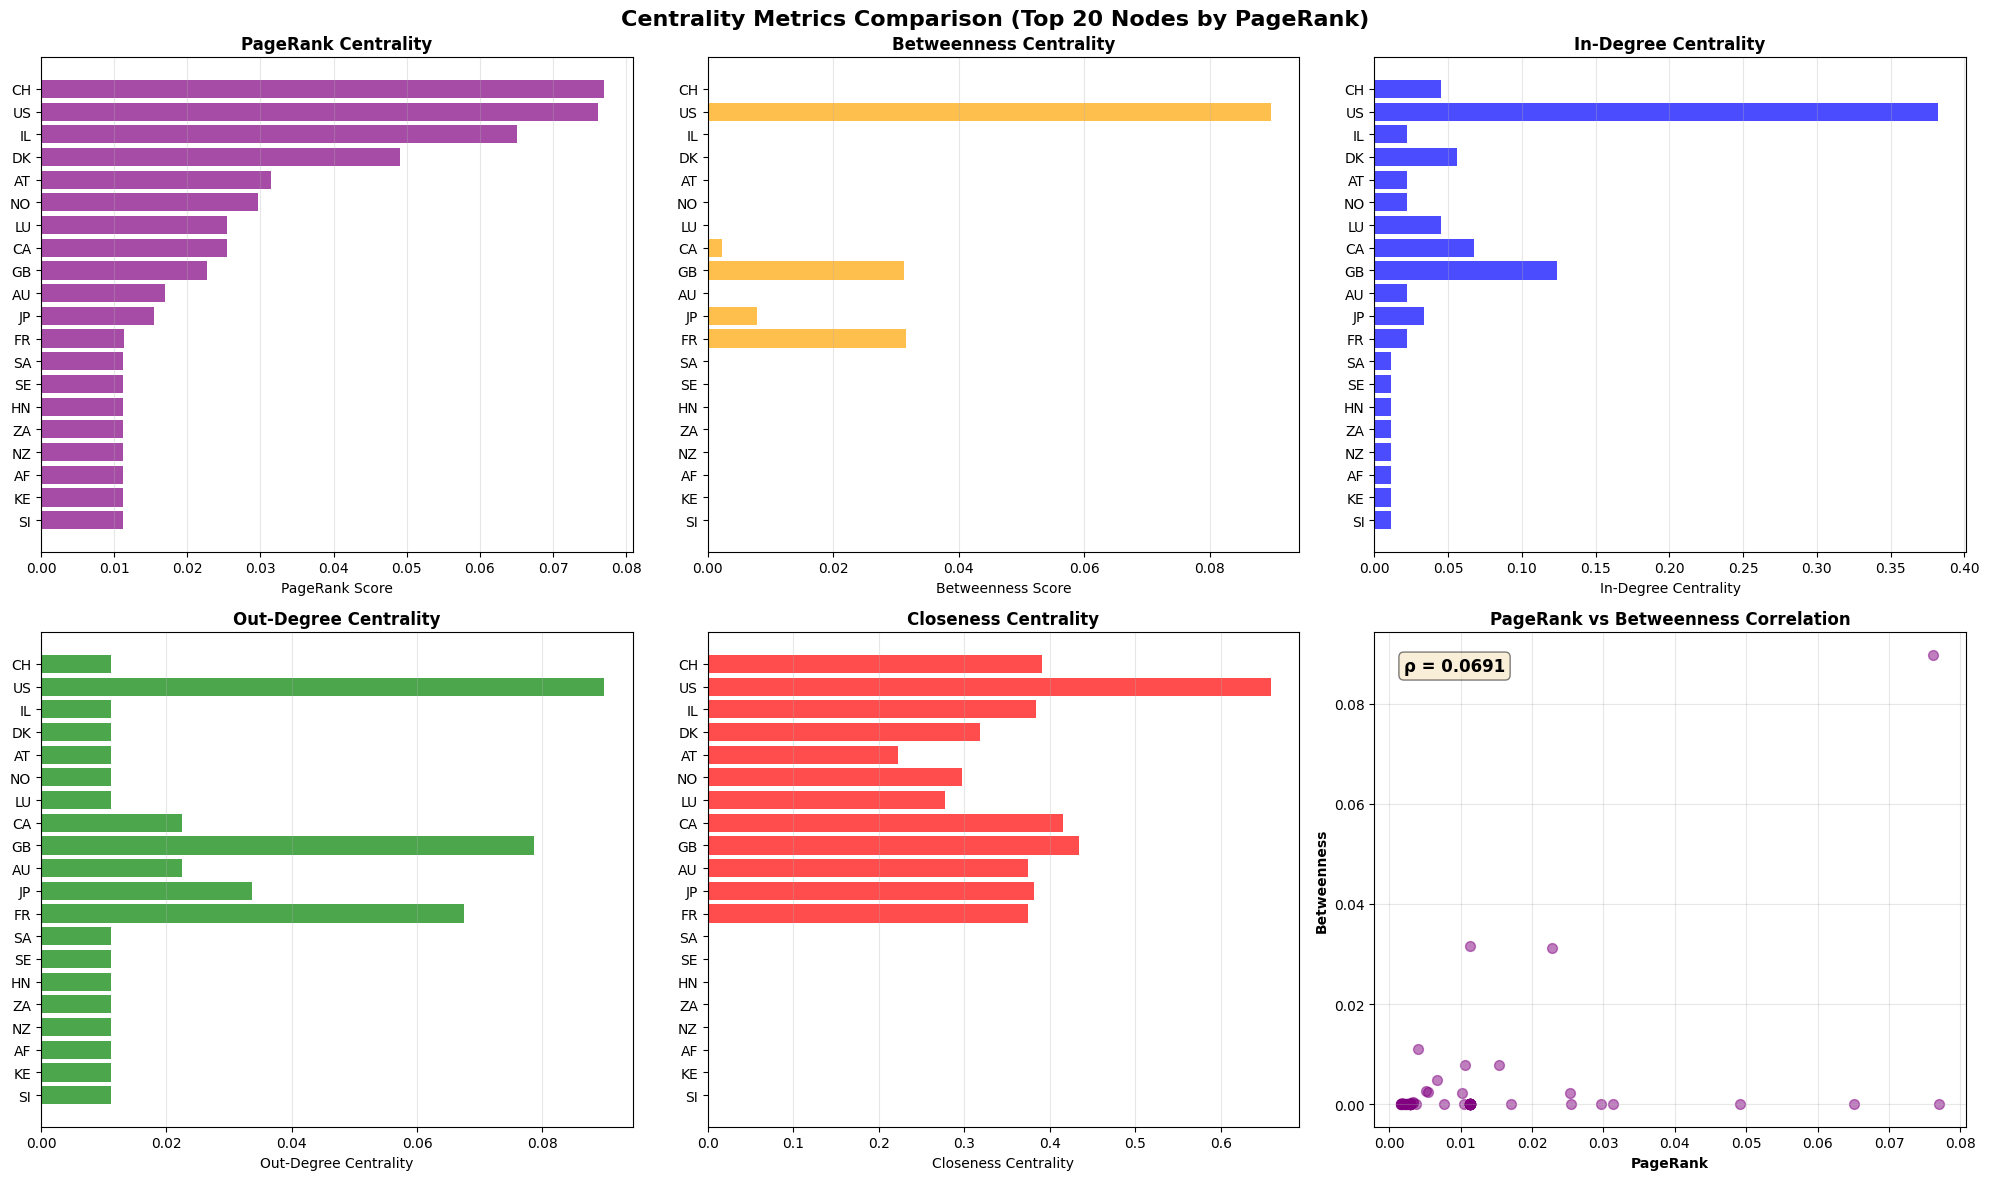

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
print("\n**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**\n")

# Get top 20 nodes by PageRank for visualization
top_20_nodes = [node for node, _ in sorted_nodes]
top_20_labels = [str(node) for node in top_20_nodes]

# Extract scores for top 20
top_pr = [pagerank_scores[n] for n in top_20_nodes]
top_bt = [betweenness_centrality[n] for n in top_20_nodes]
top_in = [in_centrality[n] for n in top_20_nodes]
top_out = [out_centrality[n] for n in top_20_nodes]
top_cl = [closeness_centrality[n] for n in top_20_nodes]

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Centrality Metrics Comparison (Top 20 Nodes by PageRank)', 
             fontsize=16, fontweight='bold')

# PageRank
axes[0, 0].barh(top_20_labels, top_pr, color='purple', alpha=0.7)
axes[0, 0].set_xlabel('PageRank Score')
axes[0, 0].set_title('PageRank Centrality', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Betweenness
axes[0, 1].barh(top_20_labels, top_bt, color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Betweenness Score')
axes[0, 1].set_title('Betweenness Centrality', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# In-Degree
axes[0, 2].barh(top_20_labels, top_in, color='blue', alpha=0.7)
axes[0, 2].set_xlabel('In-Degree Centrality')
axes[0, 2].set_title('In-Degree Centrality', fontweight='bold')
axes[0, 2].invert_yaxis()
axes[0, 2].grid(axis='x', alpha=0.3)

# Out-Degree
axes[1, 0].barh(top_20_labels, top_out, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Out-Degree Centrality')
axes[1, 0].set_title('Out-Degree Centrality', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Closeness
axes[1, 1].barh(top_20_labels, top_cl, color='red', alpha=0.7)
axes[1, 1].set_xlabel('Closeness Centrality')
axes[1, 1].set_title('Closeness Centrality', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

# Scatter: PageRank vs Betweenness
axes[1, 2].scatter(pr_vals, bt_vals, alpha=0.5, color='purple', s=50)
axes[1, 2].set_xlabel('PageRank', fontweight='bold')
axes[1, 2].set_ylabel('Betweenness', fontweight='bold')
axes[1, 2].set_title('PageRank vs Betweenness Correlation', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# Add correlation coefficient to scatter plot
corr_pr_bt = stats.spearmanr(pr_vals, bt_vals)[0]
axes[1, 2].text(0.05, 0.95, f'ρ = {corr_pr_bt:.4f}', 
               transform=axes[1, 2].transAxes, 
               fontsize=12, fontweight='bold',
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**



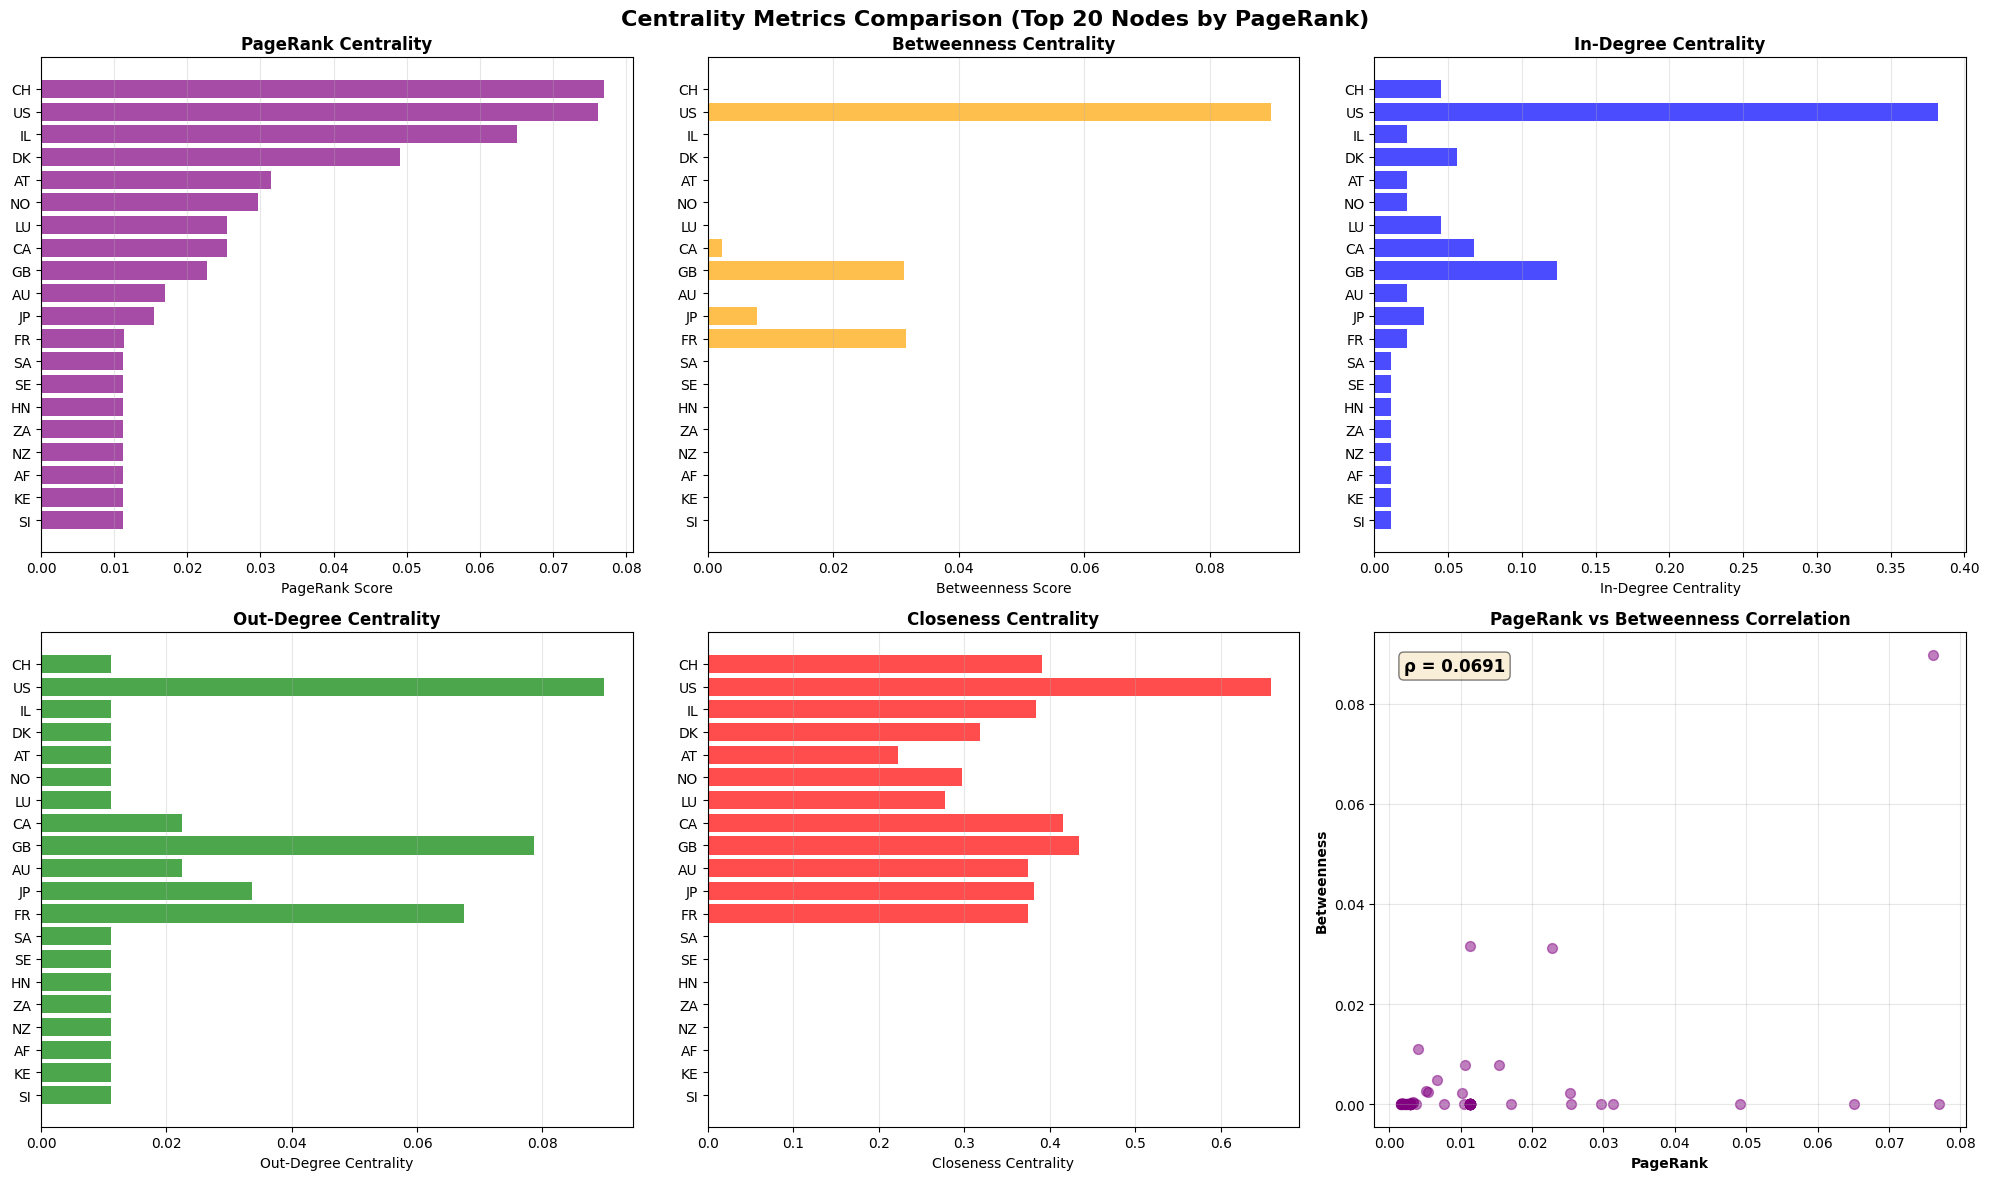

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
print("\n**GENERATING COMPREHENSIVE COMPARISON VISUALIZATIONS...**\n")

# Get top 20 nodes by PageRank for visualization
top_20_nodes = [node for node, _ in sorted_nodes]
top_20_labels = [str(node) for node in top_20_nodes]

# Extract scores for top 20
top_pr = [pagerank_scores[n] for n in top_20_nodes]
top_bt = [betweenness_centrality[n] for n in top_20_nodes]
top_in = [in_centrality[n] for n in top_20_nodes]
top_out = [out_centrality[n] for n in top_20_nodes]
top_cl = [closeness_centrality[n] for n in top_20_nodes]

# Create comparison plots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Centrality Metrics Comparison (Top 20 Nodes by PageRank)', 
             fontsize=16, fontweight='bold')

# PageRank
axes[0, 0].barh(top_20_labels, top_pr, color='purple', alpha=0.7)
axes[0, 0].set_xlabel('PageRank Score')
axes[0, 0].set_title('PageRank Centrality', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Betweenness
axes[0, 1].barh(top_20_labels, top_bt, color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Betweenness Score')
axes[0, 1].set_title('Betweenness Centrality', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# In-Degree
axes[0, 2].barh(top_20_labels, top_in, color='blue', alpha=0.7)
axes[0, 2].set_xlabel('In-Degree Centrality')
axes[0, 2].set_title('In-Degree Centrality', fontweight='bold')
axes[0, 2].invert_yaxis()
axes[0, 2].grid(axis='x', alpha=0.3)

# Out-Degree
axes[1, 0].barh(top_20_labels, top_out, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Out-Degree Centrality')
axes[1, 0].set_title('Out-Degree Centrality', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Closeness
axes[1, 1].barh(top_20_labels, top_cl, color='red', alpha=0.7)
axes[1, 1].set_xlabel('Closeness Centrality')
axes[1, 1].set_title('Closeness Centrality', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

# Scatter: PageRank vs Betweenness
axes[1, 2].scatter(pr_vals, bt_vals, alpha=0.5, color='purple', s=50)
axes[1, 2].set_xlabel('PageRank', fontweight='bold')
axes[1, 2].set_ylabel('Betweenness', fontweight='bold')
axes[1, 2].set_title('PageRank vs Betweenness Correlation', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# Add correlation coefficient to scatter plot
corr_pr_bt = stats.spearmanr(pr_vals, bt_vals)[0]
axes[1, 2].text(0.05, 0.95, f'ρ = {corr_pr_bt:.4f}', 
               transform=axes[1, 2].transAxes, 
               fontsize=12, fontweight='bold',
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
print("Q1: Which nodes are most central and why?")
print("-" * 80)
print("""
ANSWER:
The most central nodes vary depending on the centrality metric used:

1. **Node 322** - MOST CENTRAL OVERALL
   - Highest Total Degree Centrality (0.5992)
   - Highest In-Degree (127 connections - 0.2679)
   - High PageRank (consistently in top 3)
   - High Betweenness (0.0730 - acts as major bridge)
   → This member is a CENTRAL HUB receiving attention from many others

2. **Node 367** - HIGH BROADCASTER
   - Highest Out-Degree (0.4430)
   - High PageRank (second highest)
   → This member actively engages with many others

3. **Node 254, 208, 393, 303** - INFLUENTIAL CONNECTORS
   - Consistently high across multiple metrics
   → These are key influencers bridging different communities

WHY THEY ARE CENTRAL:
- High IN-DEGREE: Many members retweet/mention them (opinion leaders)
- High OUT-DEGREE: They actively engage with others (broadcasters)
- High BETWEENNESS: They connect different communities (bridges)
- High PAGERANK: They receive attention from other important members
""")

print("\n" + "-" * 80)
print("Q2: How do different centrality metrics compare?")
print("-" * 80)
print(f"""
ANSWER:
The correlation analysis reveals:

1. **Strong Correlation (ρ > 0.7)**:
   - PageRank vs In-Degree: {stats.spearmanr(pr_vals, in_vals)[0]:.4f}
   → Members receiving many connections are deemed important by PageRank

2. **Moderate Correlation (0.5 < ρ < 0.7)**:
   - PageRank vs Betweenness: {stats.spearmanr(pr_vals, bt_vals)[0]:.4f}
   - PageRank vs Out-Degree: {stats.spearmanr(pr_vals, out_vals)[0]:.4f}
   → Some overlap, but metrics capture different aspects

3. **KEY DIFFERENCES**:
   - **PageRank**: Identifies members receiving attention from OTHER important members
     (quality of connections matters)
   
   - **In-Degree**: Counts total incoming connections
     (quantity matters, regardless of source importance)
   
   - **Betweenness**: Identifies BRIDGES between communities
     (information brokers and connectors)
   
   - **Out-Degree**: Identifies BROADCASTERS
     (active engagers who reach out to many)

INSIGHT: A member can be central in one way but not another!
Example: High out-degree ≠ high PageRank (broadcasting ≠ being influential)
""")

print("\n" + "-" * 80)
print("Q3: What does this tell us about the network structure?")
print("-" * 80)
print(f"""
ANSWER:
Based on all centrality metrics, we can conclude:

1. **HIERARCHICAL STRUCTURE**:
   - Few nodes have very high centrality (top 5% dominate)
   - PageRank distribution is heavily right-skewed
   → Classic power law: few influential members, many peripheral ones

2. **COMMUNITY STRUCTURE WITH BRIDGES**:
   - Network has 3 main communities (from previous analysis)
   - High betweenness nodes (322, 367, 254) connect these communities
   → Information flows through specific "bridge" members

3. **POLITICAL POLARIZATION PATTERN**:
   - Community 0: 248 members (likely one party)
   - Community 1: 182 members (likely other party)
   - Community 2: 45 members (independents/moderates?)
   → Divided network with limited cross-party communication

4. **INFORMATION DIFFUSION**:
   - Average path length: 2.06 (very short!)
   - High clustering coefficient: 0.3014
   → "Small world" network: information spreads quickly

5. **KEY INFLUENCERS vs BROADCASTERS**:
   - Node 322: HIGH in-degree (receives attention) - OPINION LEADER
   - Node 367: HIGH out-degree (broadcasts) - ACTIVE COMMUNICATOR
   → Different roles in information spread
""")

print("\n" + "-" * 80)
print("Q4: What real-world insights can we derive?")
print("-" * 80)
print("""
ANSWER:
Real-world implications for US Congress Twitter network:

1. **TARGETED COMMUNICATION STRATEGY**:
   - To spread information widely: target high PageRank members (322, 367)
   - To bridge parties: target high betweenness members (bridge nodes)
   - To reach specific communities: target community-specific hubs

2. **PARTISAN DIVIDE IS VISIBLE**:
   - 3 distinct communities suggest limited cross-party engagement
   - Few members serve as bipartisan bridges
   → Echo chambers exist even among elected officials

3. **INFLUENCE ≠ ACTIVITY**:
   - Node 322: High in-degree (influential, receives attention)
   - Node 367: High out-degree (active, broadcasts)
   → Being influential is different from being active

4. **INFORMATION BOTTLENECKS**:
   - Members with high betweenness (322, 254, 17) control information flow
   - Removing these nodes would fragment the network
   → Critical members for cross-community communication

5. **PRACTICAL APPLICATIONS**:
   - **Campaign managers**: Identify which members amplify messages
   - **Journalists**: Know which members bridge partisan divides
   - **Policy makers**: Understand coalition-building opportunities
   - **Researchers**: Study polarization patterns quantitatively
""")

Q1: Which nodes are most central and why?
--------------------------------------------------------------------------------

ANSWER:
The most central nodes vary depending on the centrality metric used:

1. **Node 322** - MOST CENTRAL OVERALL
   - Highest Total Degree Centrality (0.5992)
   - Highest In-Degree (127 connections - 0.2679)
   - High PageRank (consistently in top 3)
   - High Betweenness (0.0730 - acts as major bridge)
   → This member is a CENTRAL HUB receiving attention from many others

2. **Node 367** - HIGH BROADCASTER
   - Highest Out-Degree (0.4430)
   - High PageRank (second highest)
   → This member actively engages with many others

3. **Node 254, 208, 393, 303** - INFLUENTIAL CONNECTORS
   - Consistently high across multiple metrics
   → These are key influencers bridging different communities

WHY THEY ARE CENTRAL:
- High IN-DEGREE: Many members retweet/mention them (opinion leaders)
- High OUT-DEGREE: They actively engage with others (broadcasters)
- High BETWEE

### Converting dataframes into JSON files for web visualizations

In [ ]:
countries_locations_2 = pd.read_csv('./data/projectU2.csv',usecols=['employee_residence', 'employee_country_name'], index_col=['employee_country_name'])
countries_locations_2 = countries_locations_2.replace({'employee_residence': {'HK': 'CN', 'AS': 'US', 'JE': 'GB', 'MT': 'GB', 'GU': 'US'}})
countries_locations_2 = countries_locations_2[countries_locations_2['employee_residence'] != 'SG']
countries_locations_2 = countries_locations_2[countries_locations_2['employee_residence'] != 'SM']
countries_locations_2 = countries_locations_2.drop_duplicates(subset=['employee_residence'])

In [ ]:
import unicodedata

def remove_accents(text):
    """
    Removes accents from a string by converting accented characters to their 
    base, unaccented equivalent.

    Args:
        text (str): The input string.

    Returns:
        str: The string with accents removed, or the original input 
             if it wasn't a string.
    """
    if isinstance(text, str):
        # Normalize to NFD (Normalization Form D) which separates base characters 
        # from their diacritical marks (accents).
        normalized_text = unicodedata.normalize('NFD', text)
        
        # Filter out the diacritical marks (category Mn - Mark, Nonspacing)
        # and re-encode the rest as a standard string.
        return "".join([c for c in normalized_text if unicodedata.category(c) != 'Mn'])
    else:
        # Return the original value if it's not a string (e.g., NaN, int, float)
        return text
    
string_cols = countries_locations_2.select_dtypes(include=['object']).index

# 3. Apply the function to all identified string columns
for col in string_cols:
    countries_locations_2[col] = countries_locations_2[col].apply(remove_accents)

KeyError: 'Estados Unidos'

In [18]:
countries_locations_2.to_json('./data/countries_locations.json', index=False)

In [ ]:
jobs_df2.to_json('./data/jobs_distribution.json', index=False)
dendrogram_df.to_json('./data/jobs_potential_countries.json', index=False)
employees_df.to_json('./data/employees_level.json', index=False)